# PCA-derived OP maps — error analysis & plotting

Loads the outputs of `compute_errors.py` (long-form error DataFrame + PCA scores)
and the permuted maps from `generate_permutations.py`, then visualises:

1. Real vs permutation-null error per PC pair (per array / condition)
2. Derived OP map on the 8×8 grid (odd/even layout) for a chosen pair
3. Pooled summaries across arrays / monkeys / conditions

Method recap: tMUA → 50 ms FR bins → full Pearson CC (oriented channels only)
→ PCA (≤7 PCs) → per-pair geometric OP (optimal rotation/flip fit on oriented
channels) → L1 / L2 (RMSE) circular error vs real OP. Permutations shuffle the
oriented OP labels and refit in the same PC cloud.

## Imports & parameters

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from functions_maps import (
    polar_angles_from_centroid, best_rotation_to_op, apply_geometric_map,
)

with open("params_maps.yml") as f:
    P = yaml.safe_load(f)

DF_FOLDER  = P["df_folder"]
LAYOUTS    = P["layout"]
MONKEYS    = P["monkeys"]
V1_ARRAYS  = P["v1_arrays"]
DATES      = P["dates"]
N_CH       = P["method"]["n_channels"]
MAX_DIM    = P["method"]["max_dim"]
COLORS_M   = P["colors_monkeys"]

plt.rcParams["figure.facecolor"] = "white"

## Load results

In [2]:
df = pd.read_pickle(os.path.join(DF_FOLDER, "errors_long.pkl"))
with open(os.path.join(DF_FOLDER, "pca_scores.pkl"), "rb") as f:
    pca_store = pickle.load(f)
with open(os.path.join(DF_FOLDER, "permutations", "permuted_maps_all.pkl"), "rb") as f:
    perm_maps = pickle.load(f)

print("error rows:", len(df))
print("conditions:", df["condition"].unique())
print("pc pairs   :", df["pc_pair"].nunique())
print("pca entries:", len(pca_store))
df.head()

error rows: 8876868
conditions: ['all' 'EC' 'EO']
pc pairs   : 21
pca entries: 216


,monkey,date,array,condition,pc_pair,pc_x,pc_y,source,perm_idx,norm,error
0,F,20240122_B1,1,all,PC1 vs PC2,1,2,real,-1,L1,34.065623
1,F,20240122_B1,1,all,PC1 vs PC2,1,2,real,-1,L2,44.376595
2,F,20240122_B1,1,all,PC1 vs PC3,1,3,real,-1,L1,34.869675
3,F,20240122_B1,1,all,PC1 vs PC3,1,3,real,-1,L2,45.572914
4,F,20240122_B1,1,all,PC1 vs PC4,1,4,real,-1,L1,33.899908


## Helper: real-vs-null error per PC pair

For one (monkey, date, array, condition), plot the real error per PC pair as
points over the permutation-null distribution (box/violin). Use `norm="L1"`
or `"L2"`.

In [3]:
def plot_pair_errors(monkey, date, array, condition, norm="L1", ax=None):
    sub = df[(df.monkey==monkey) & (df.date==str(date)) &
             (df.array==int(array)) & (df.condition==condition) &
             (df.norm==norm)]
    if sub.empty:
        print("no data for", monkey, date, array, condition, norm); return
    # consistent pair ordering by (pc_x, pc_y)
    pairs = (sub[["pc_pair","pc_x","pc_y"]].drop_duplicates()
             .sort_values(["pc_x","pc_y"])["pc_pair"].tolist())
    null_data = [sub[(sub.pc_pair==p) & (sub.source=="perm")]["error"].values
                 for p in pairs]
    real_vals = [sub[(sub.pc_pair==p) & (sub.source=="real")]["error"].values
                 for p in pairs]

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(6, len(pairs)*0.6), 4))
    bp = ax.boxplot(null_data, positions=range(len(pairs)), widths=0.6,
                    showfliers=False, patch_artist=True)
    for box in bp["boxes"]:
        box.set(facecolor="#dddddd", edgecolor="#999999")
    for med in bp["medians"]:
        med.set(color="#999999")
    for i, rv in enumerate(real_vals):
        if len(rv):
            ax.scatter(i, rv[0], color=COLORS_M.get(monkey, "red"),
                       zorder=5, s=45, edgecolor="k", linewidth=0.6)
    ax.set_xticks(range(len(pairs)))
    ax.set_xticklabels(pairs, rotation=90, fontsize=7)
    ax.set_ylabel(f"{norm} circular error (deg)")
    ax.set_title(f"{monkey} | {date} | array {array} | {condition}  "
                 f"(point=real, box=null)", fontsize=9)
    ax.axhline(45, color="#d6604d", ls=":", lw=0.9)
    return ax

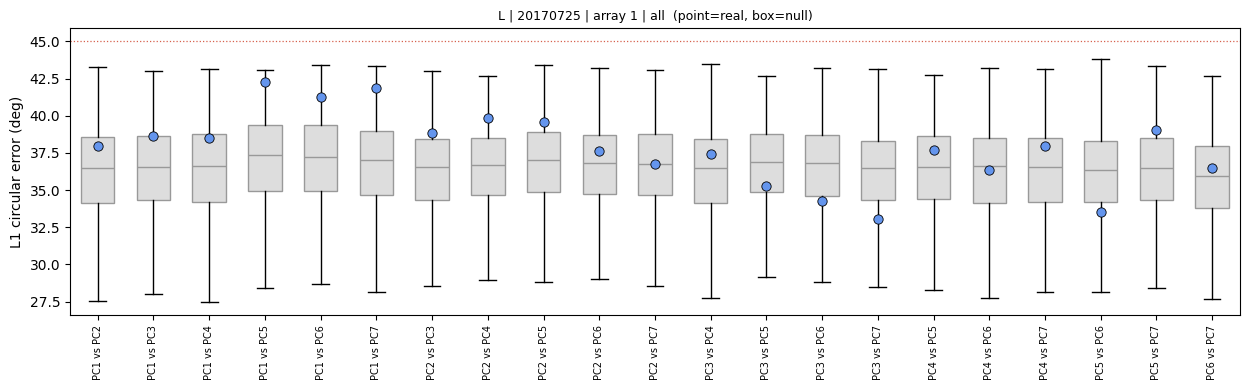

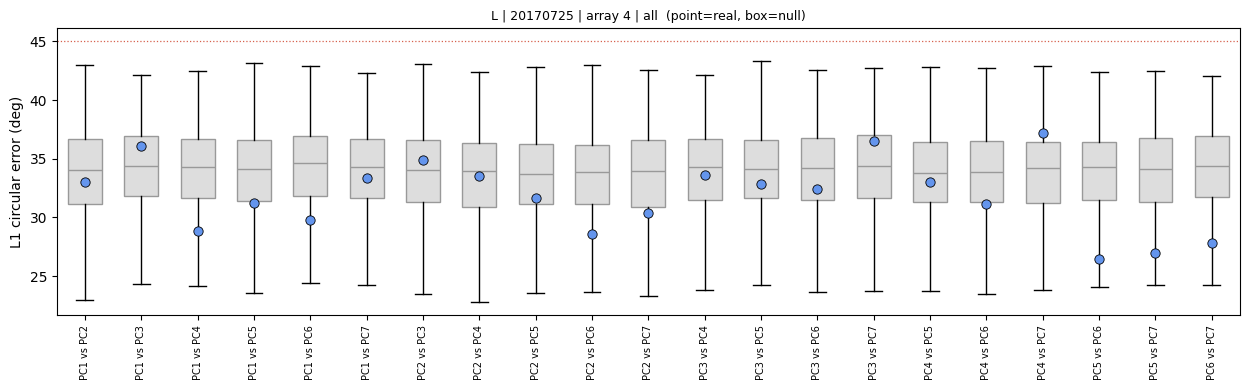

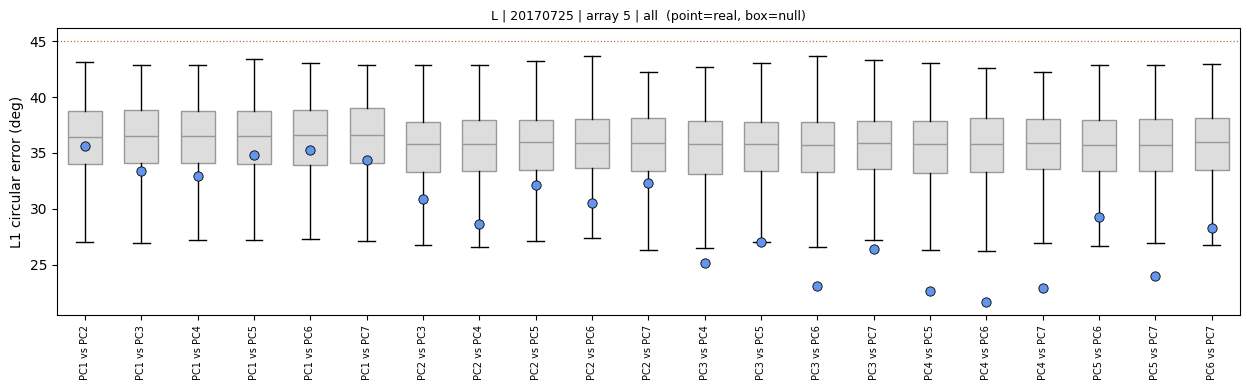

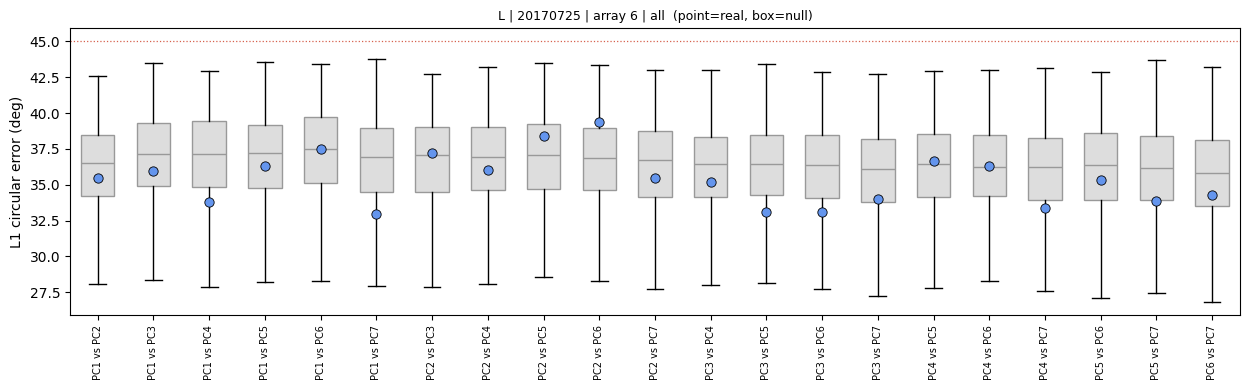

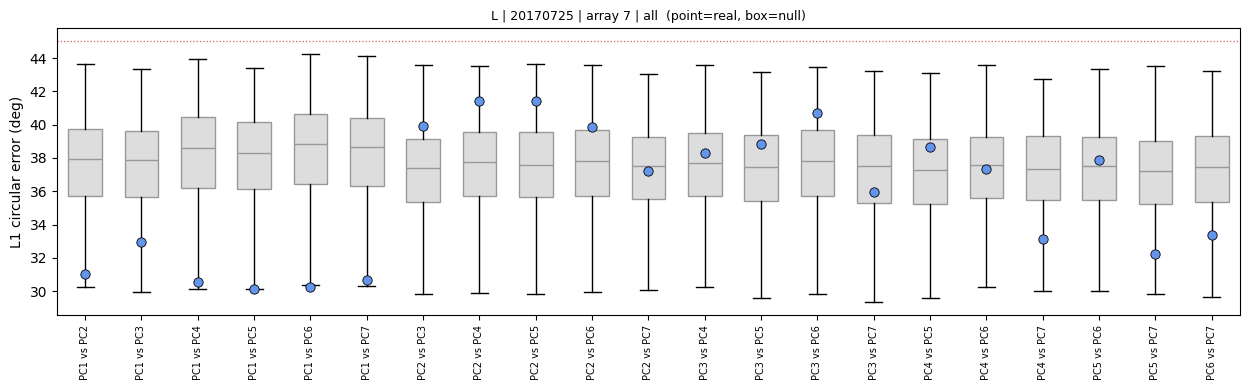

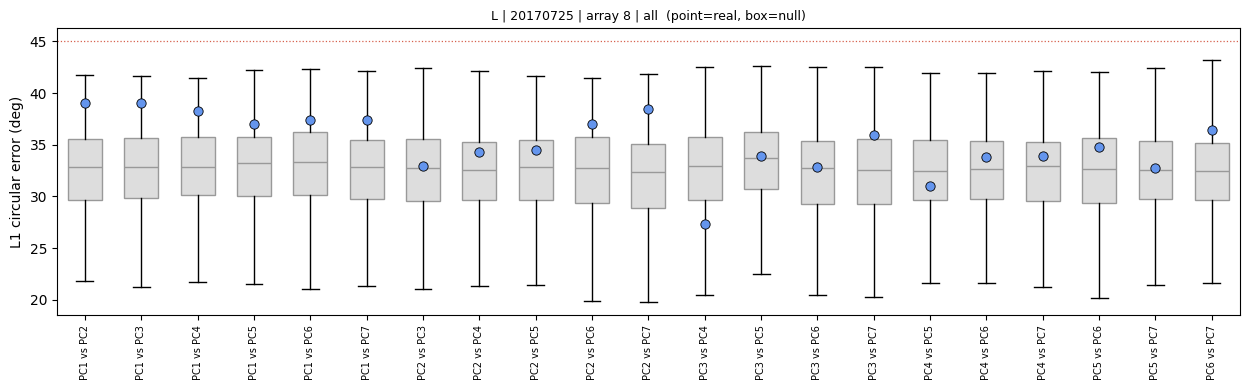

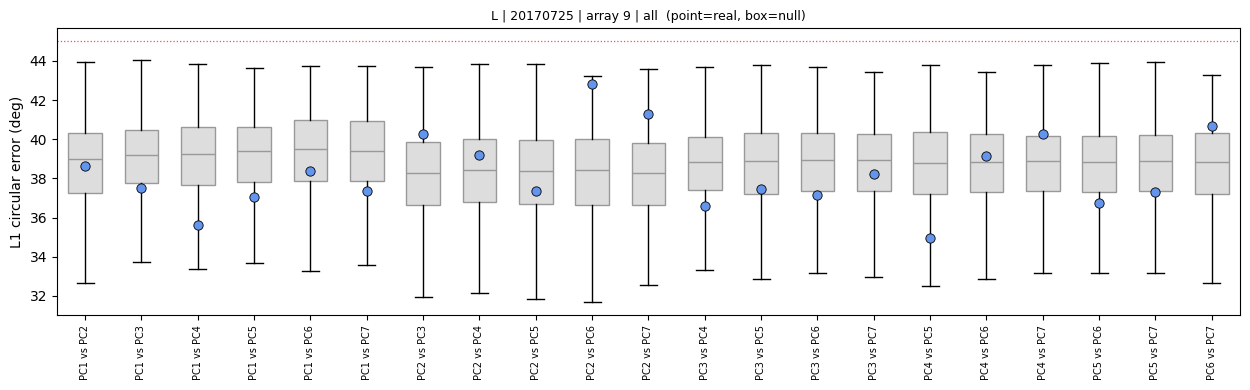

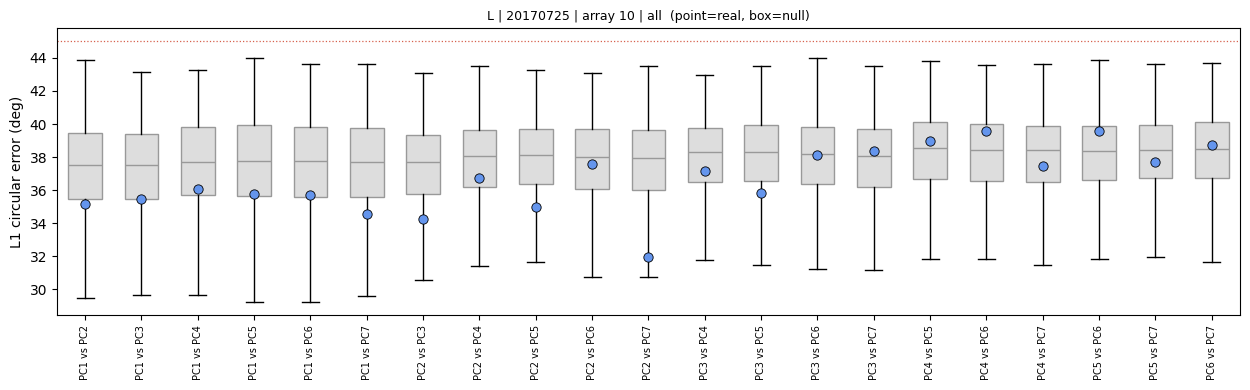

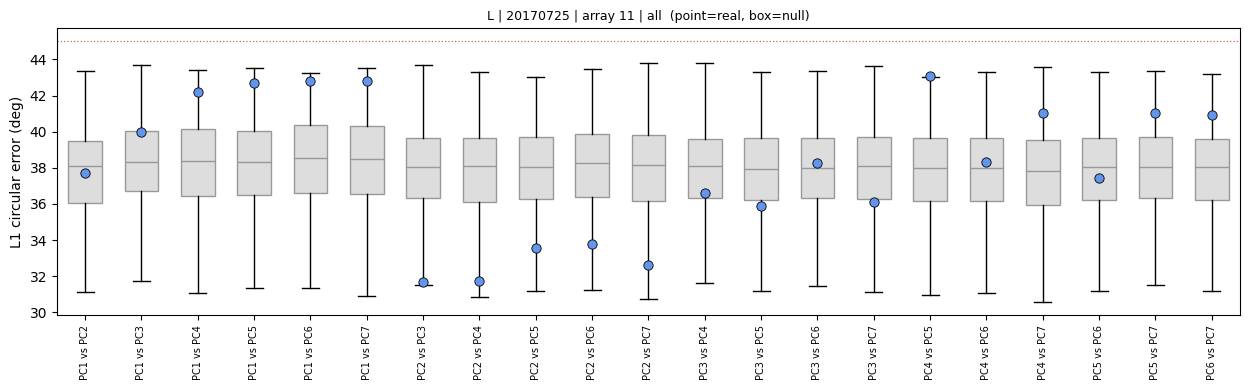

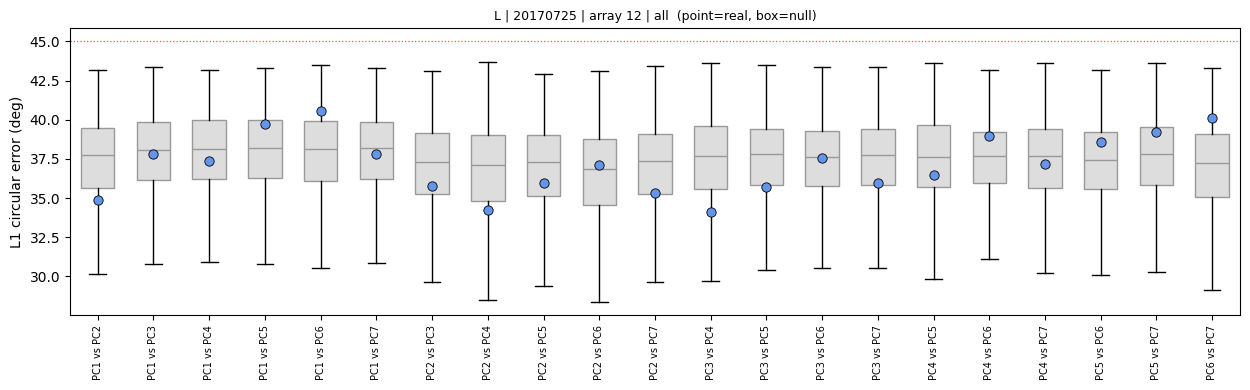

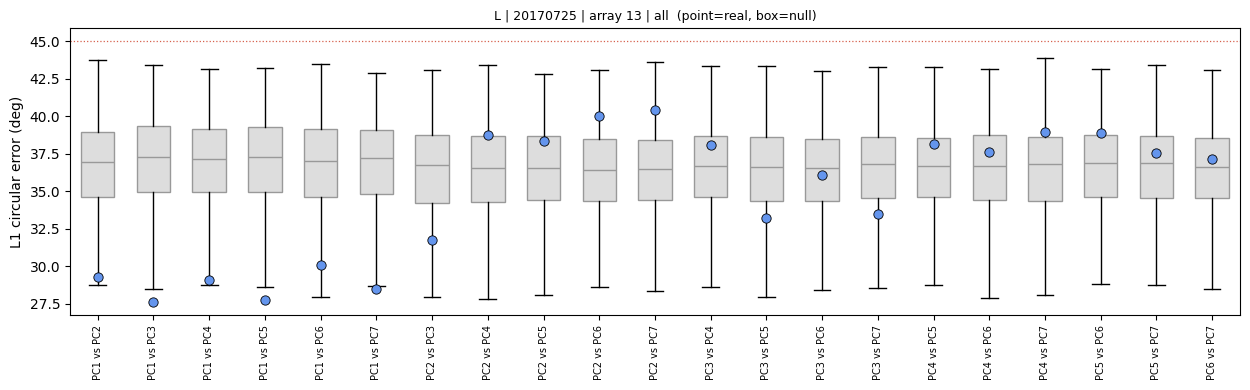

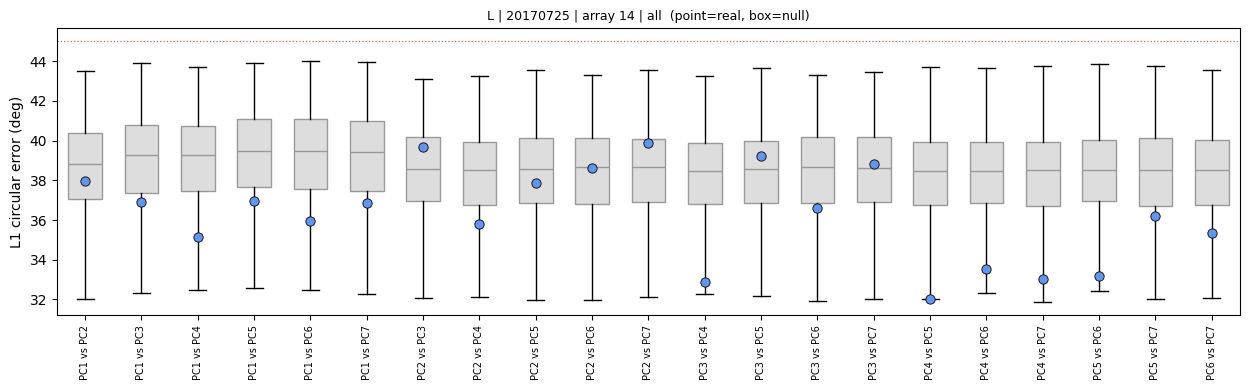

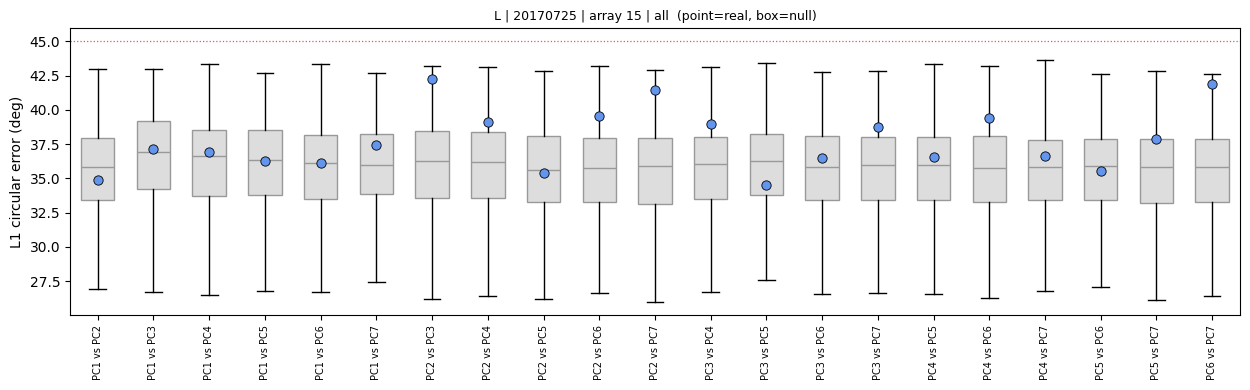

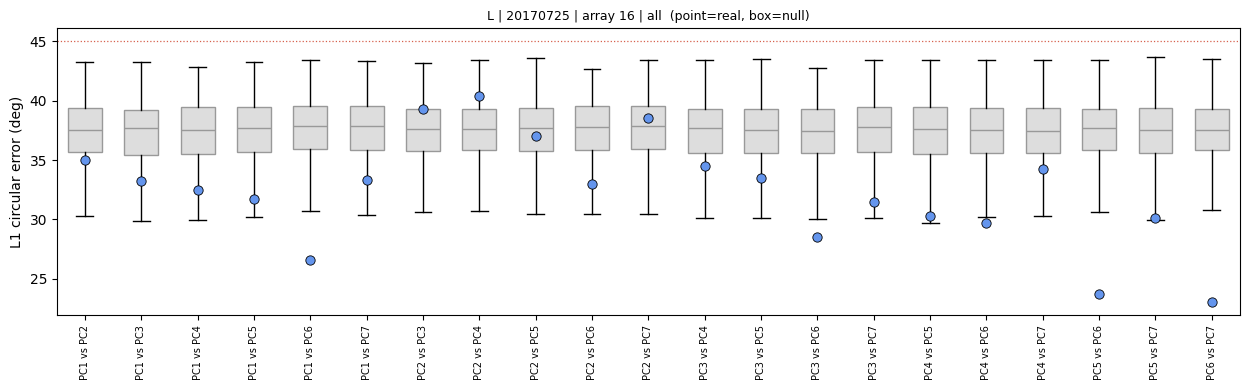

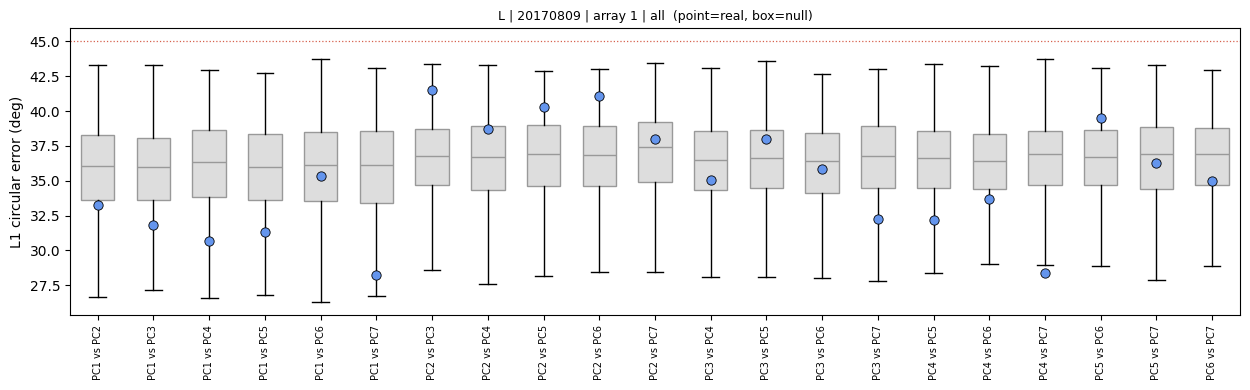

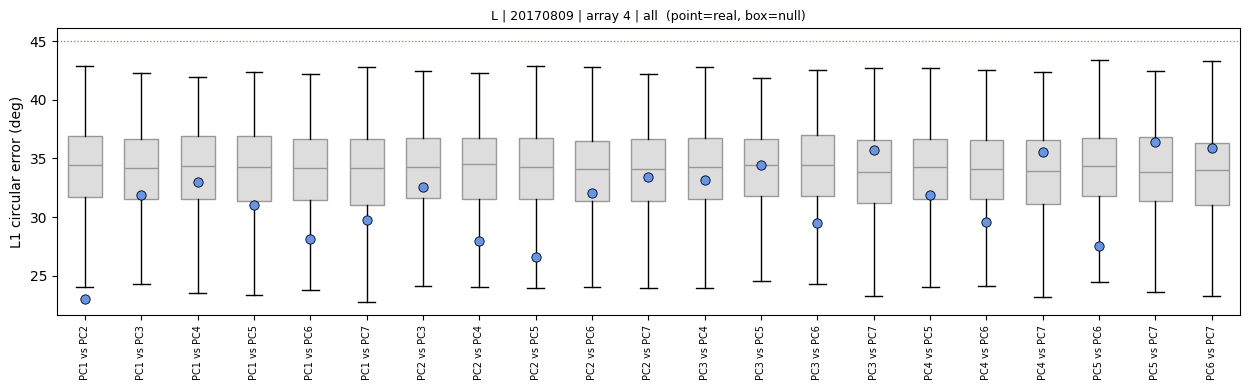

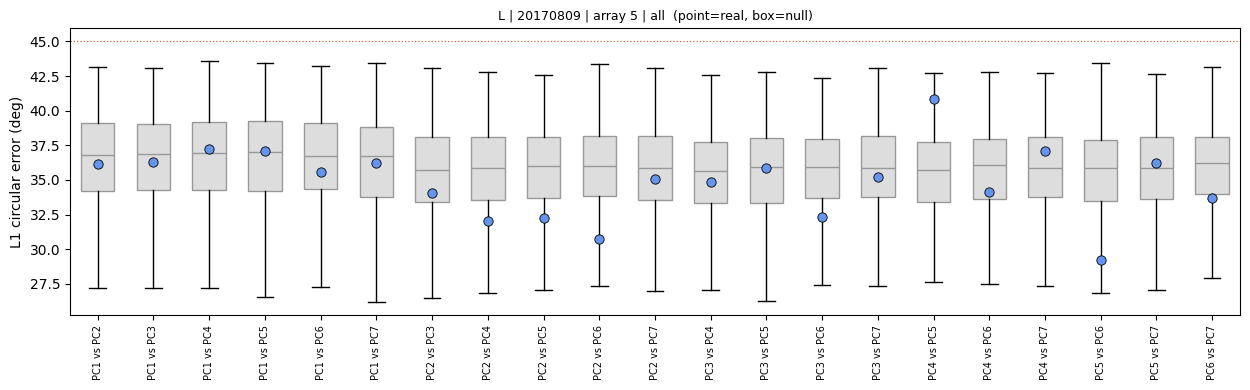

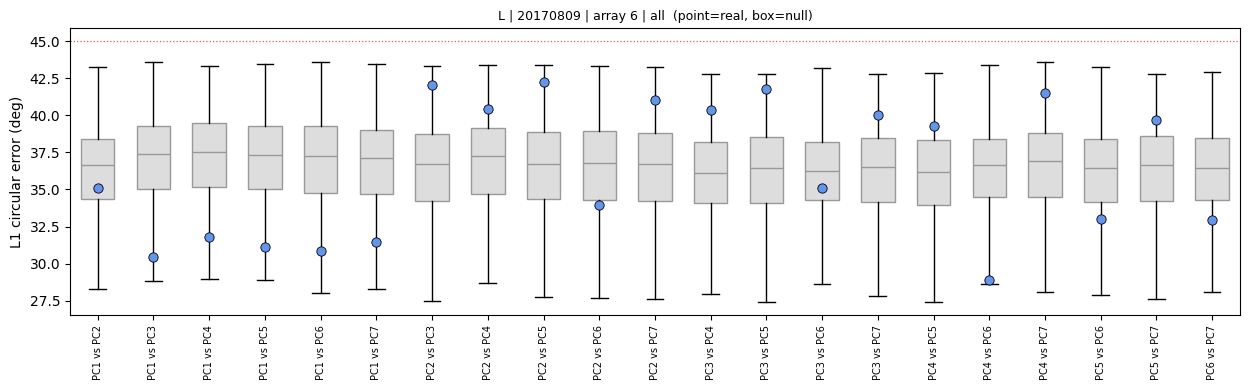

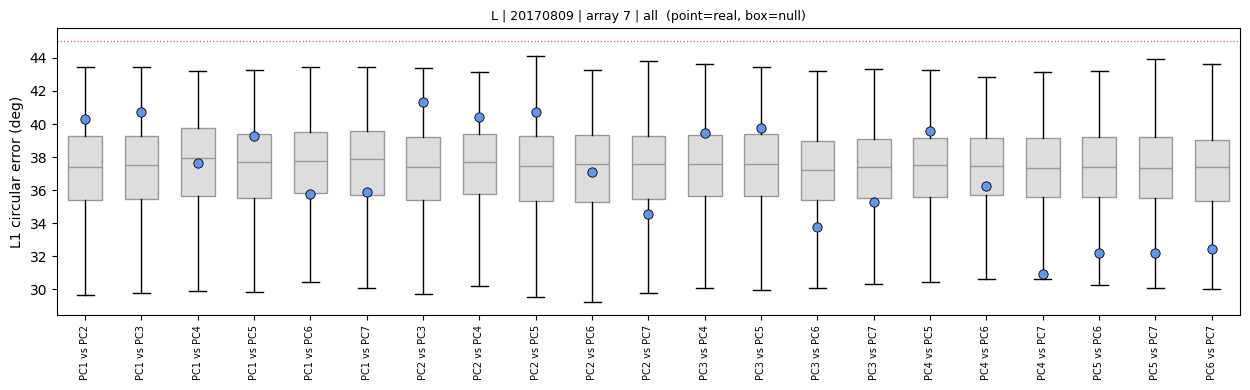

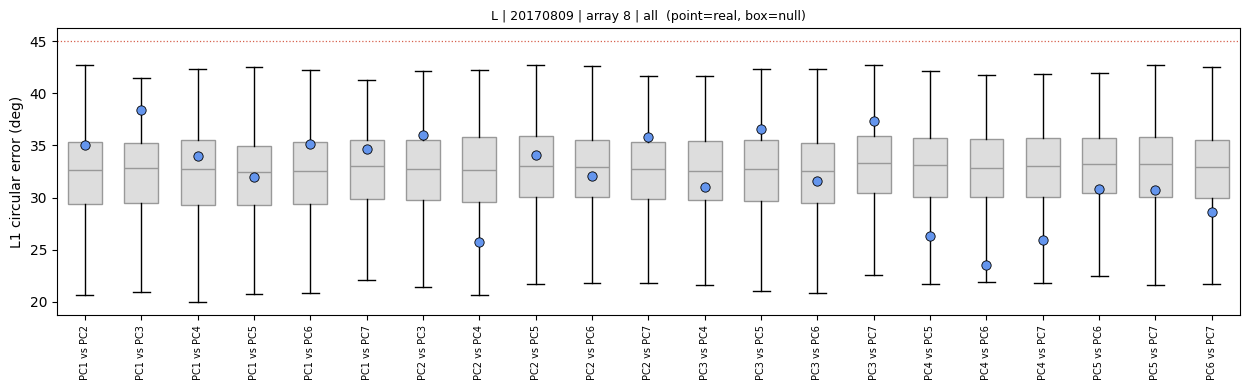

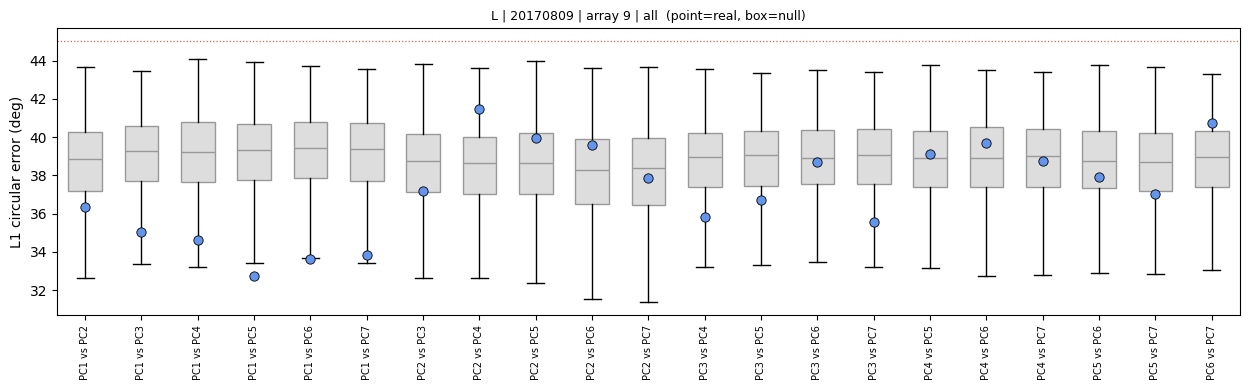

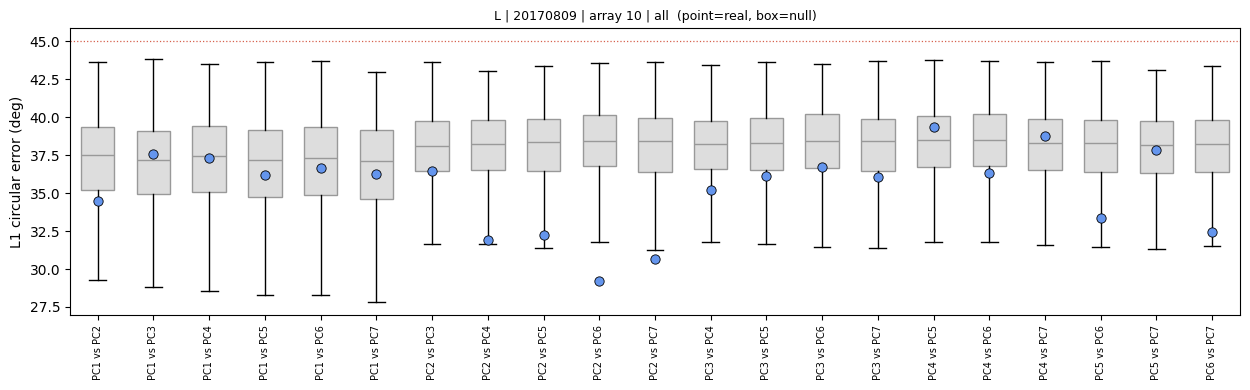

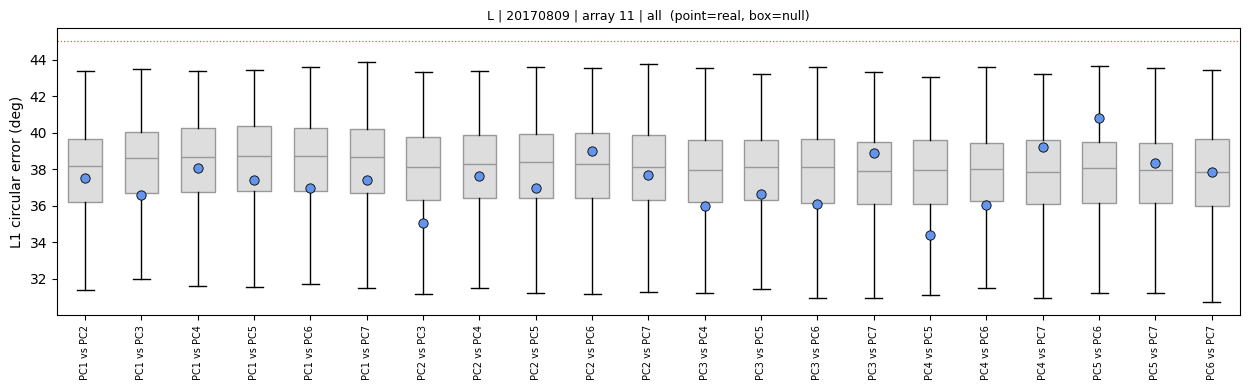

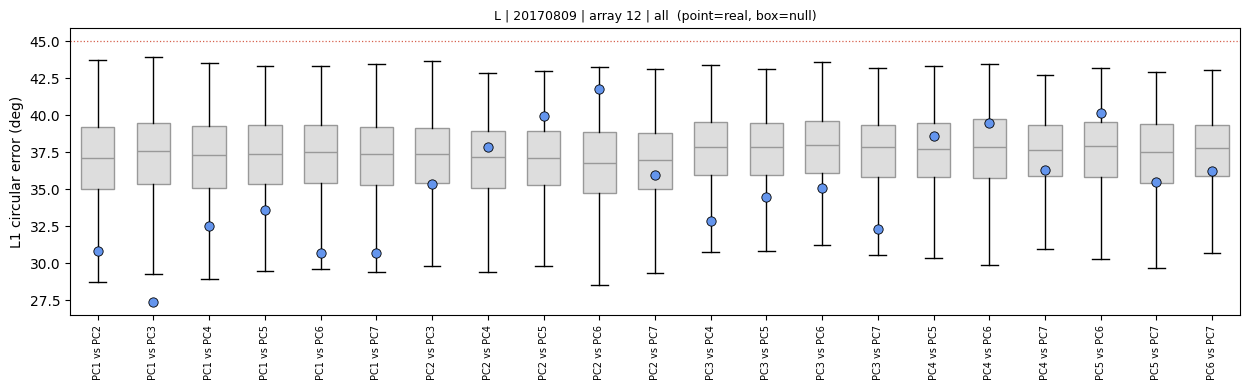

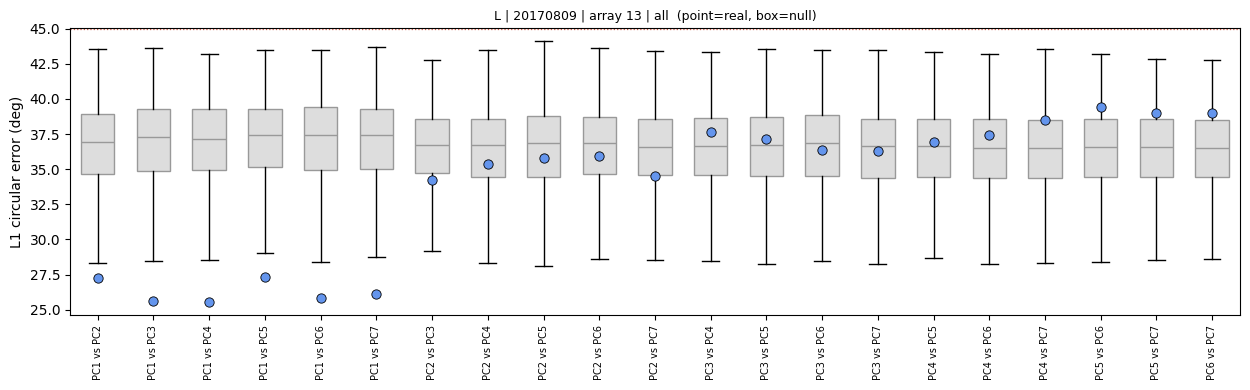

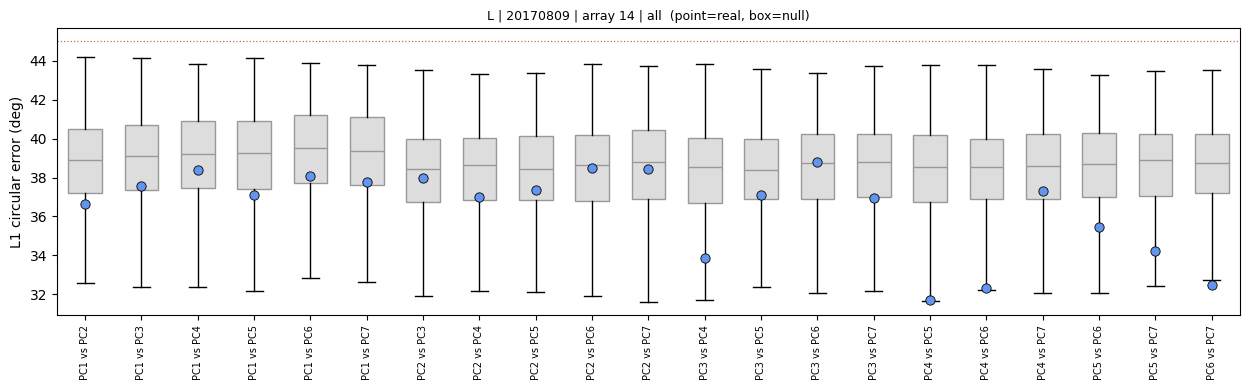

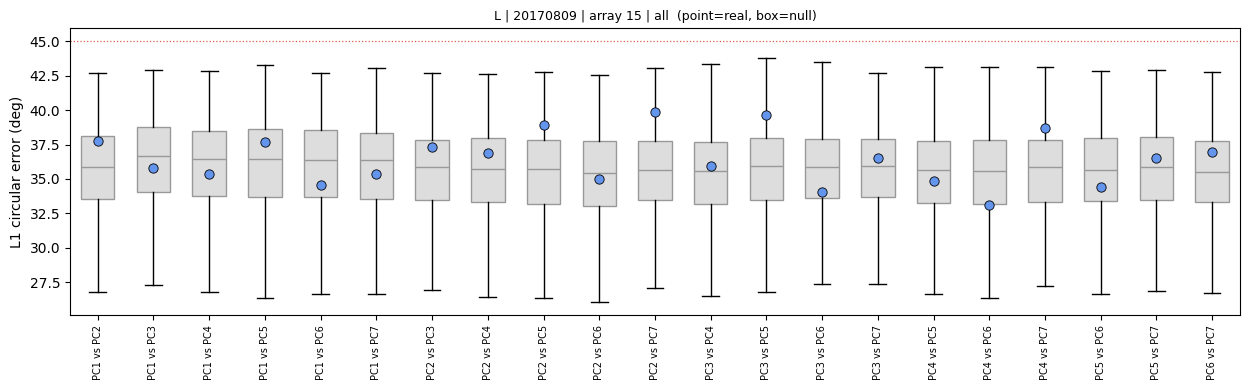

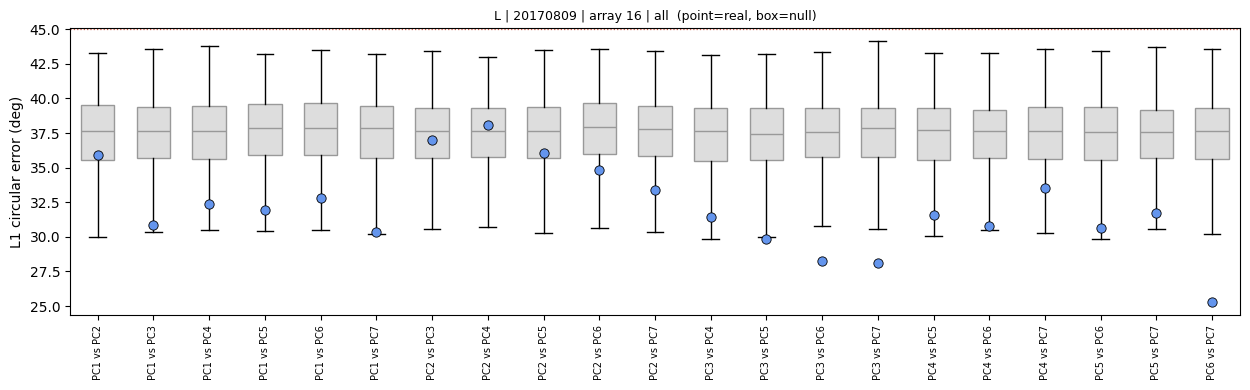

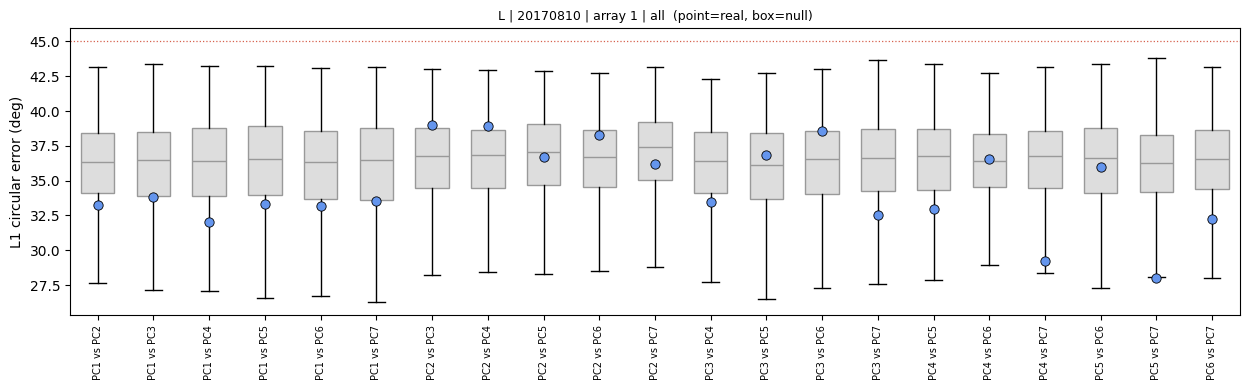

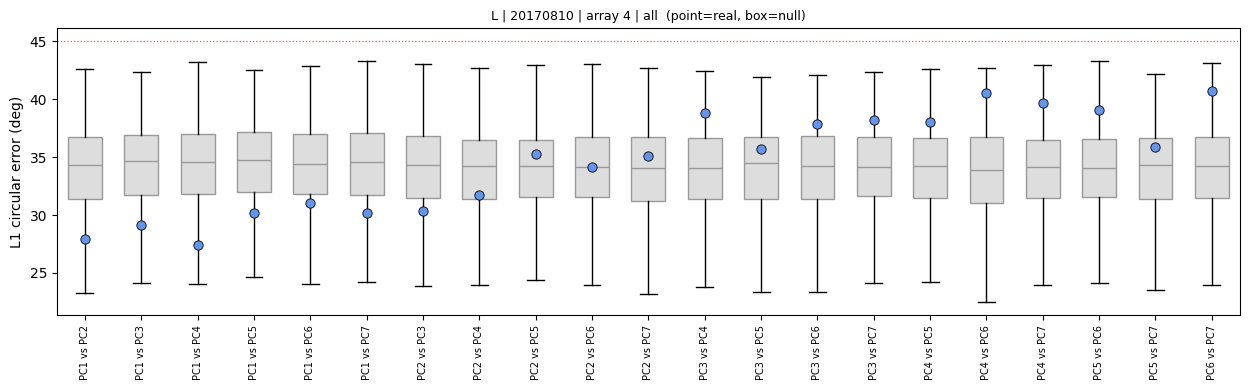

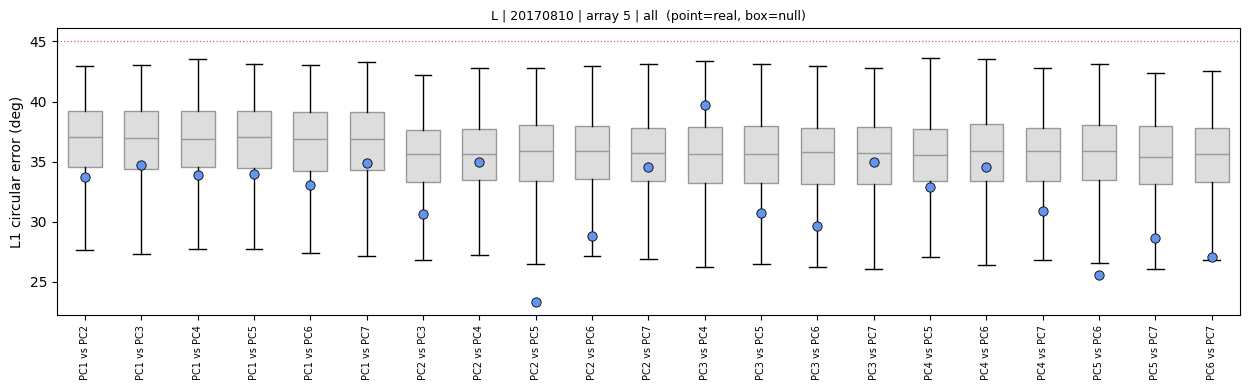

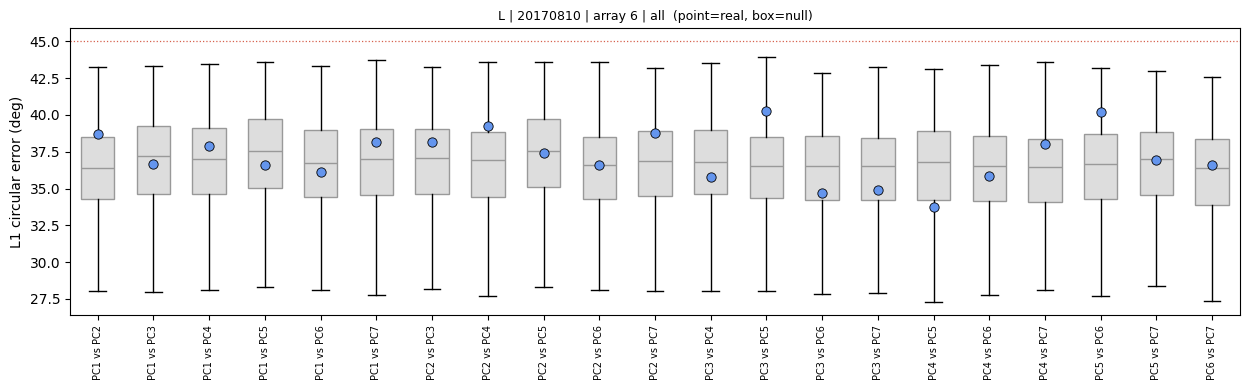

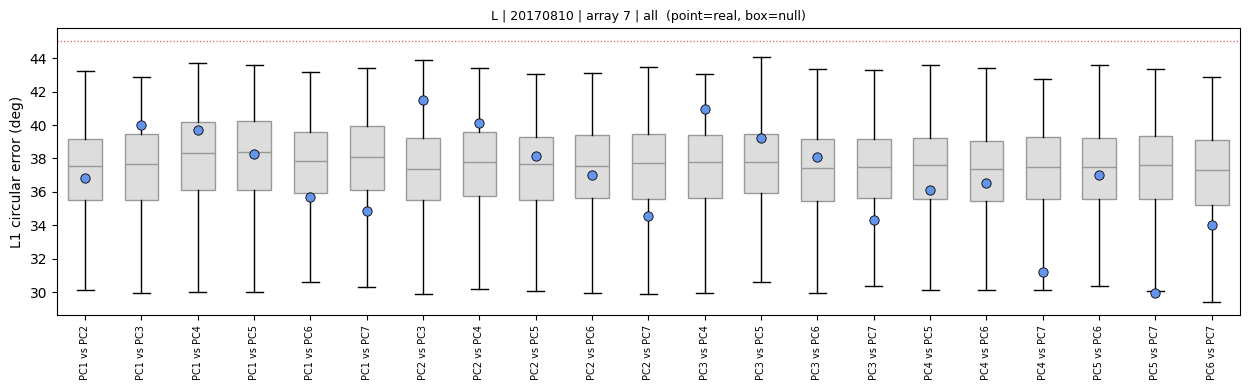

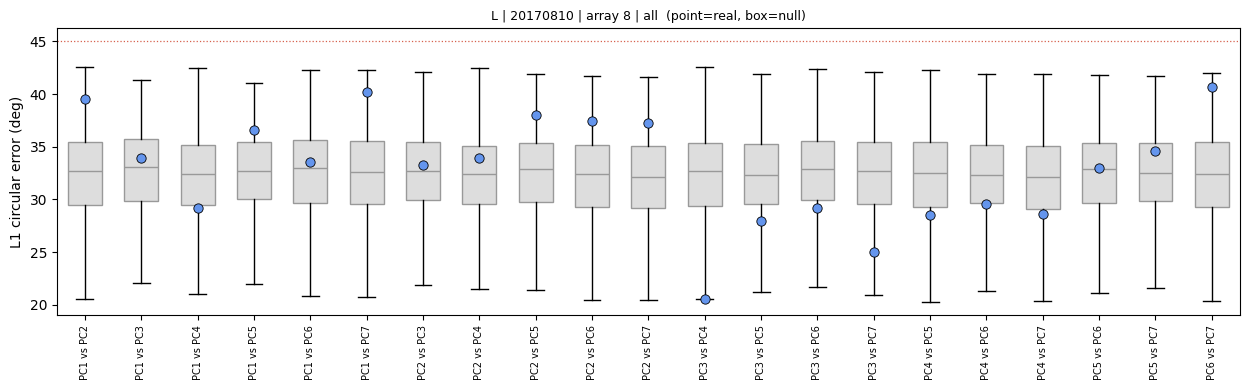

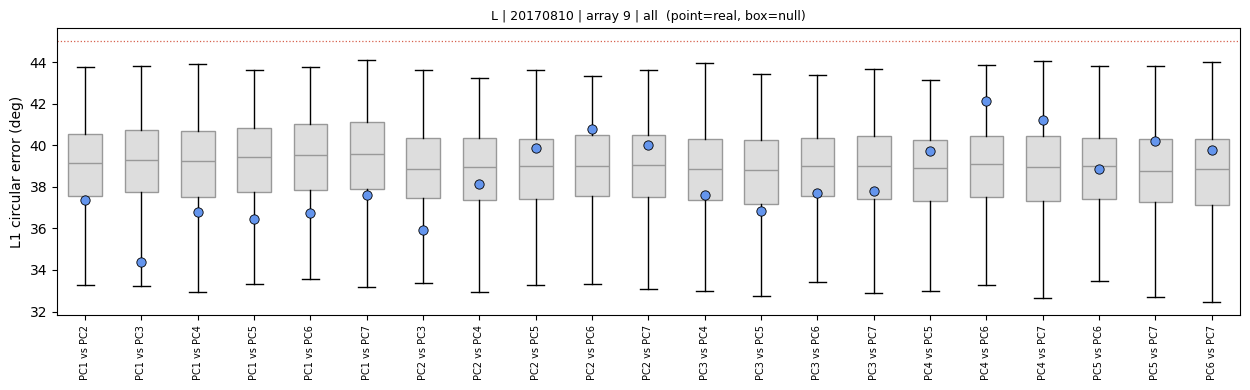

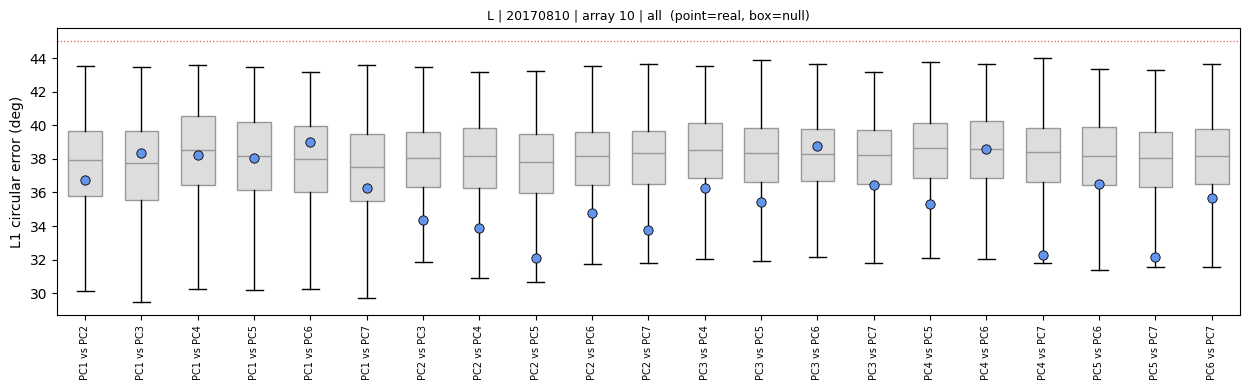

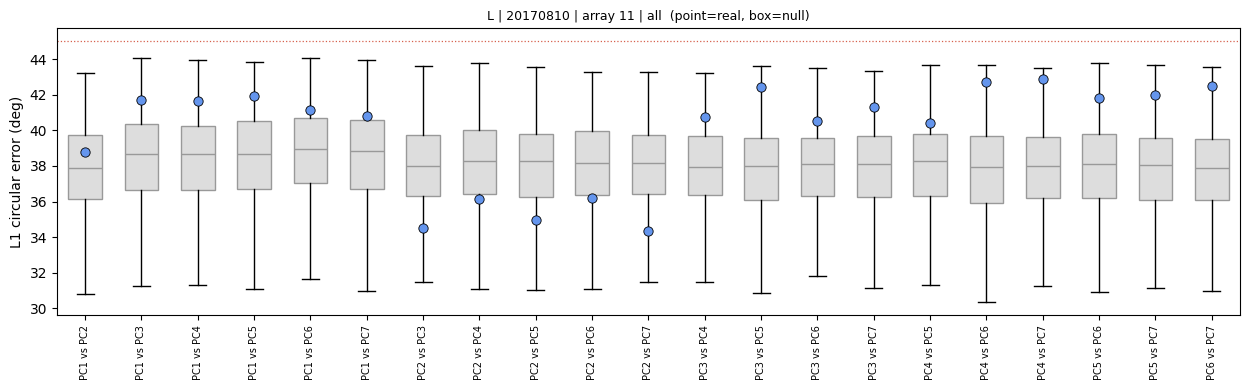

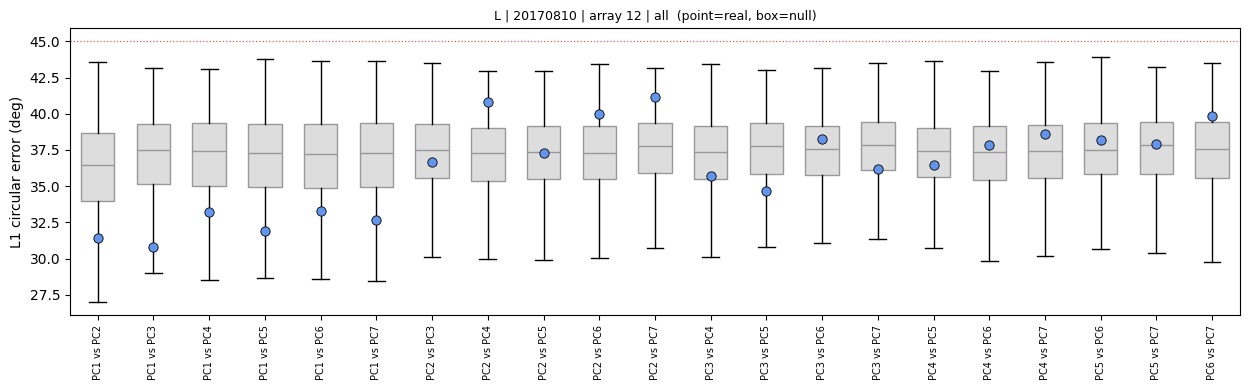

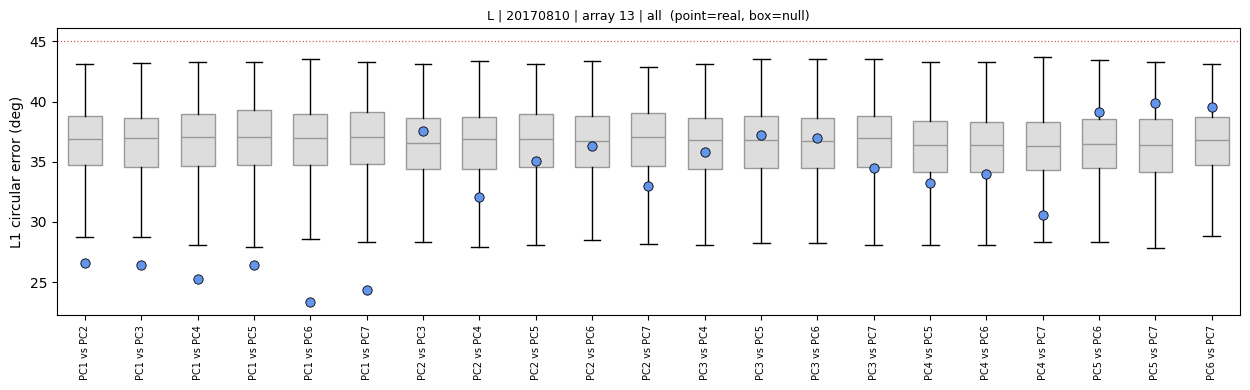

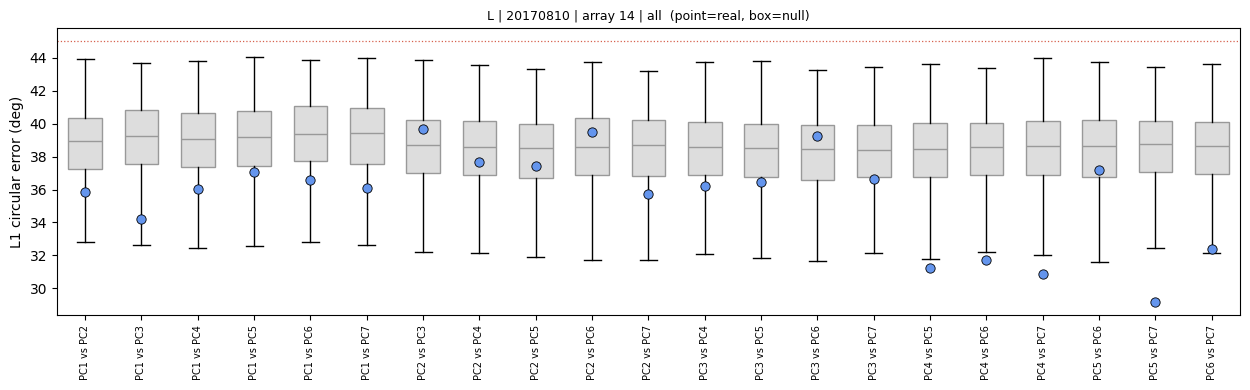

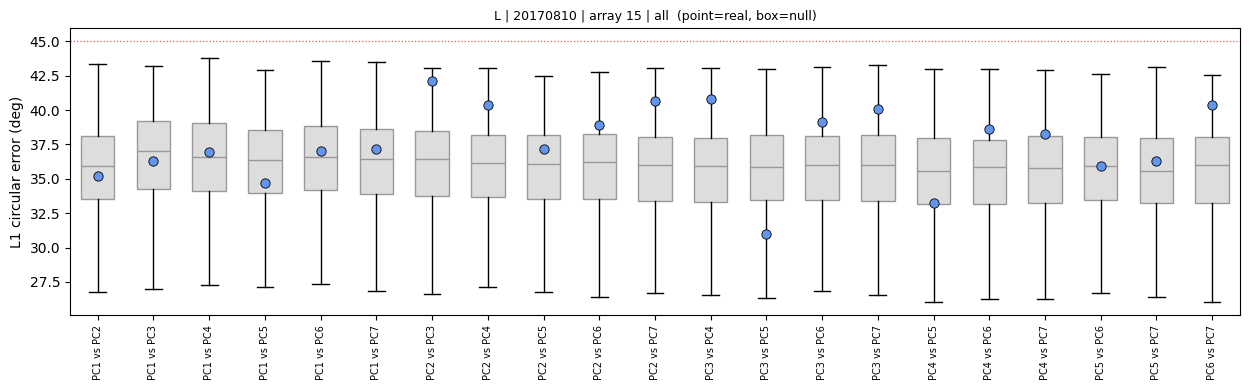

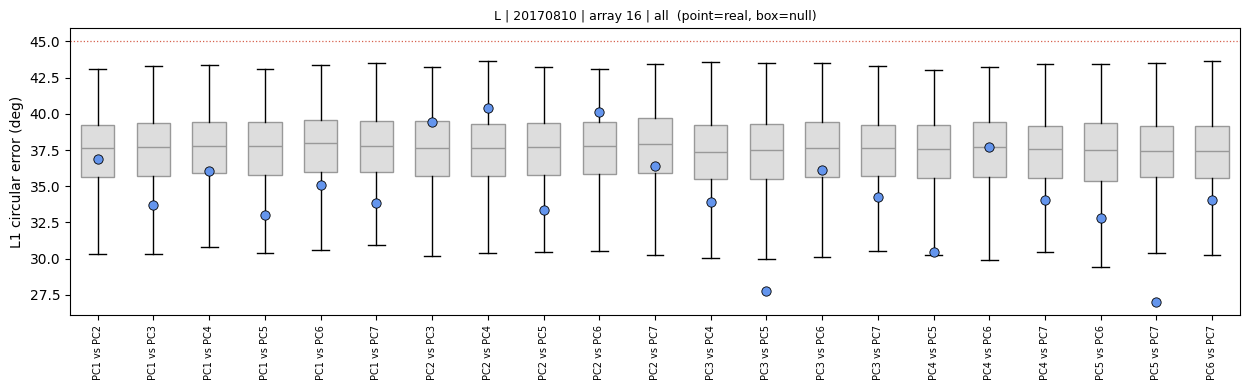

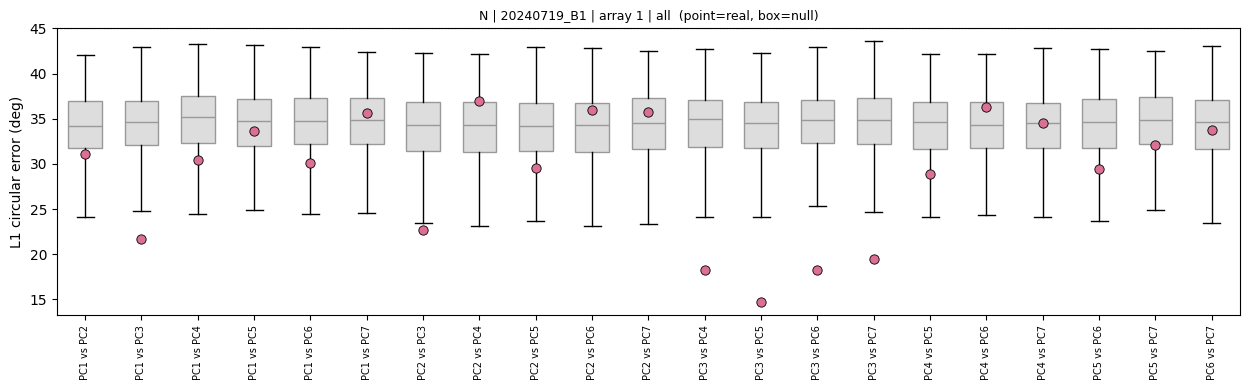

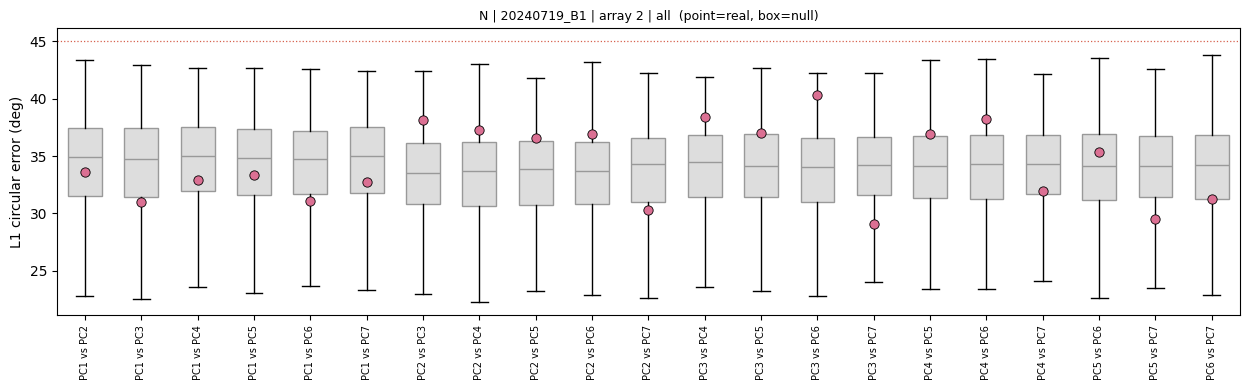

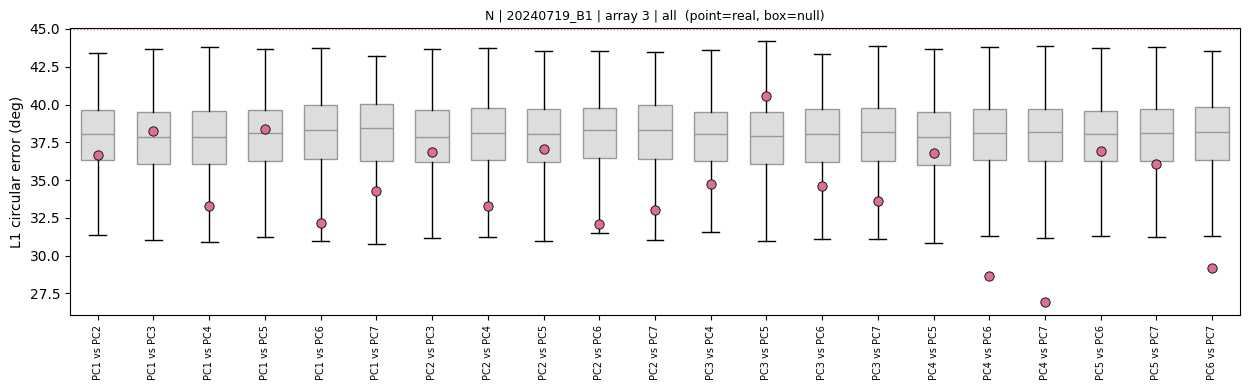

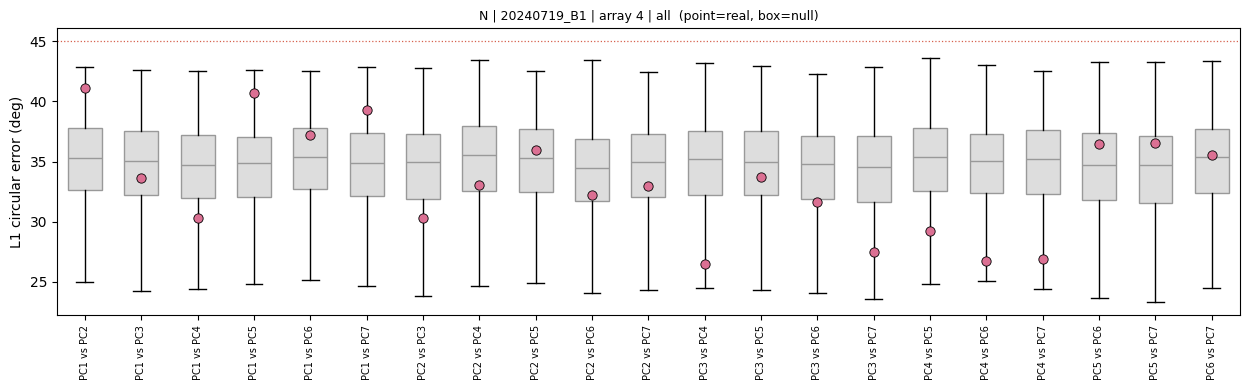

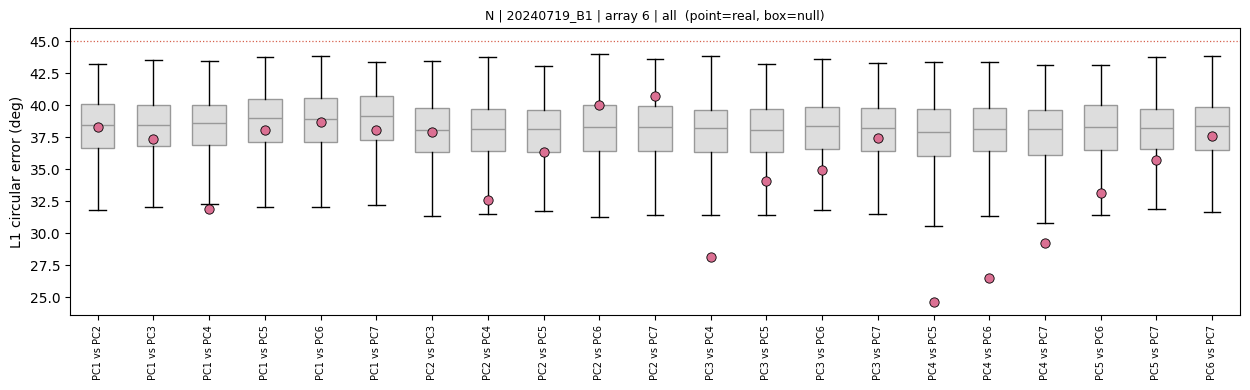

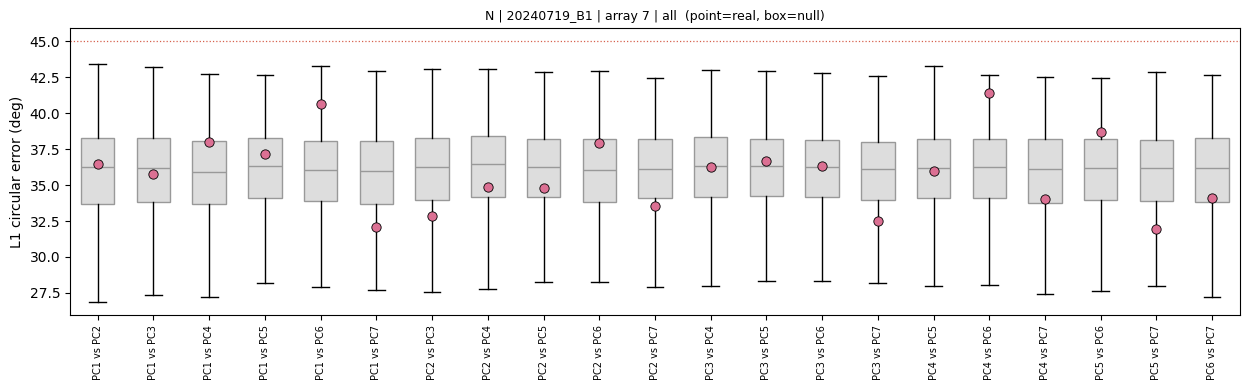

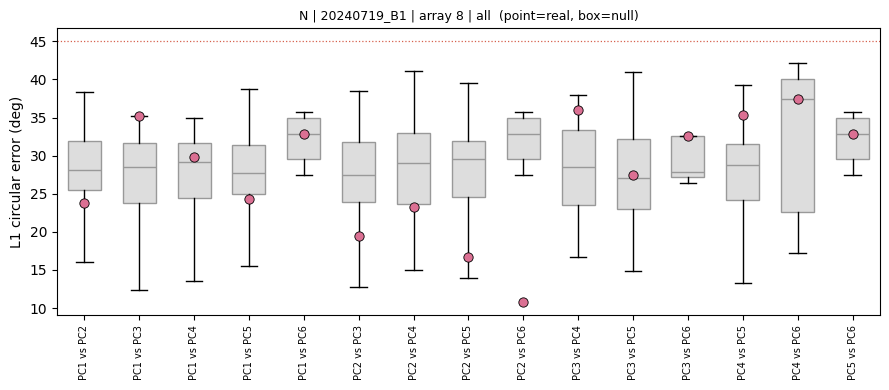

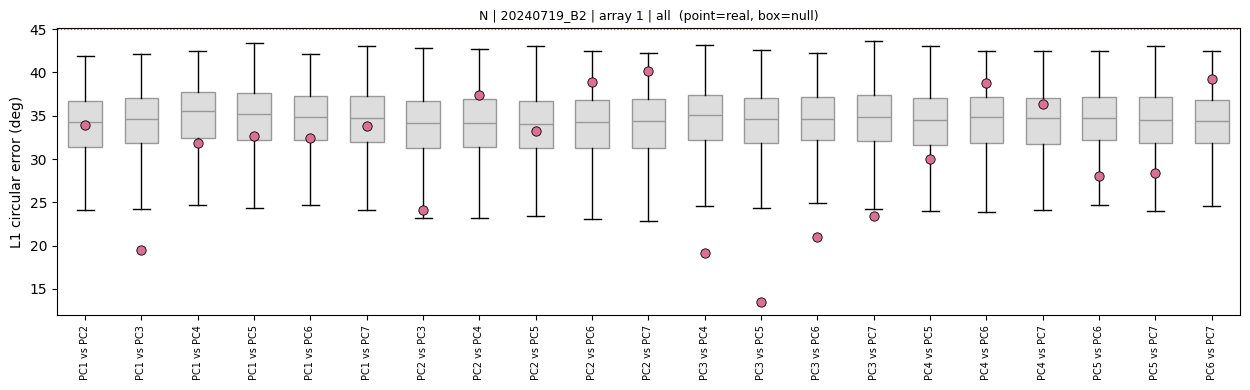

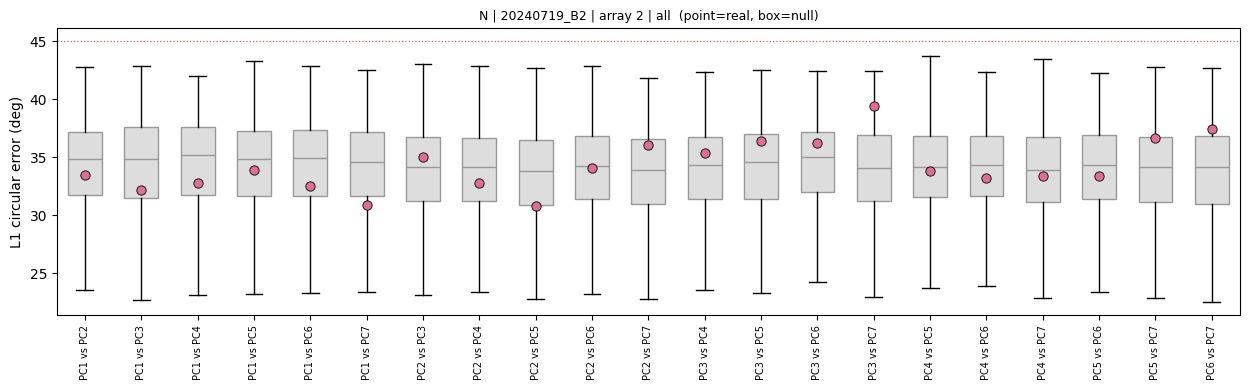

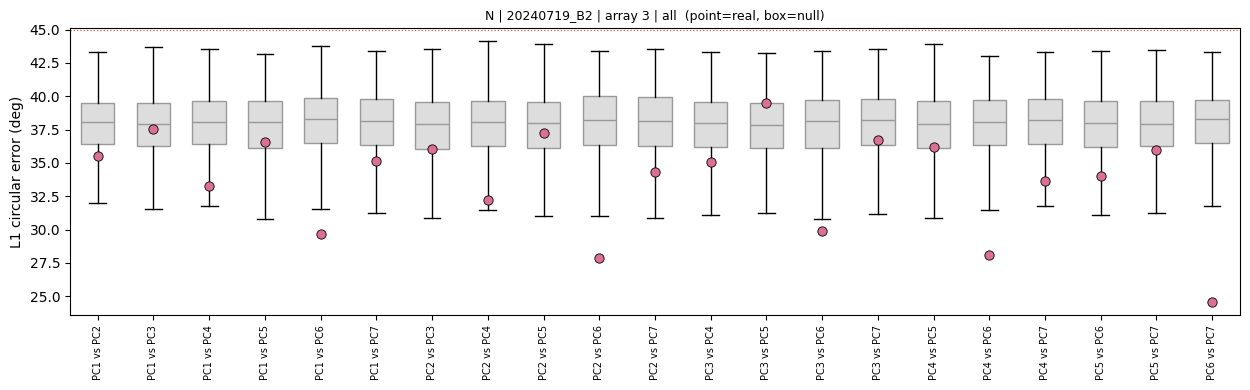

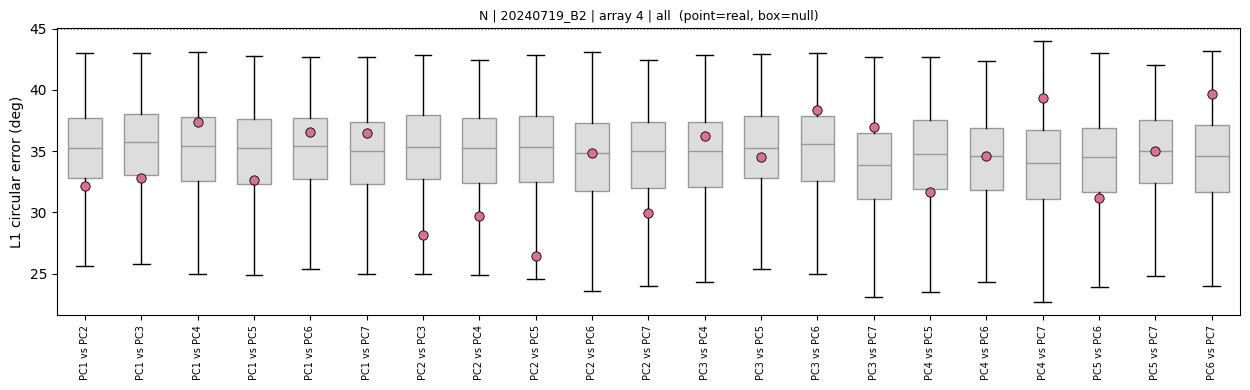

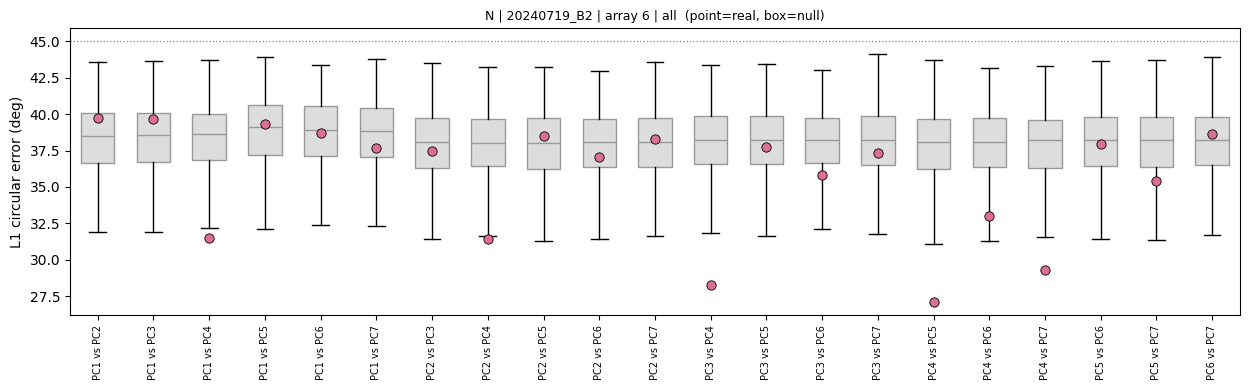

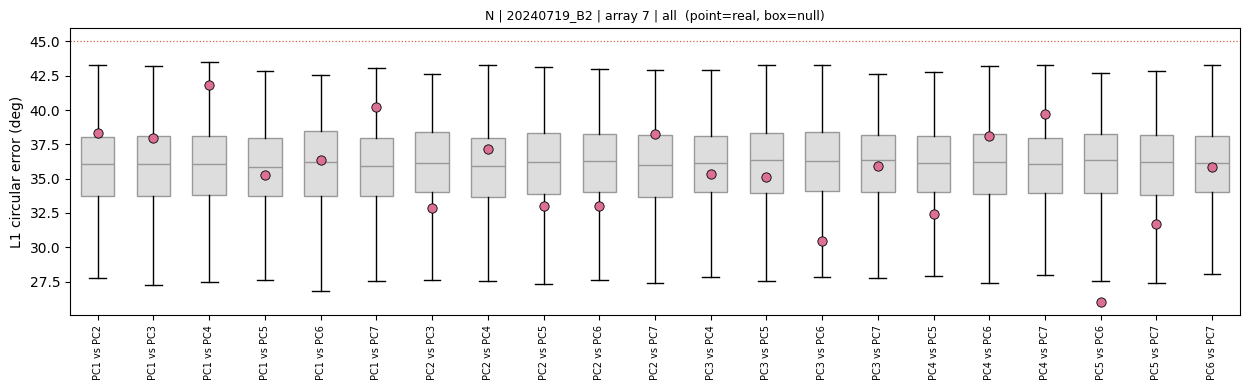

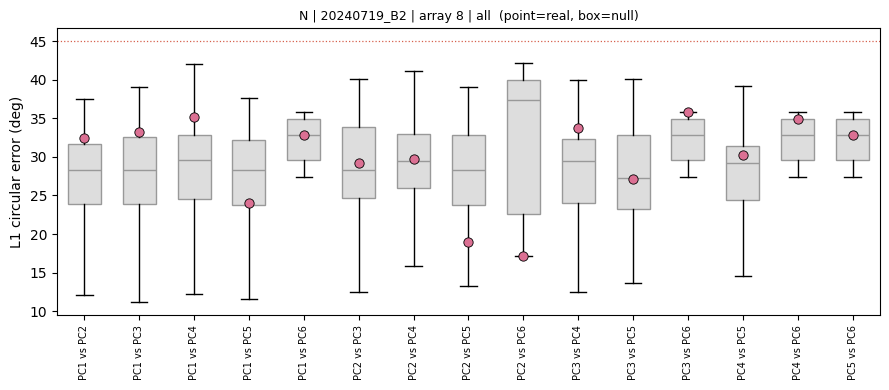

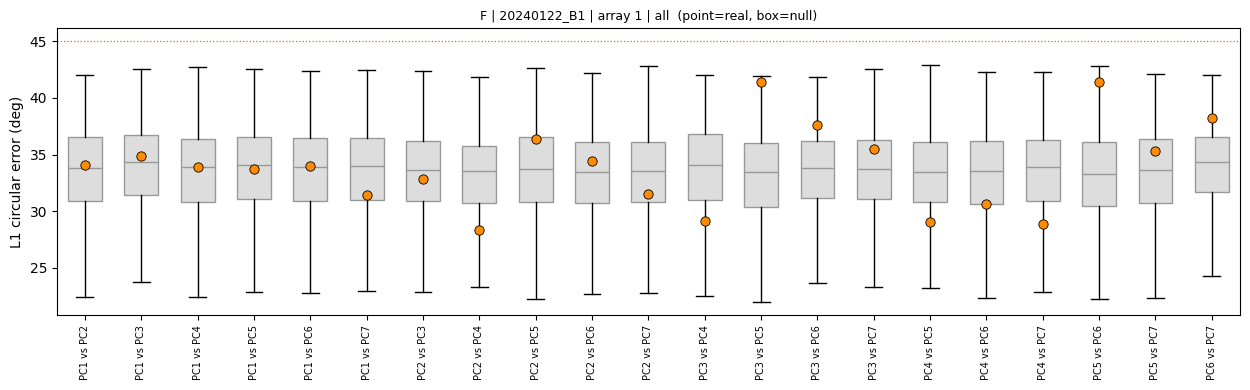

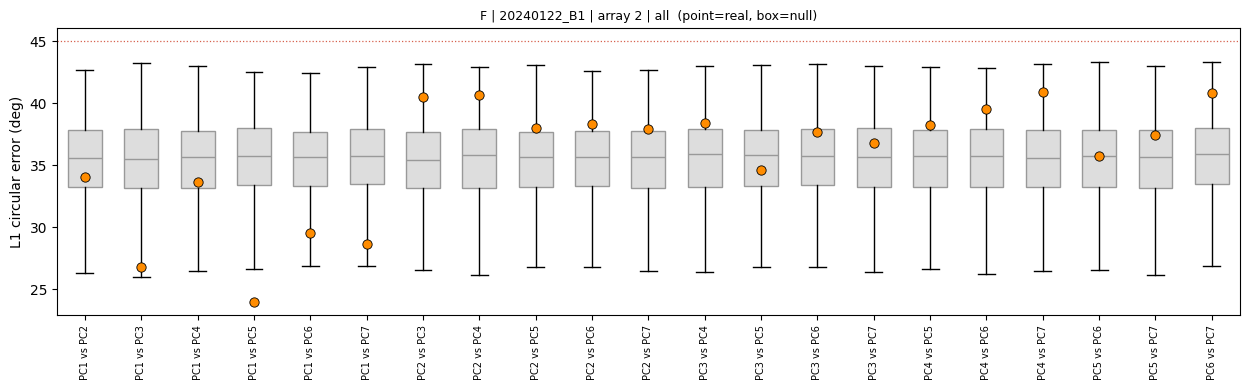

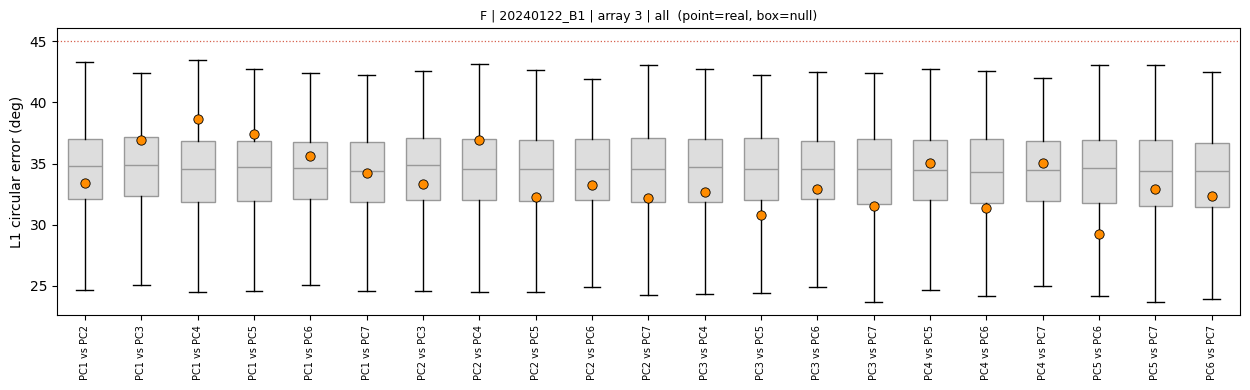

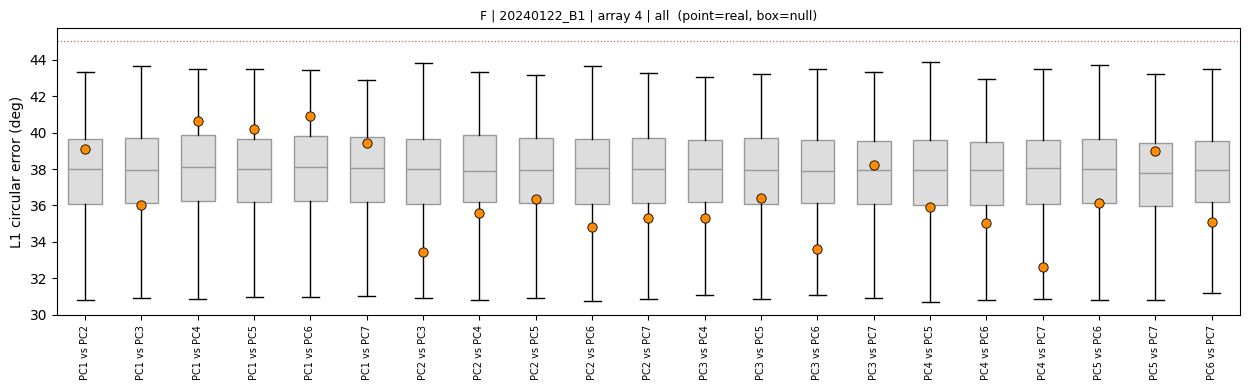

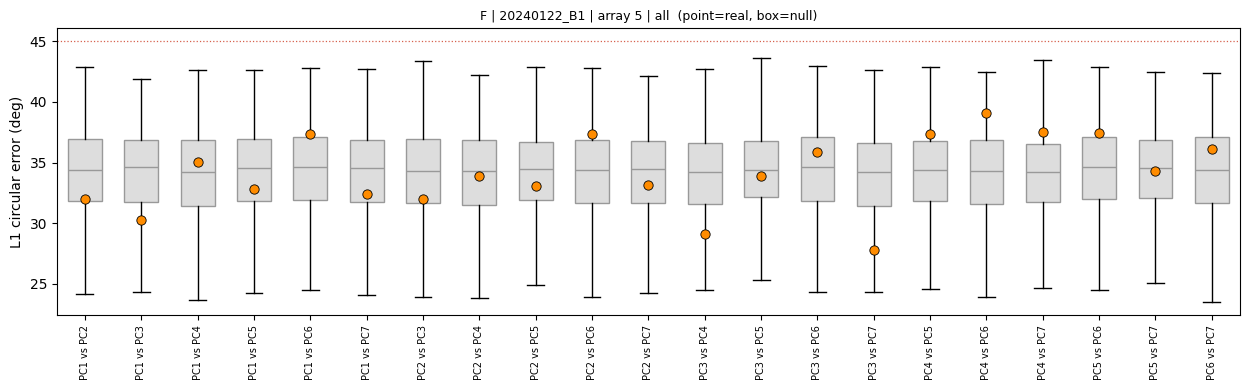

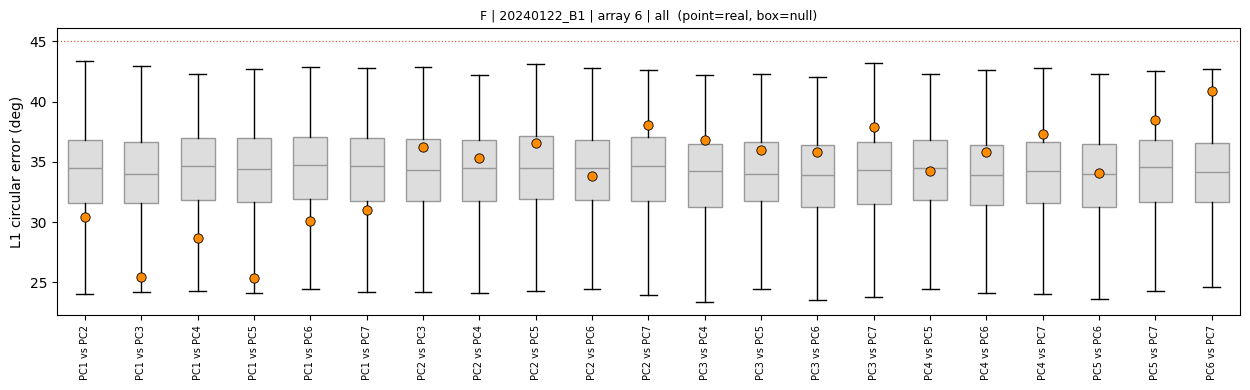

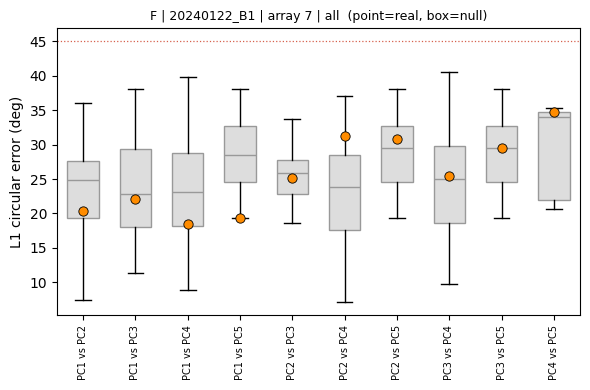

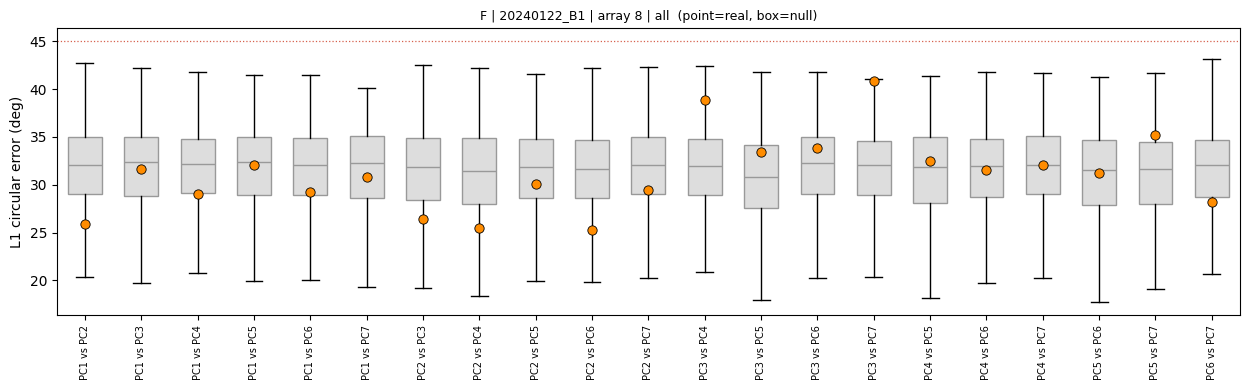

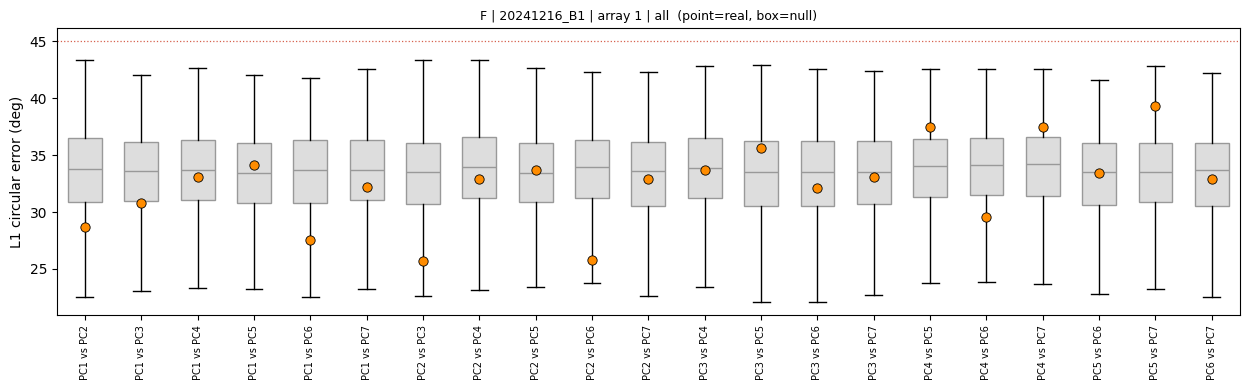

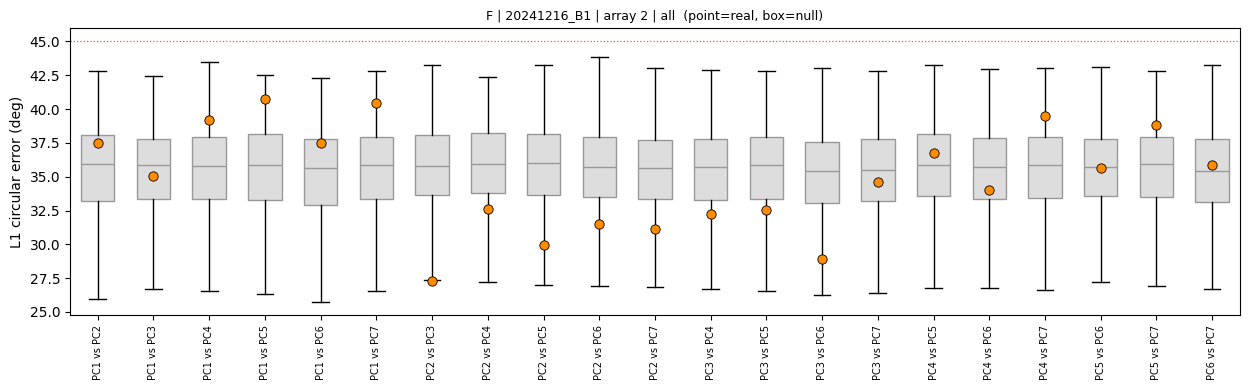

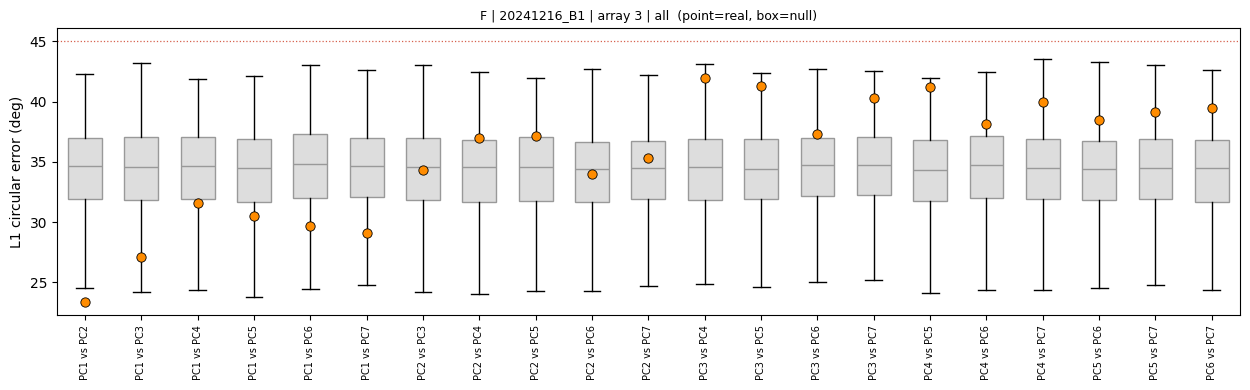

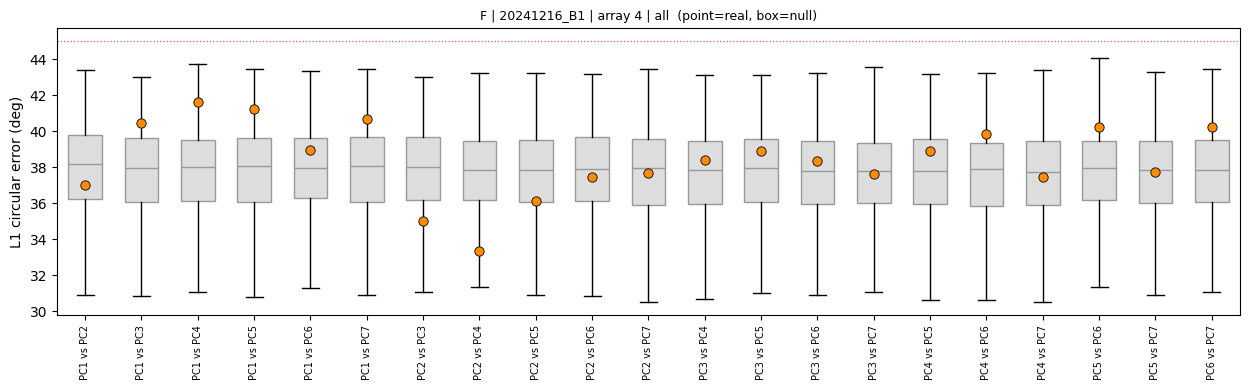

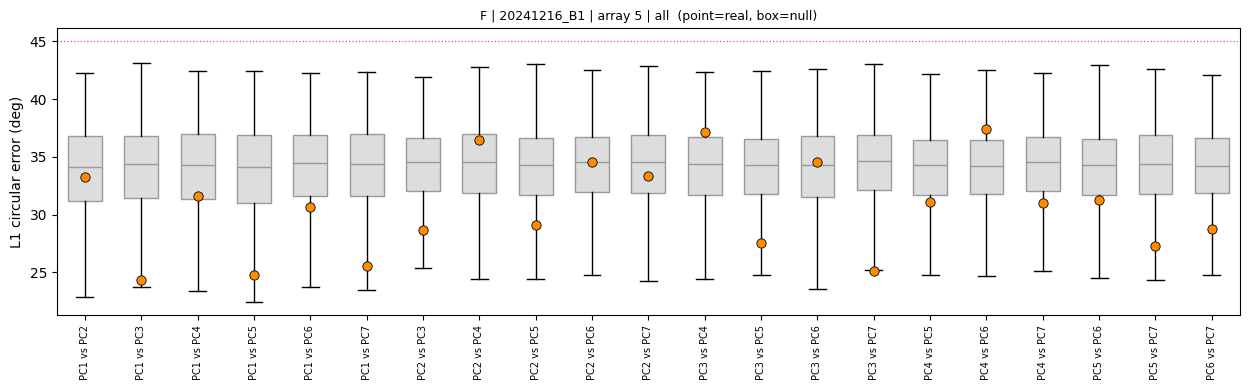

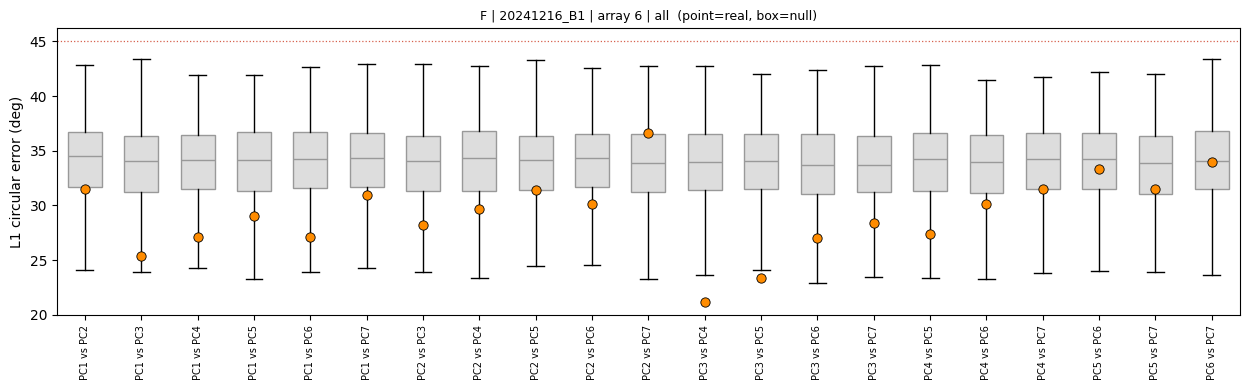

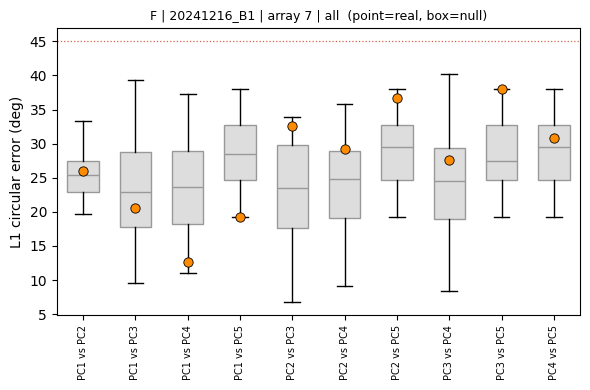

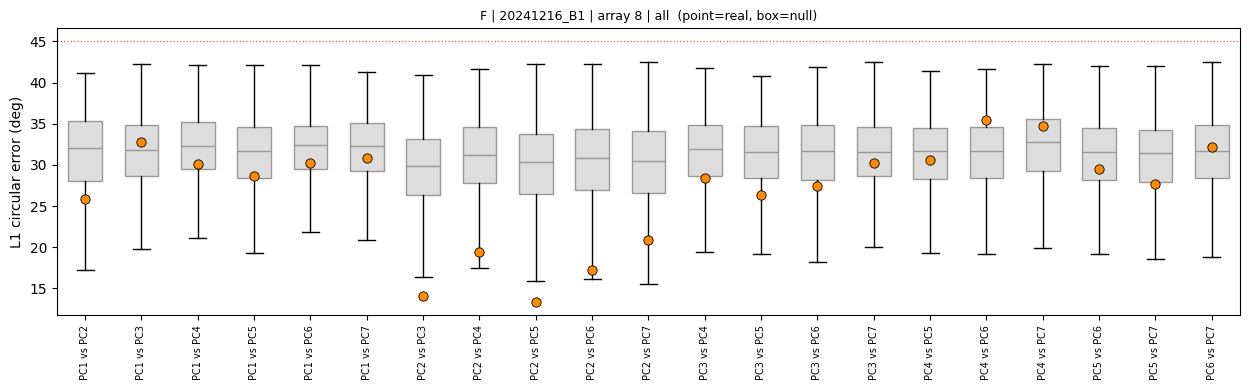

In [12]:
# example — adjust to an array that exists in your data
for m in ['L','N','F']:
    for d in DATES[m]['RS']:
        for a in V1_ARRAYS[m]:
            plot_pair_errors(m, d, a, "all", norm="L1")
            plt.tight_layout()
            plt.show()

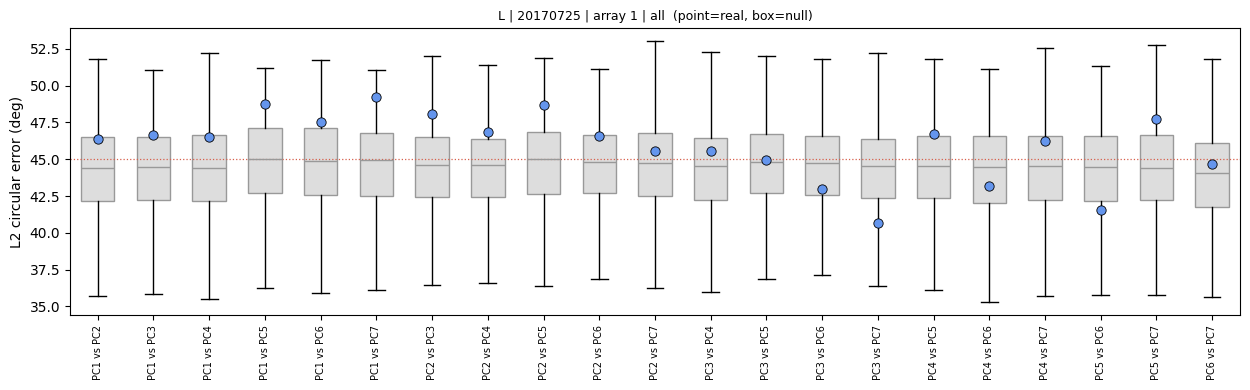

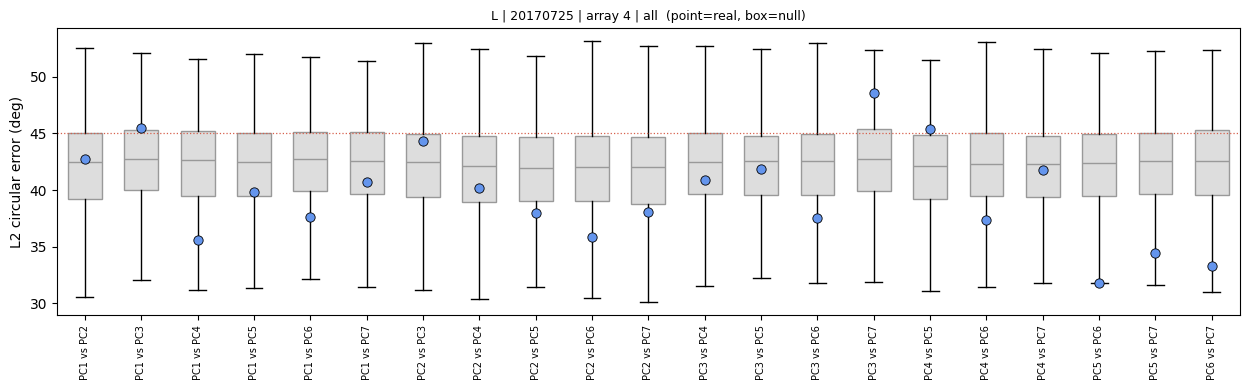

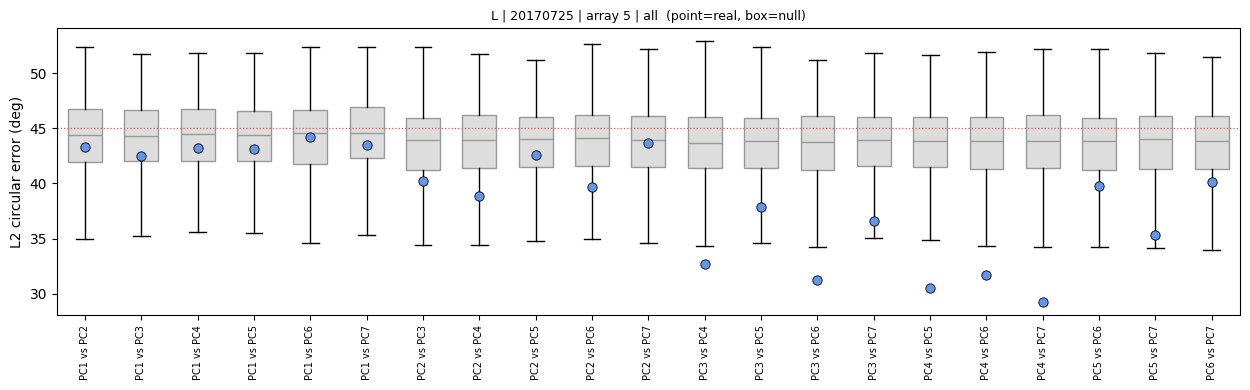

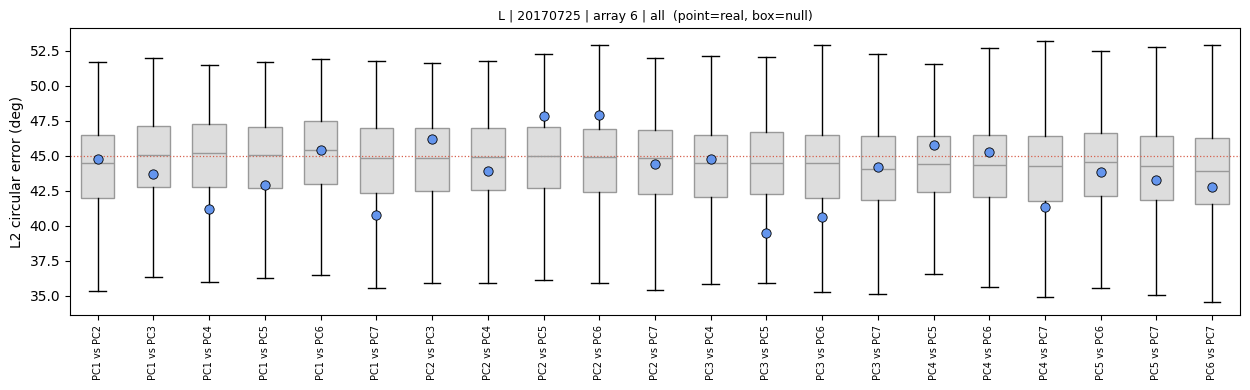

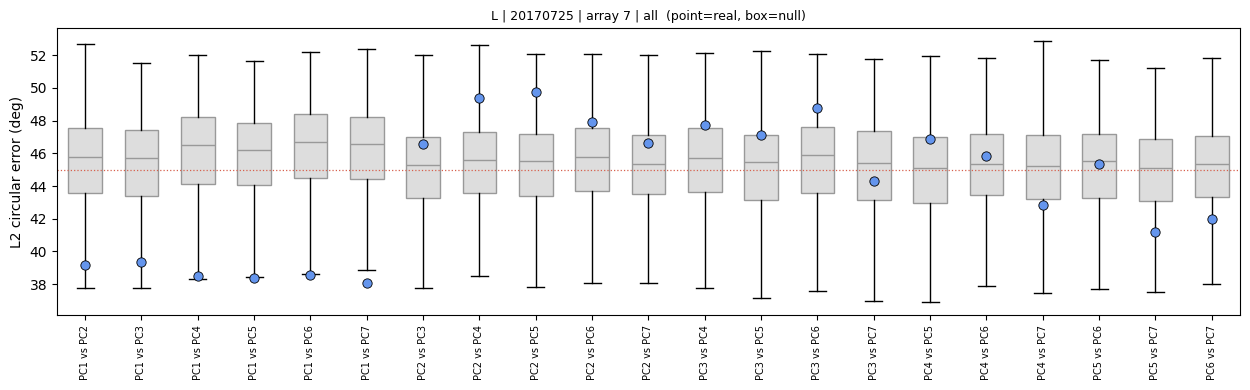

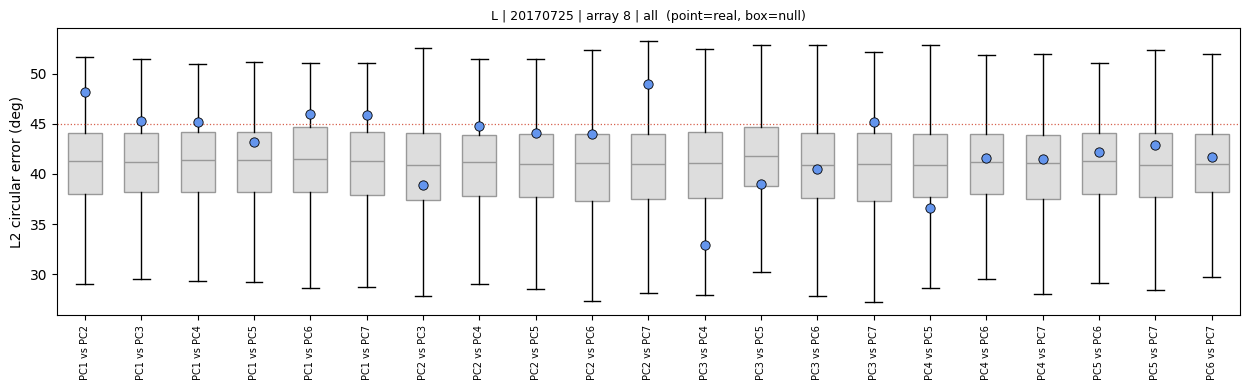

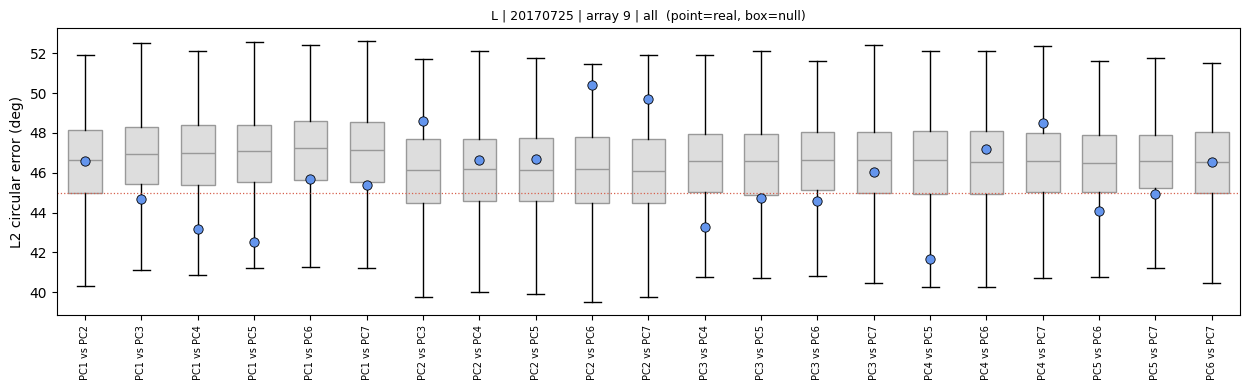

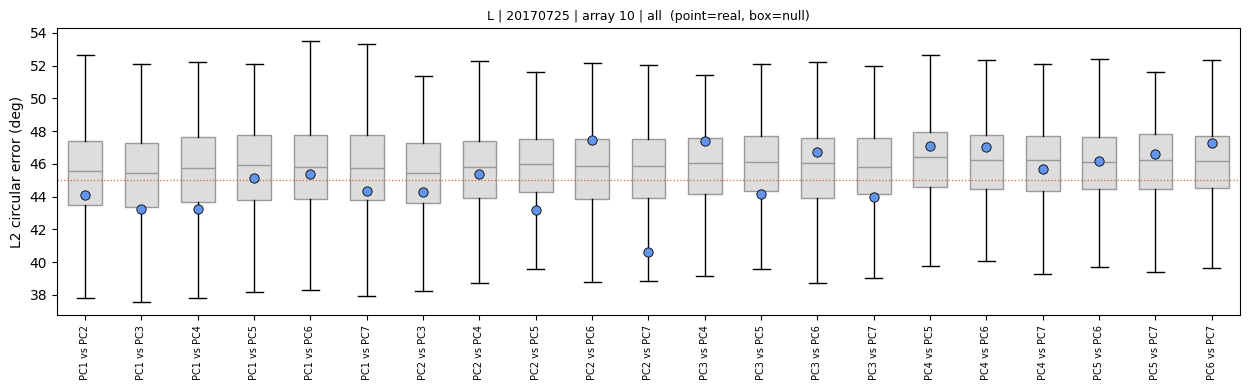

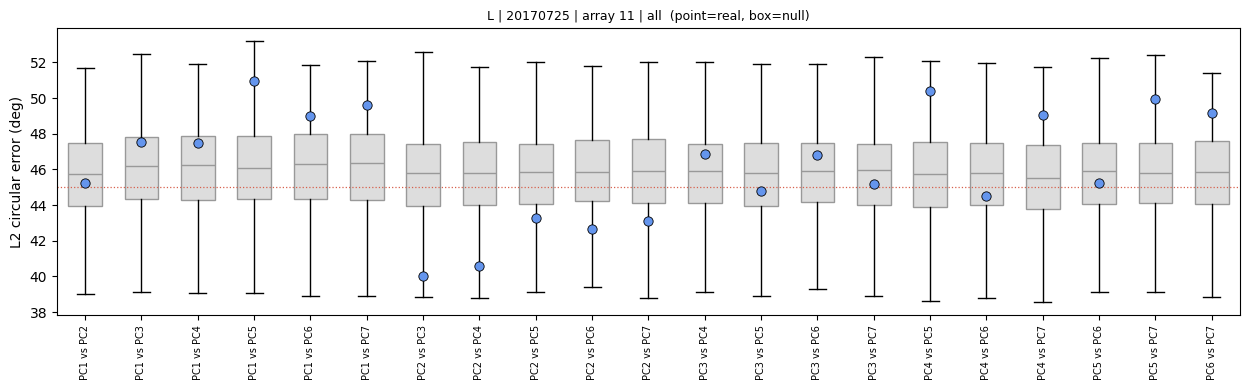

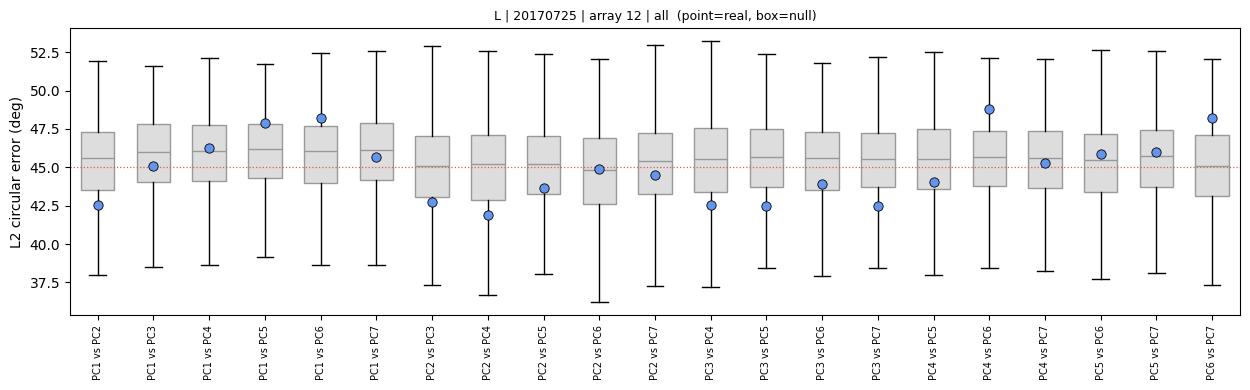

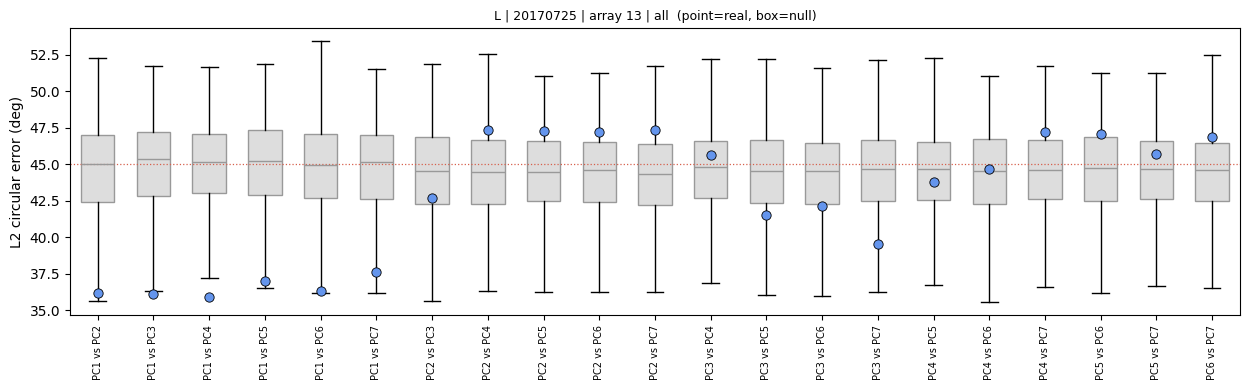

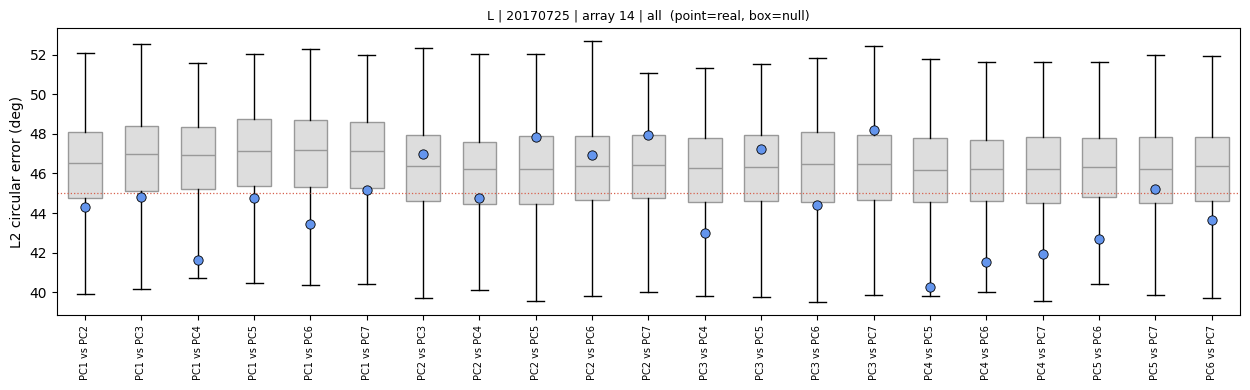

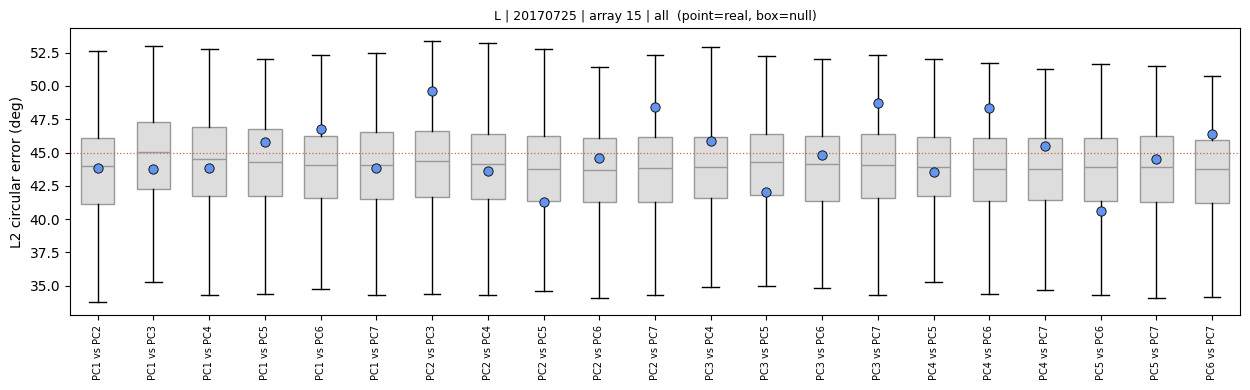

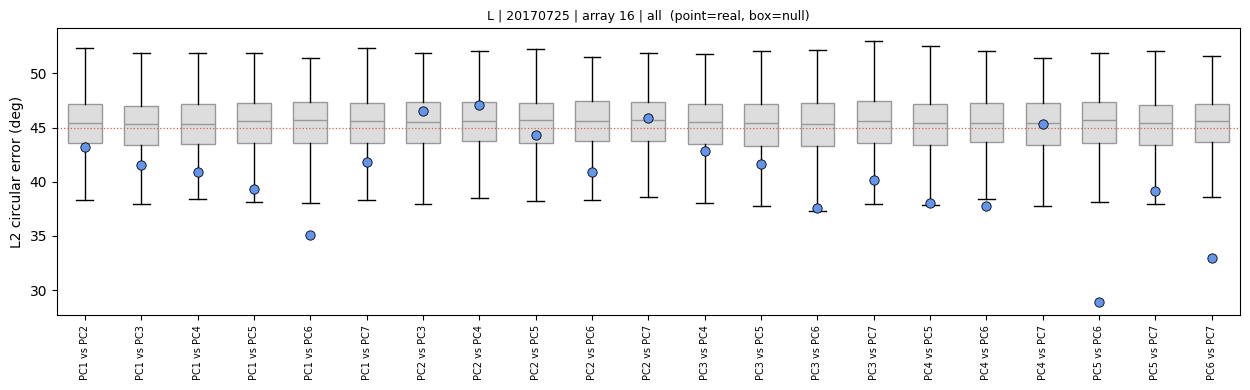

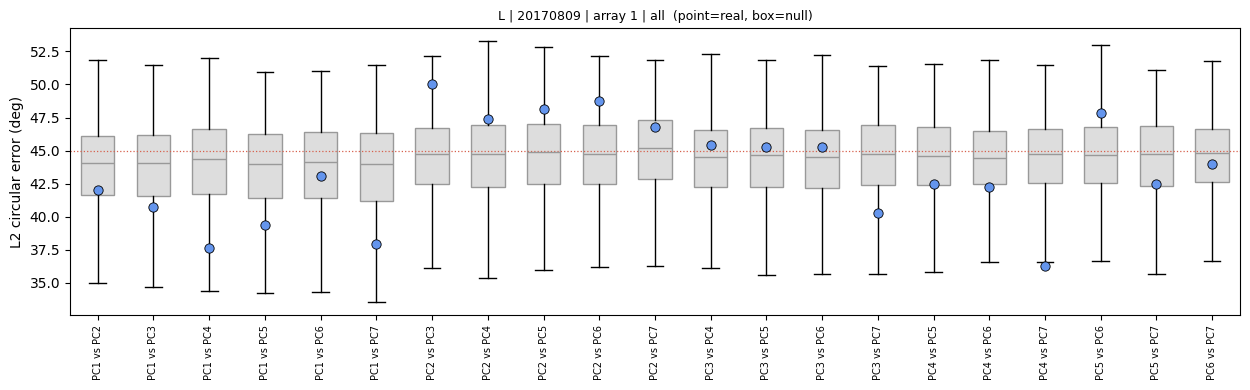

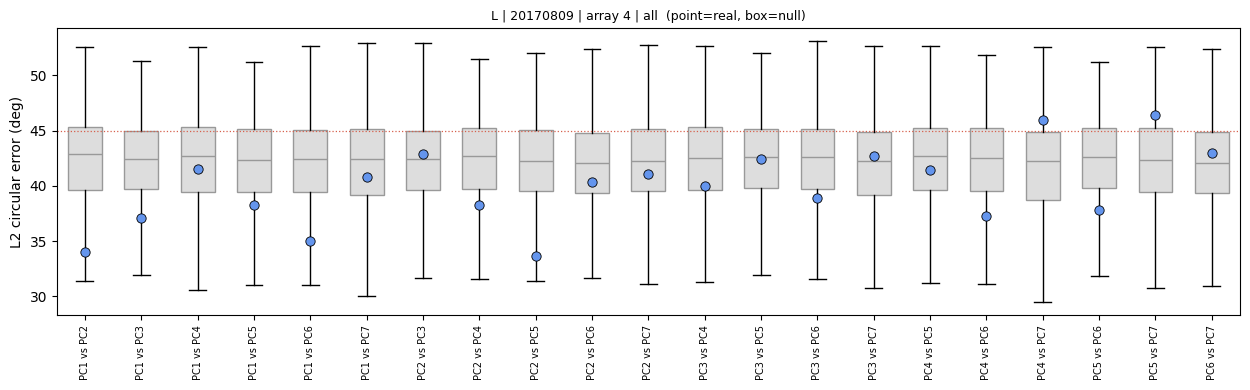

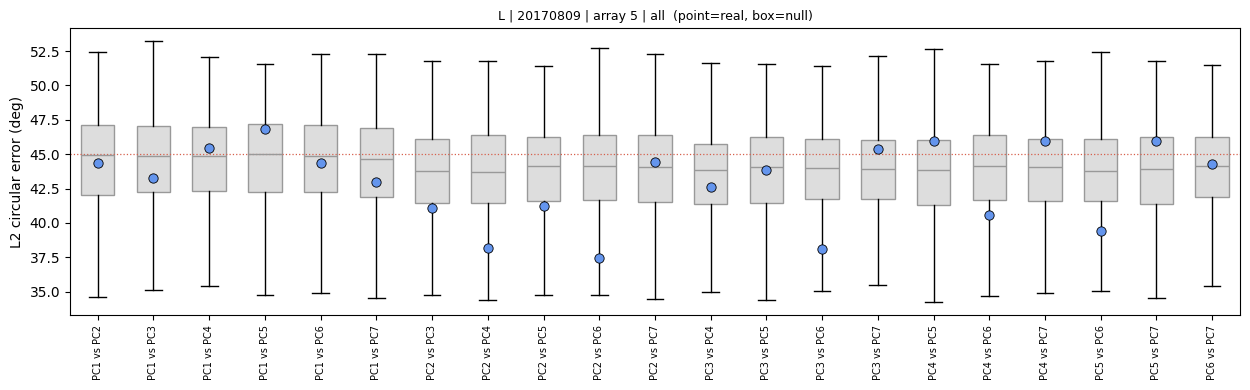

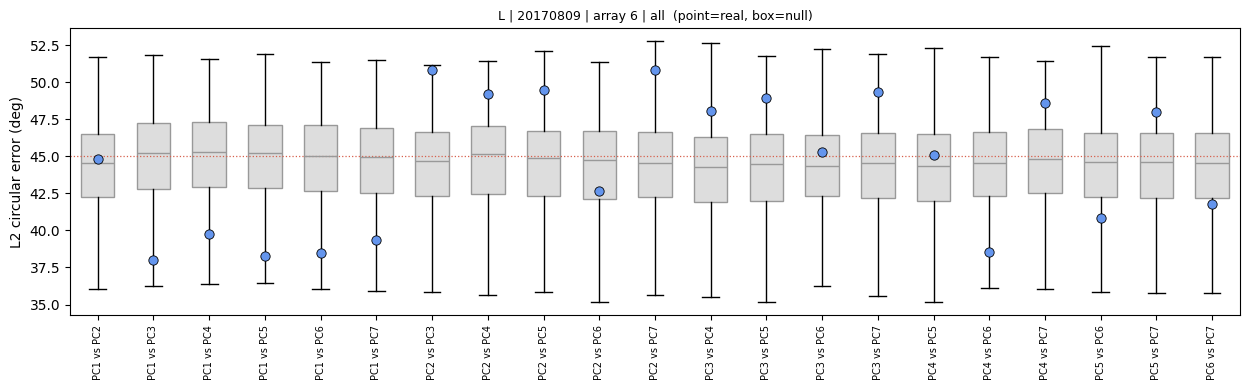

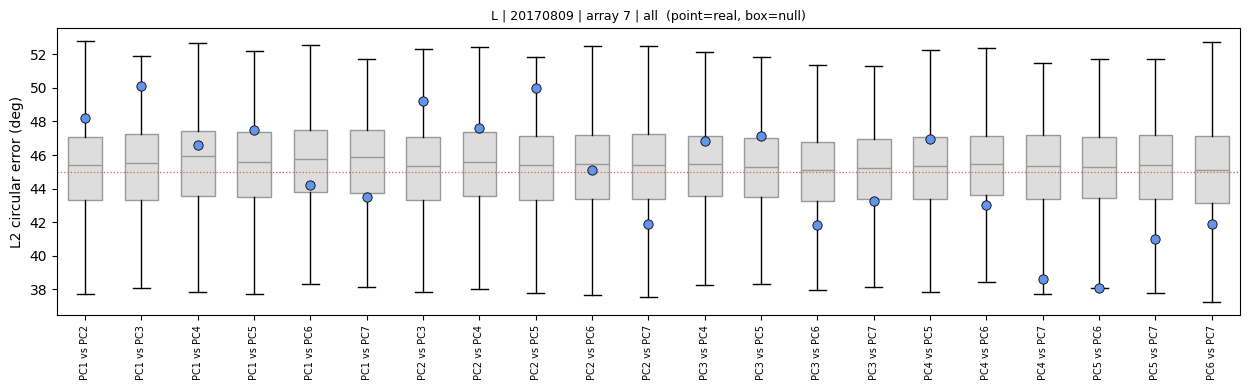

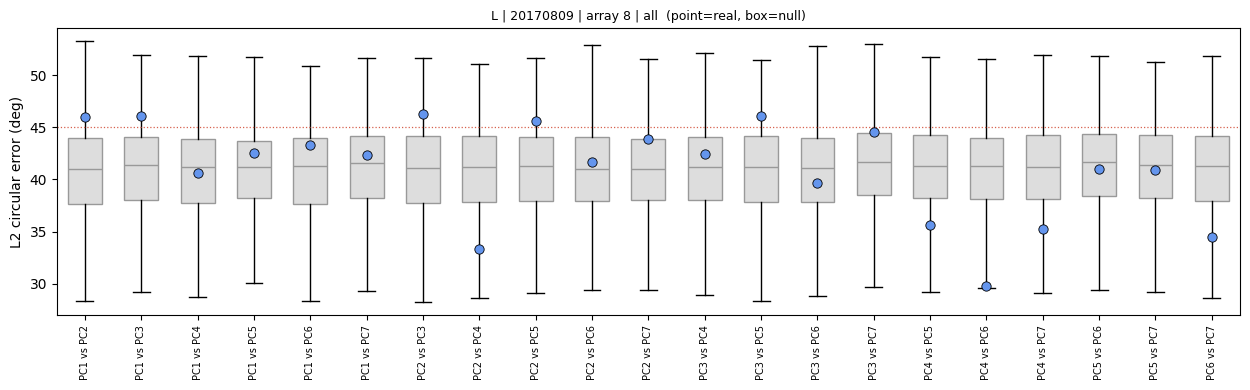

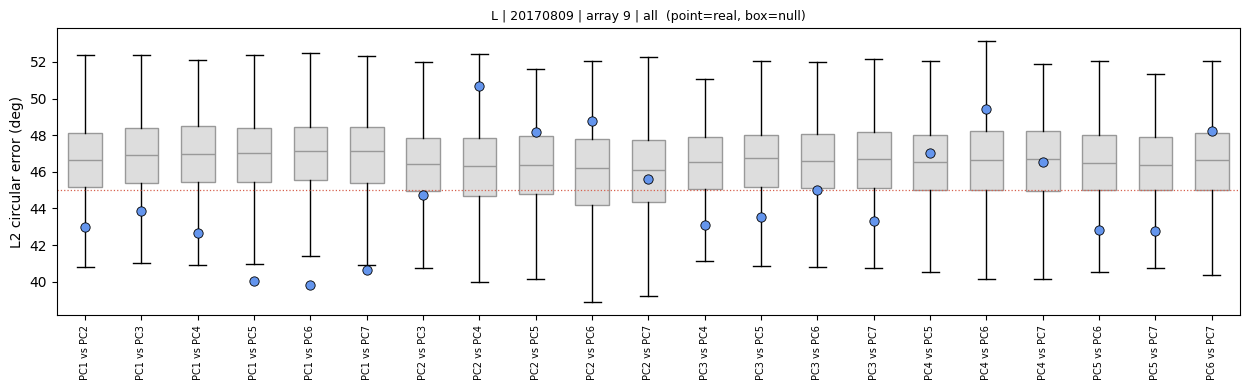

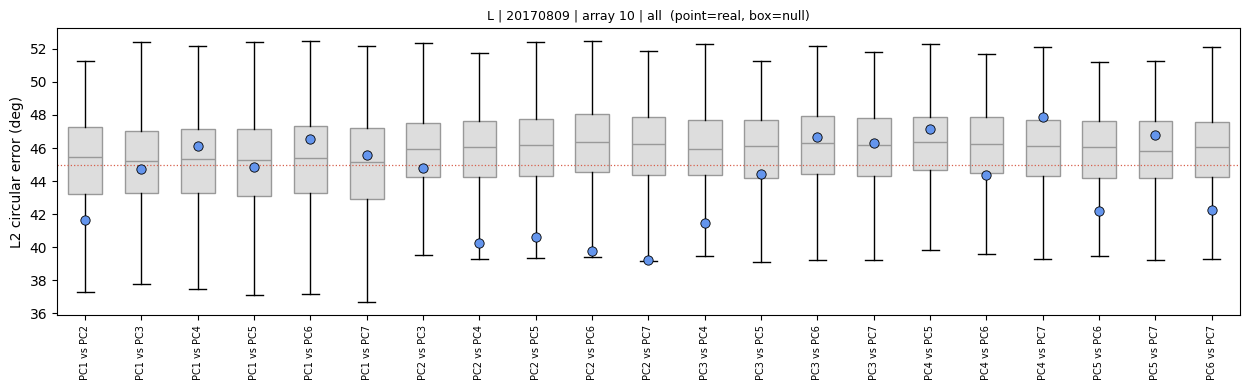

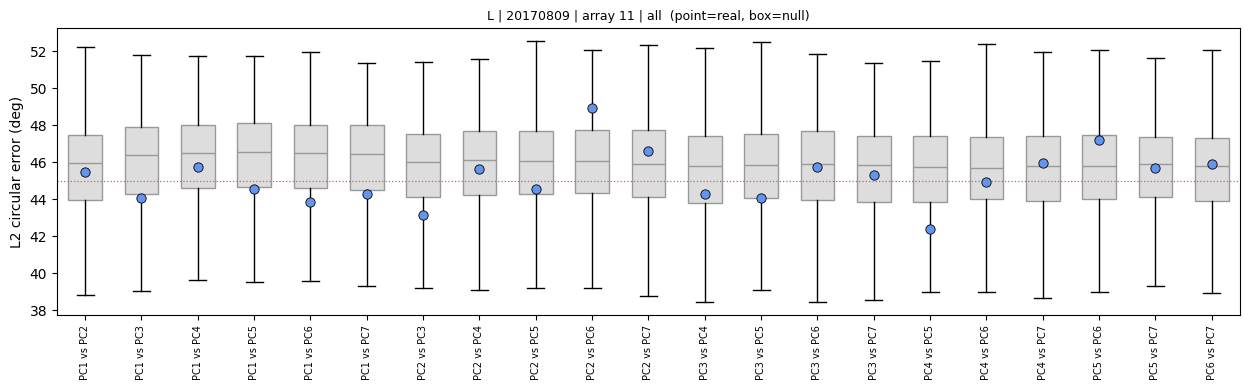

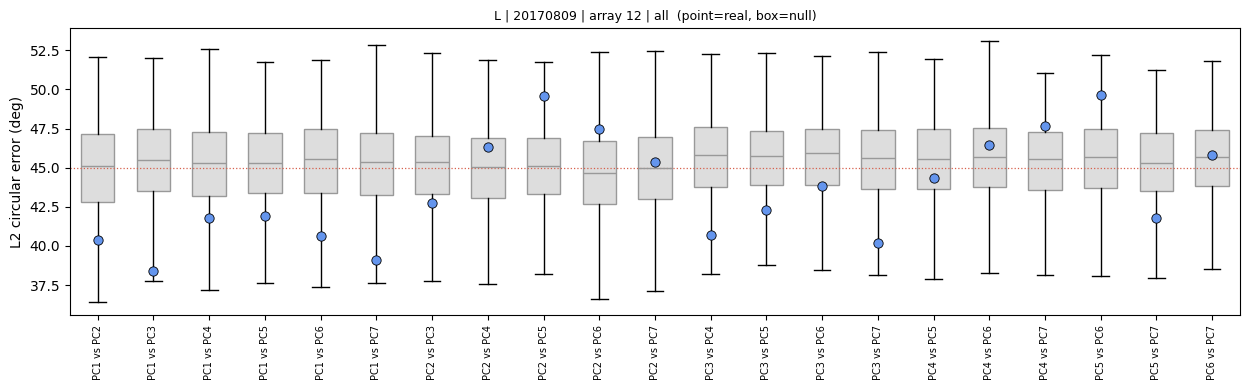

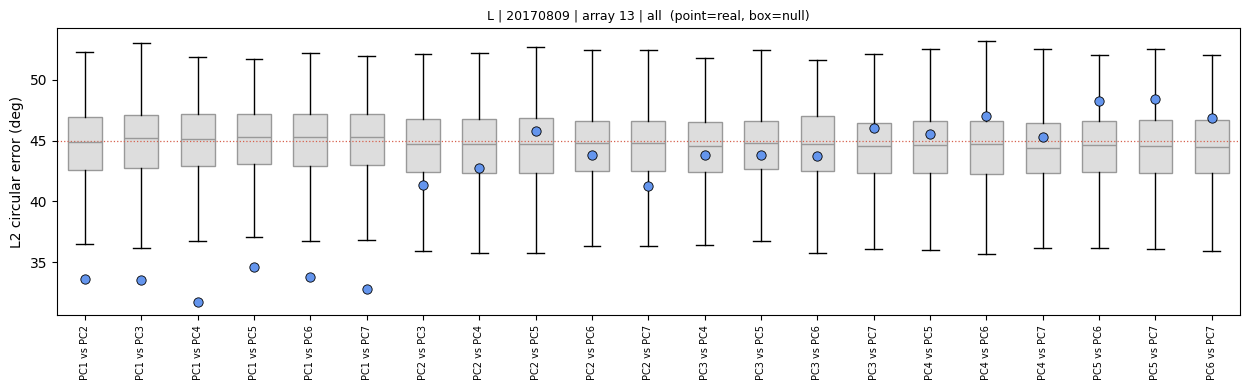

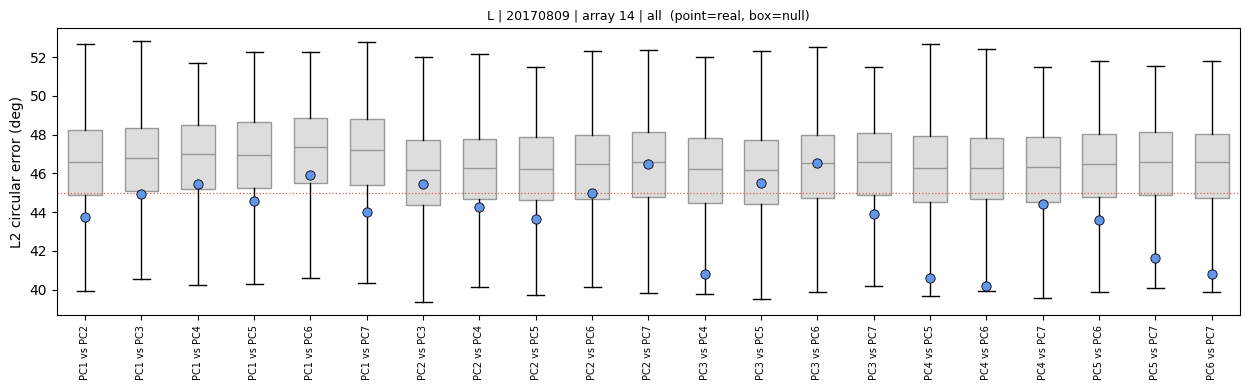

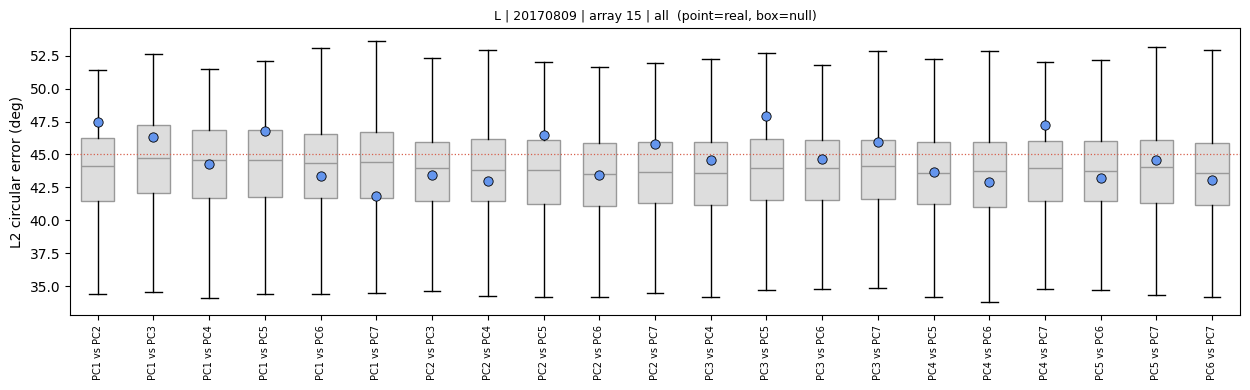

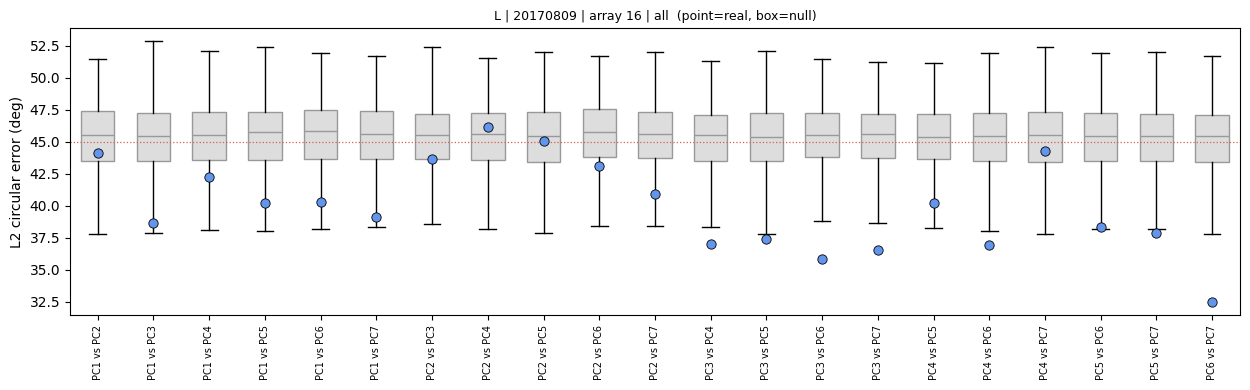

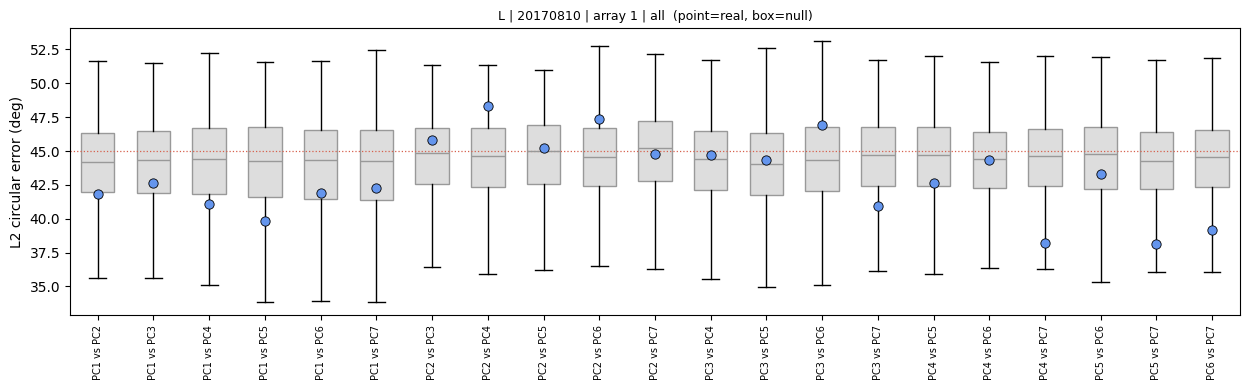

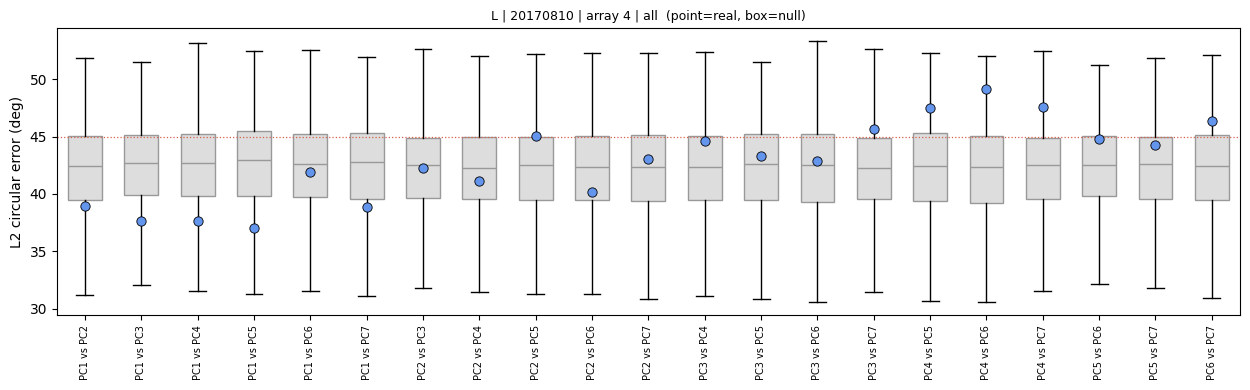

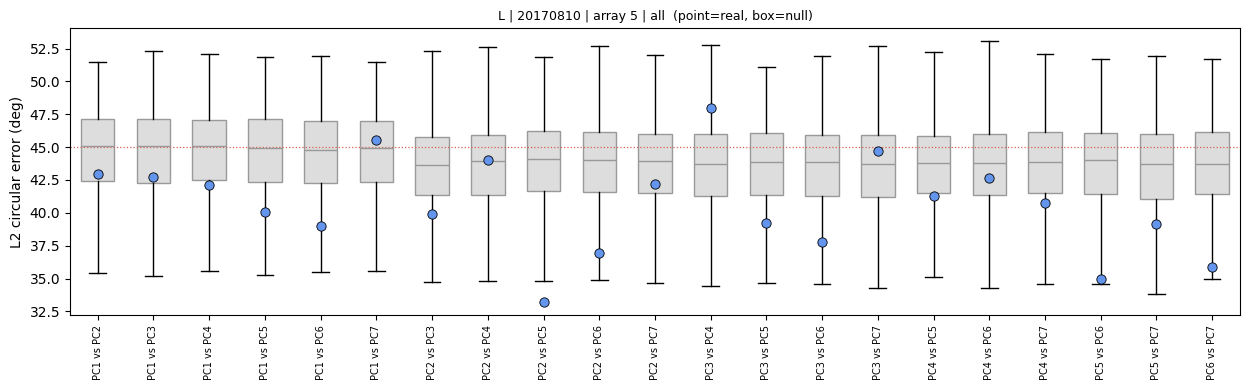

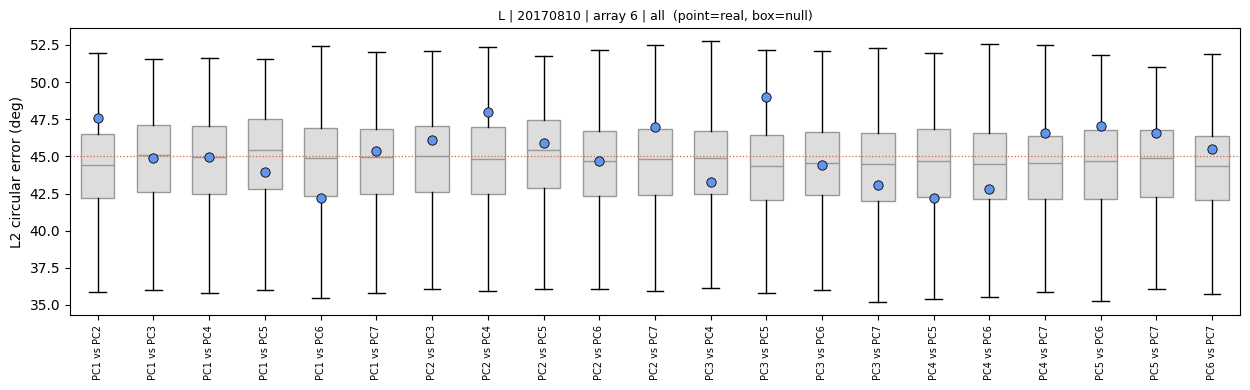

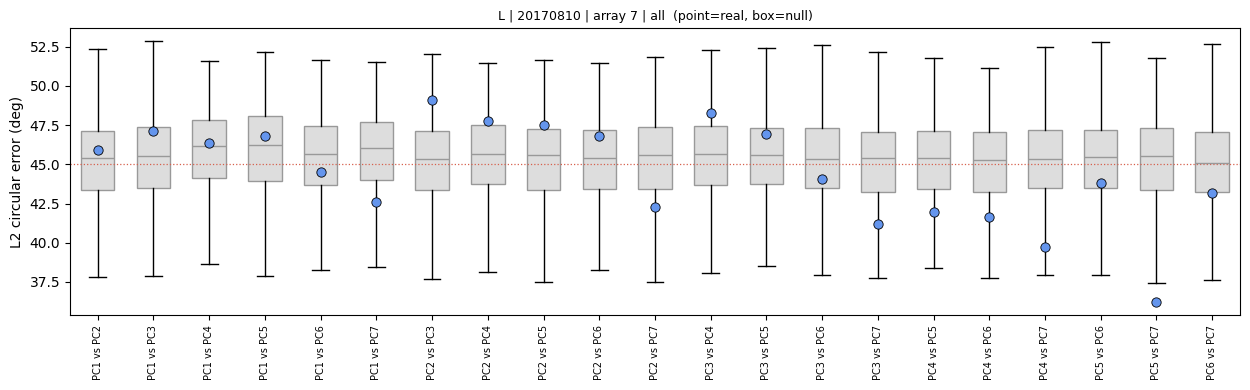

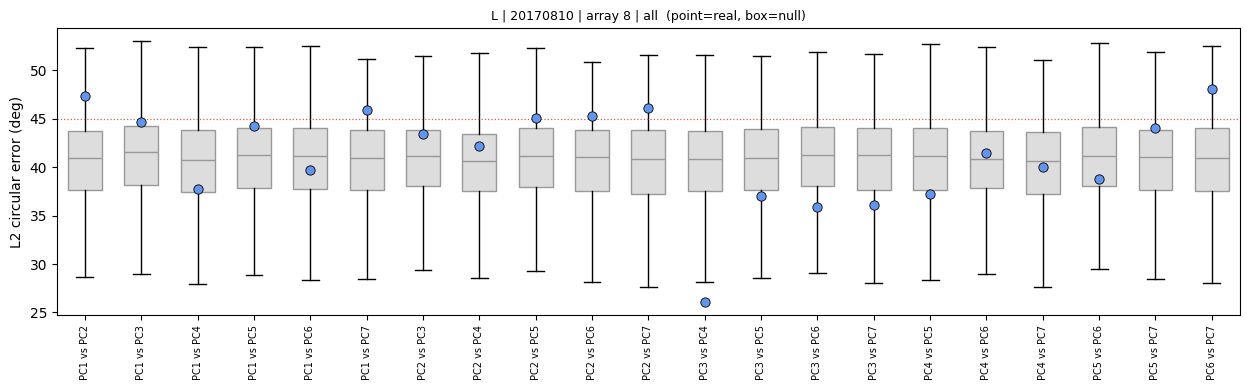

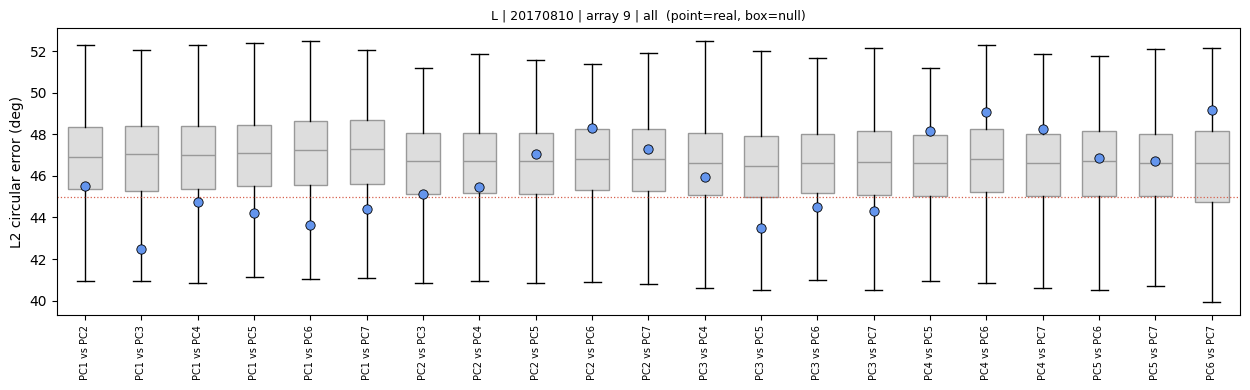

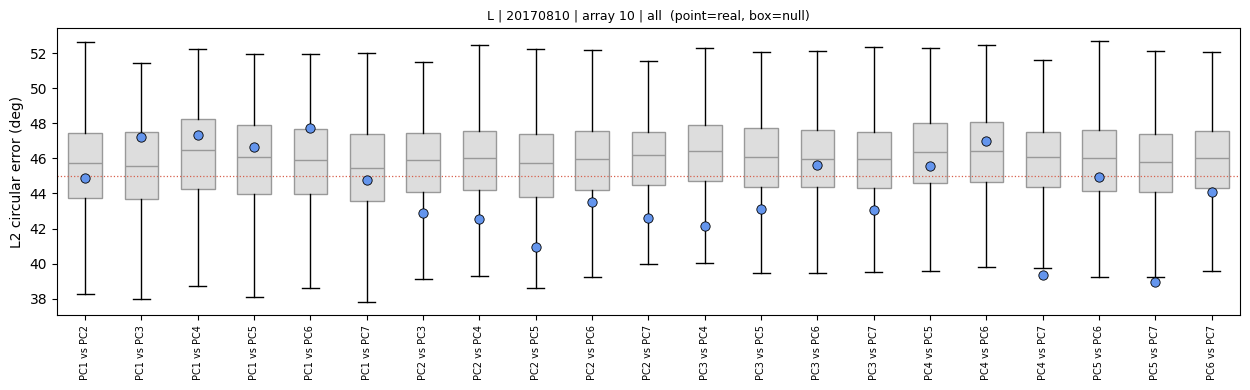

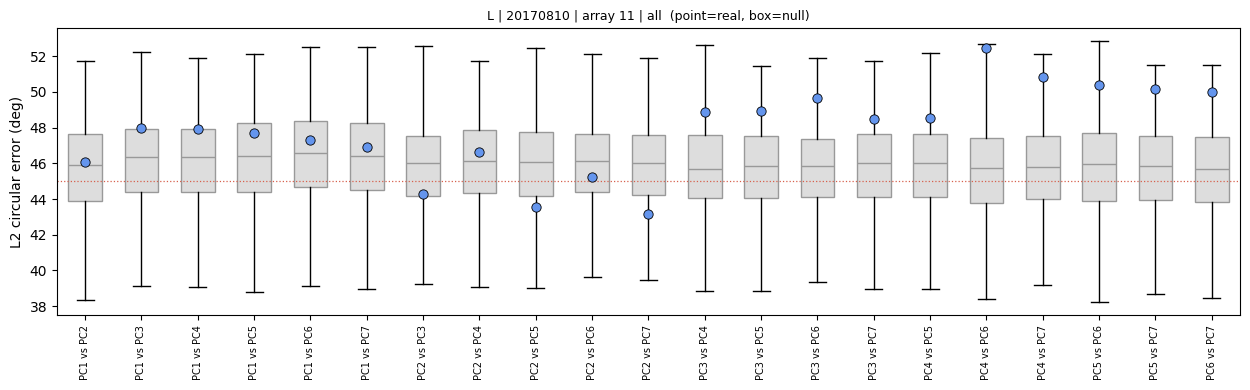

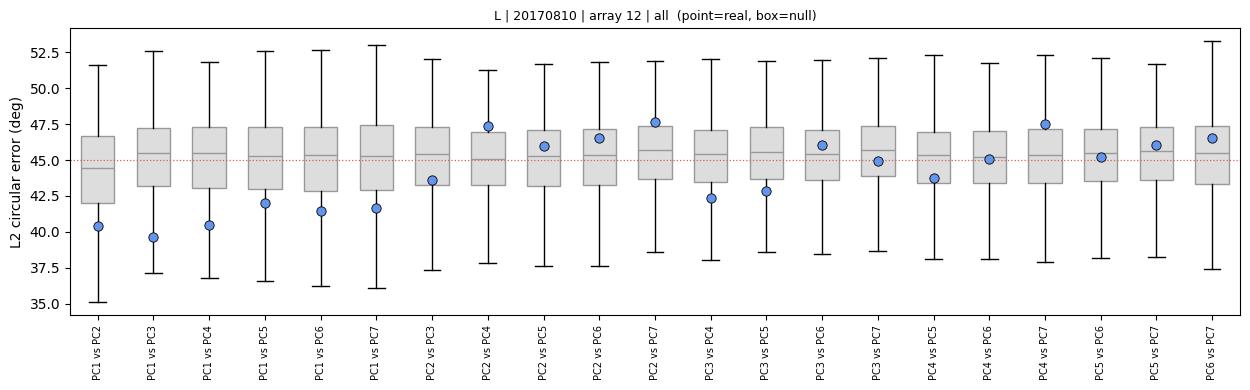

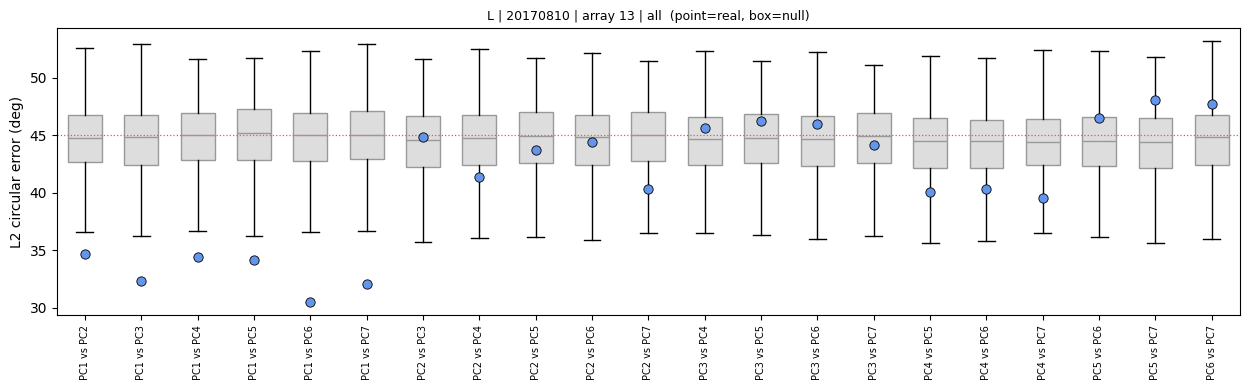

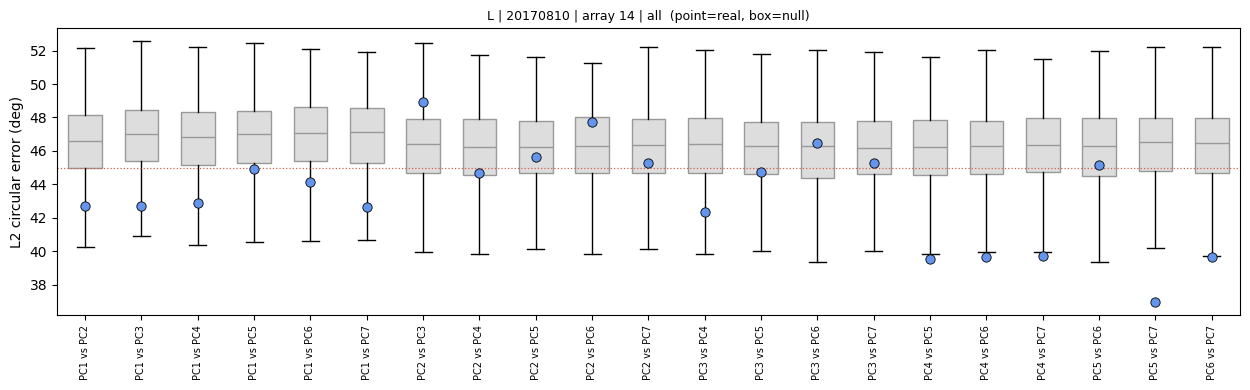

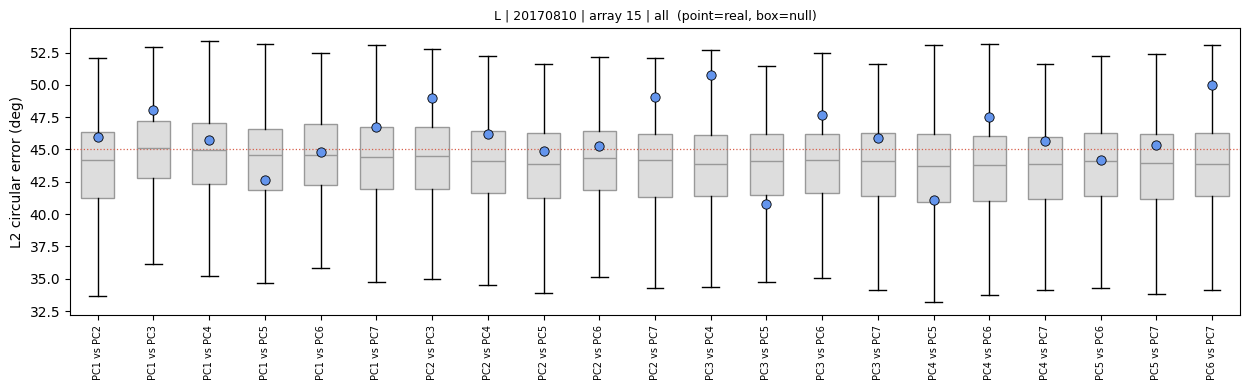

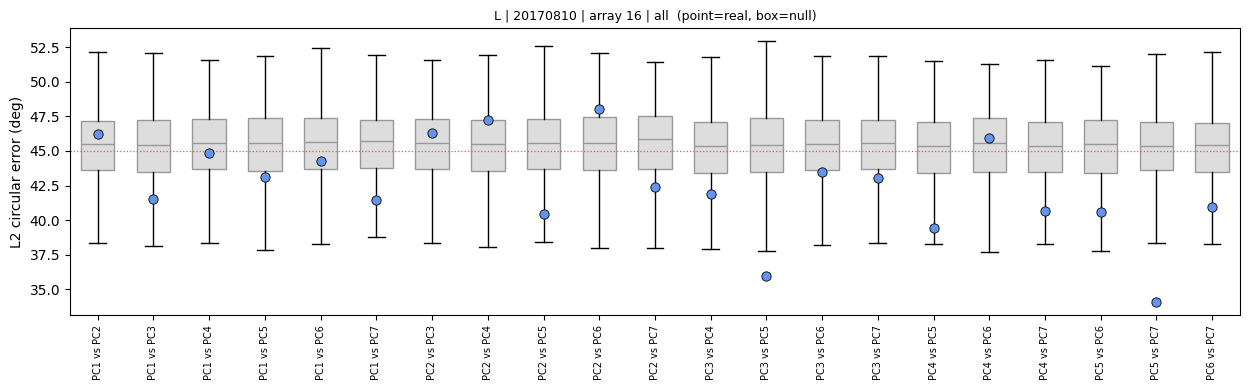

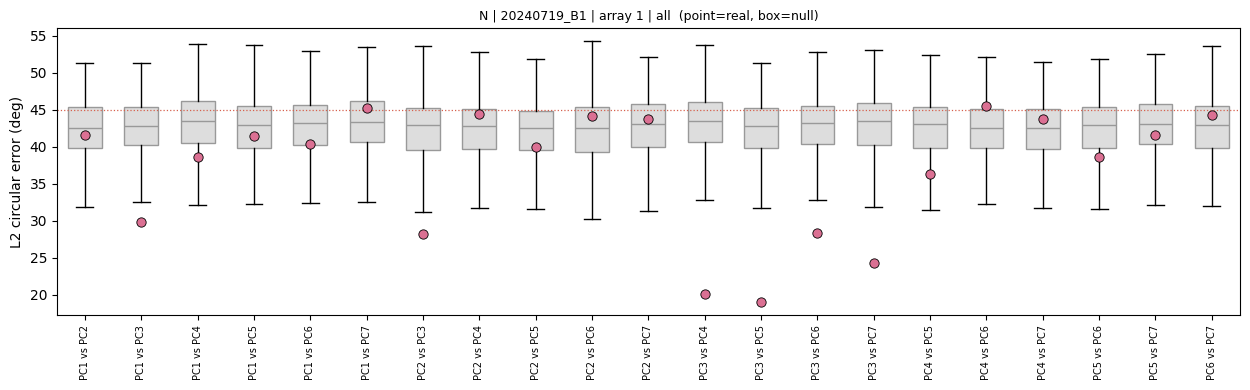

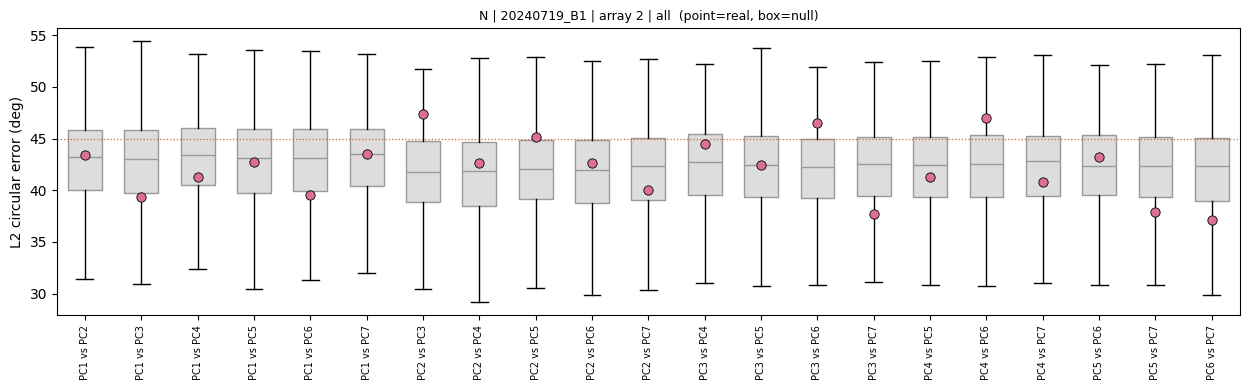

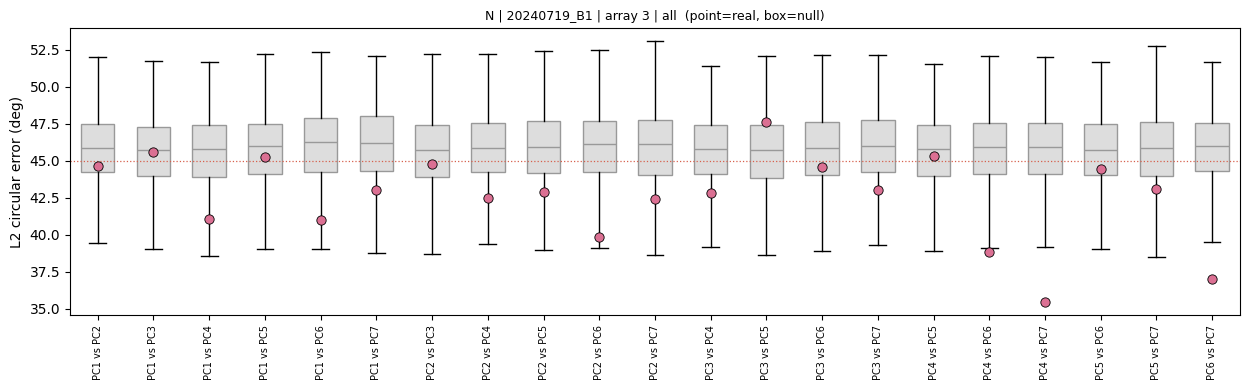

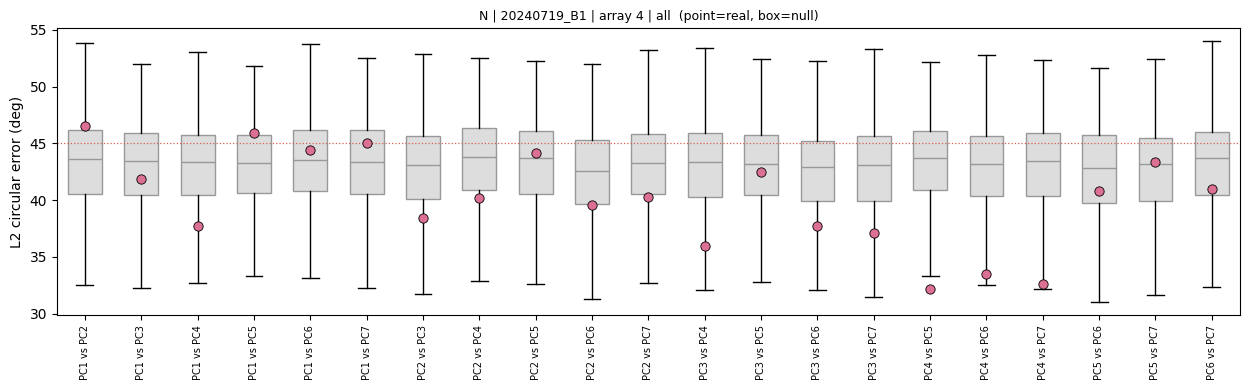

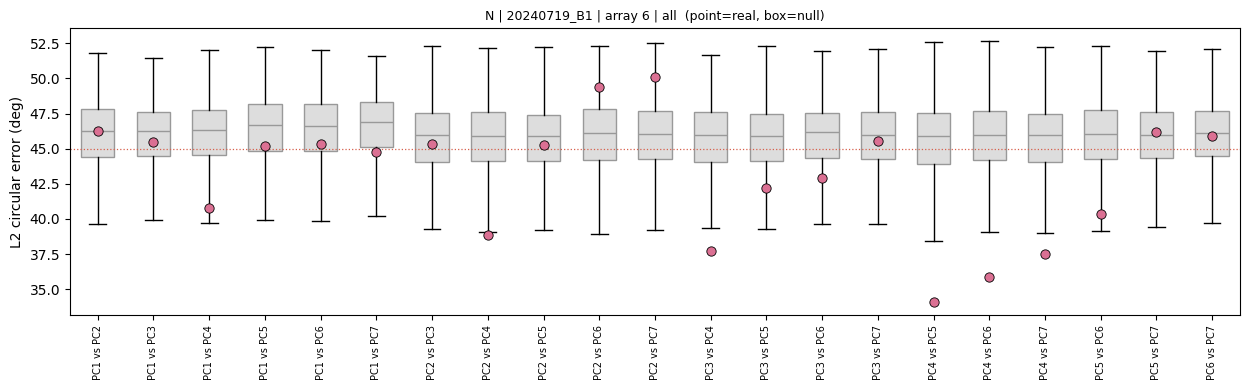

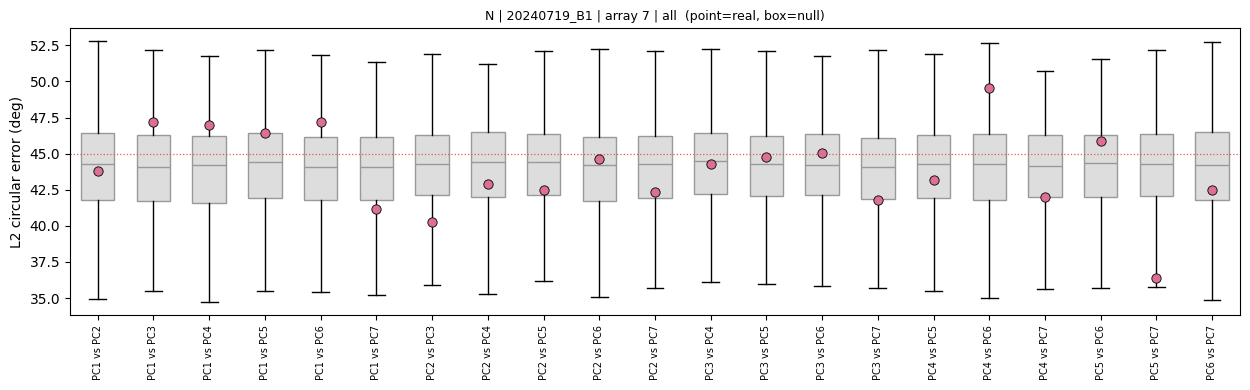

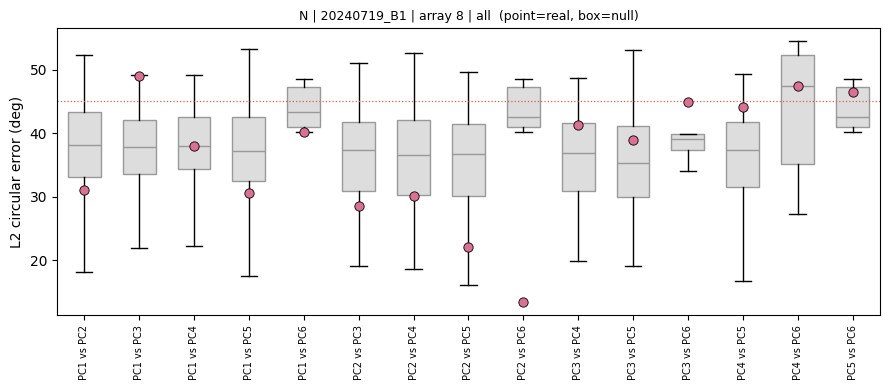

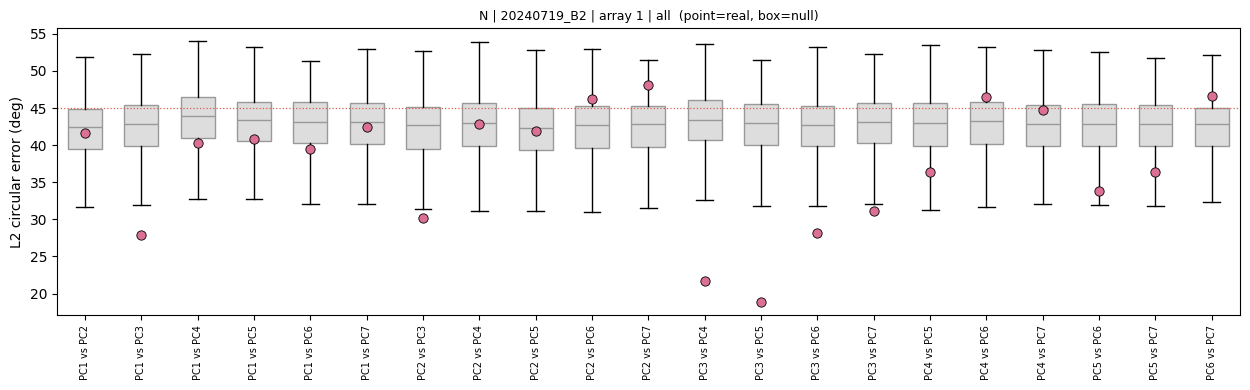

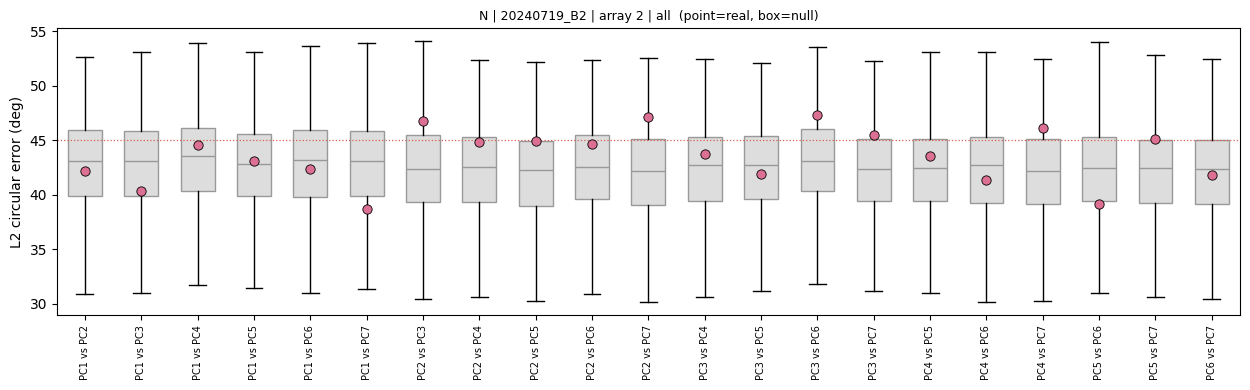

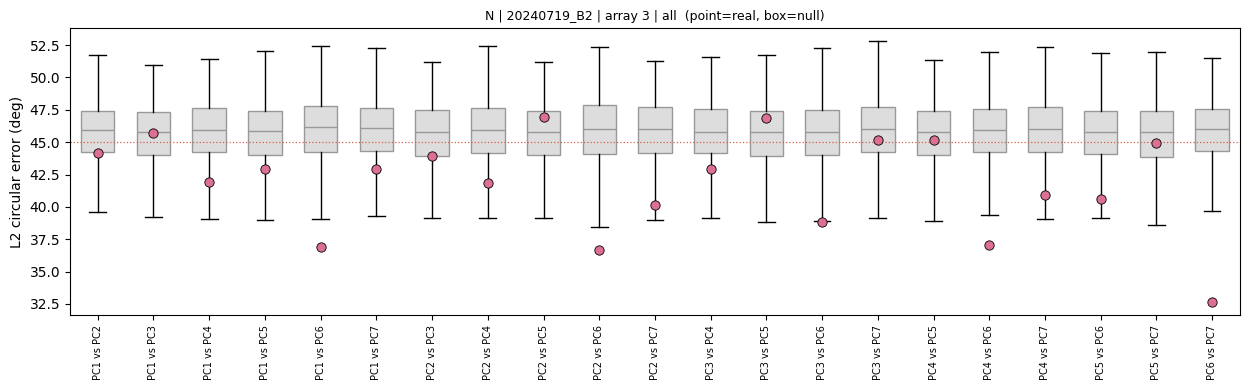

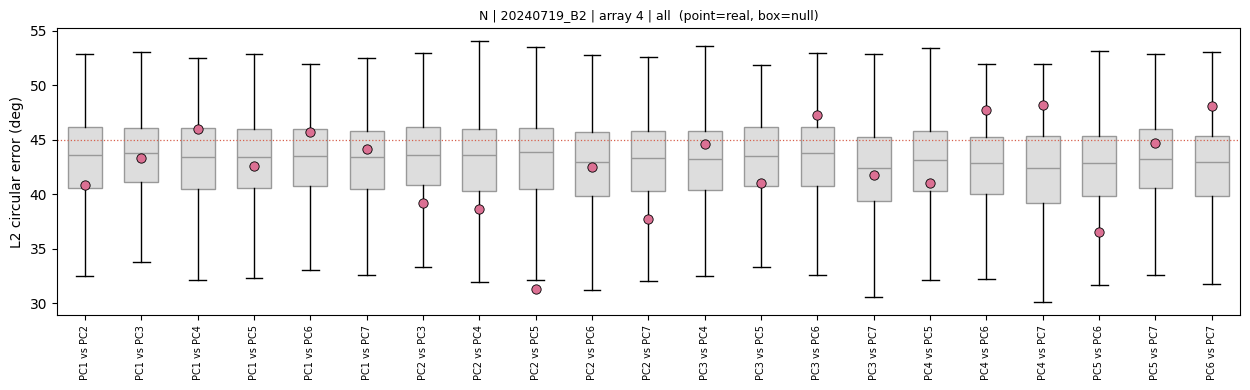

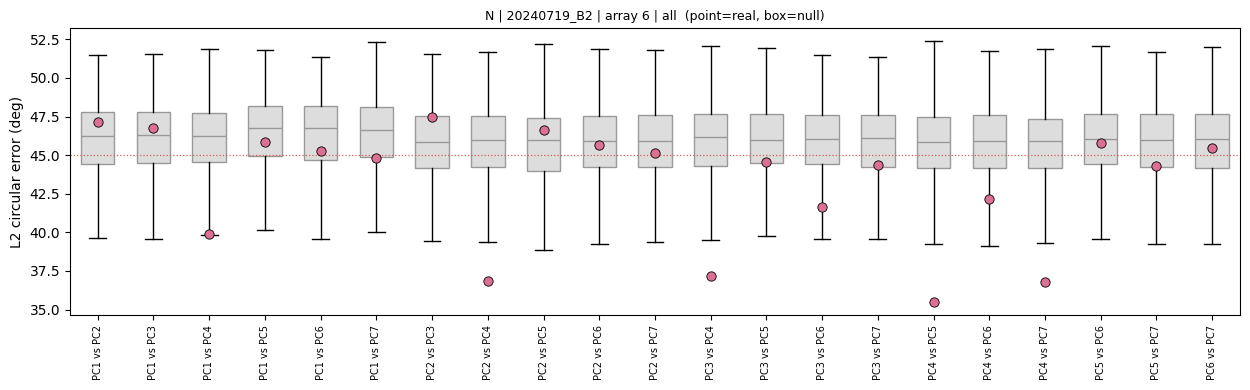

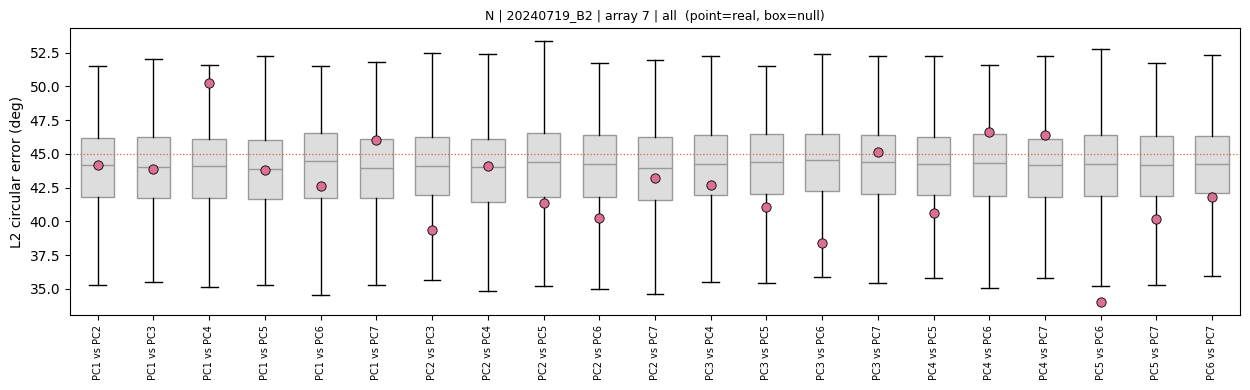

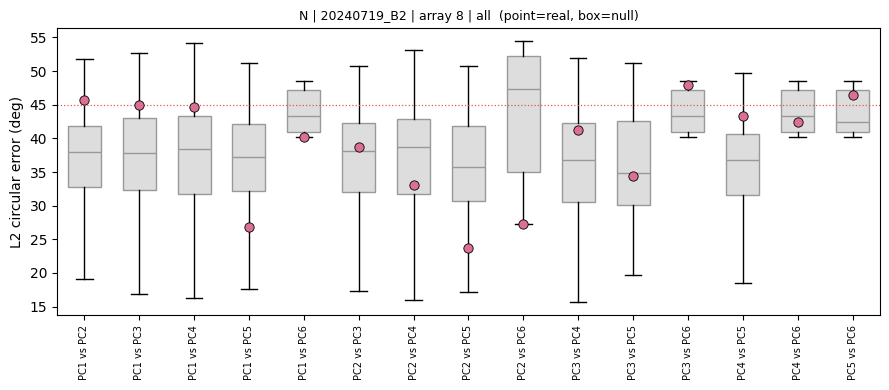

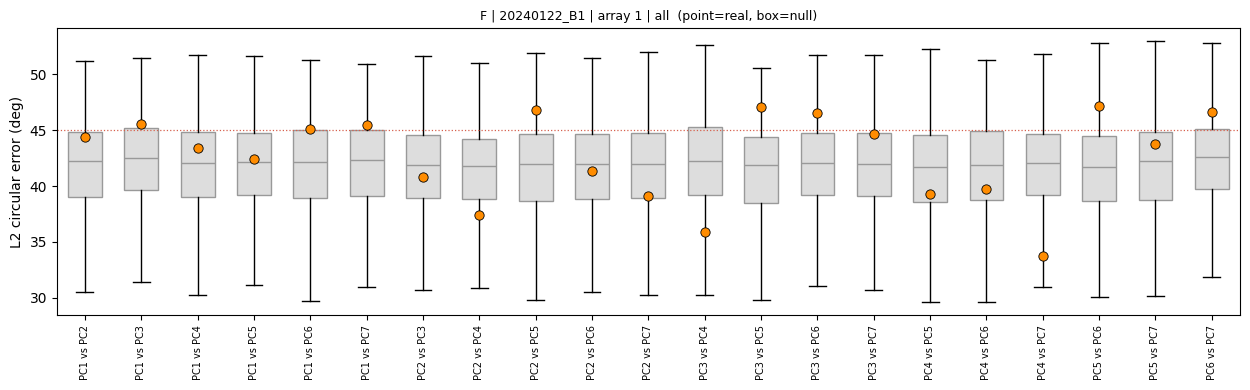

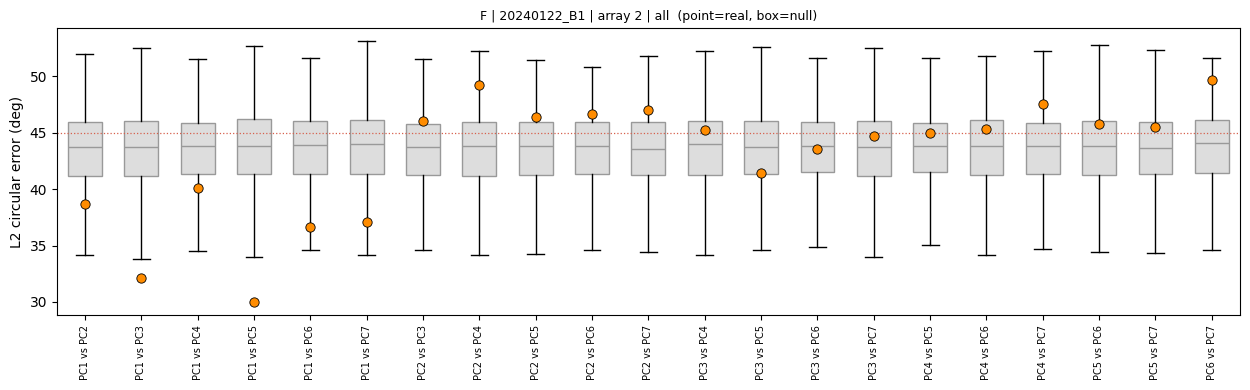

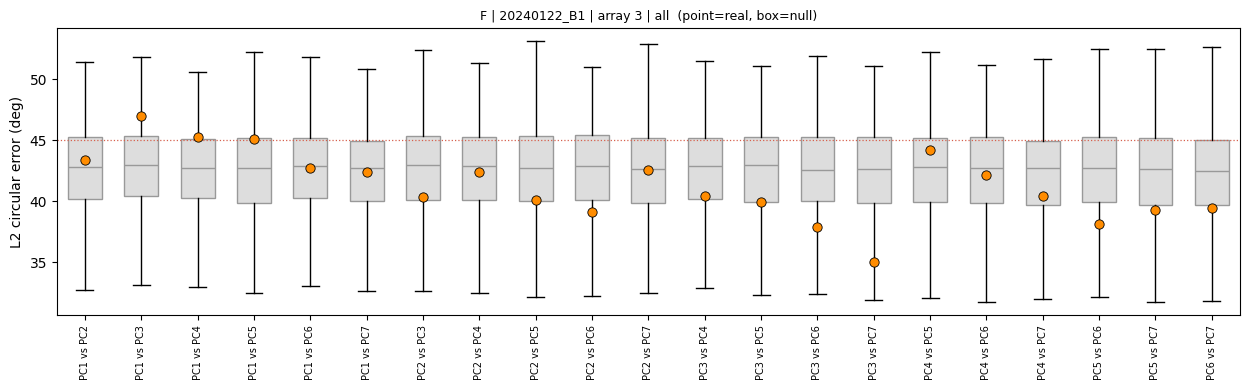

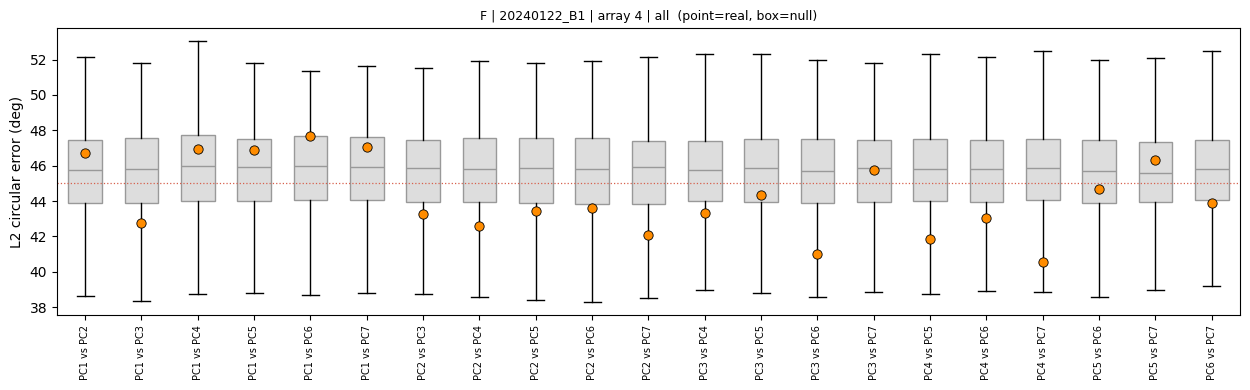

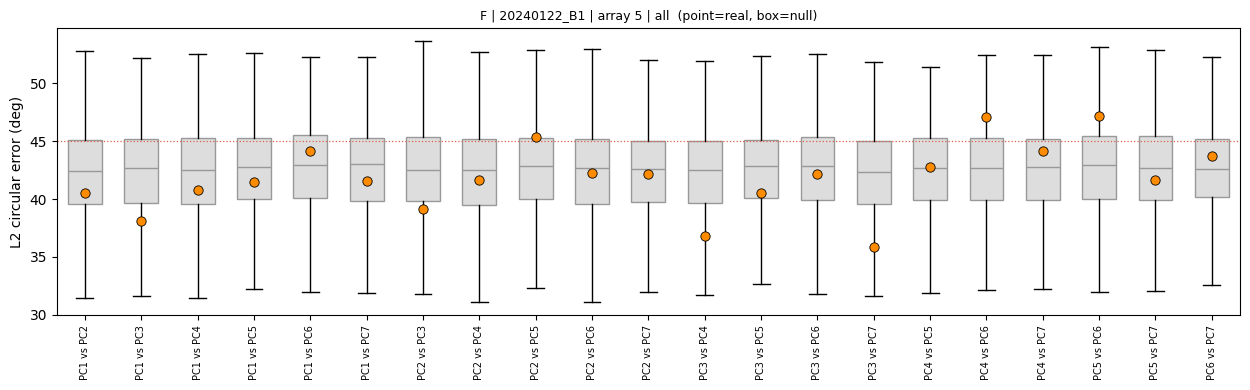

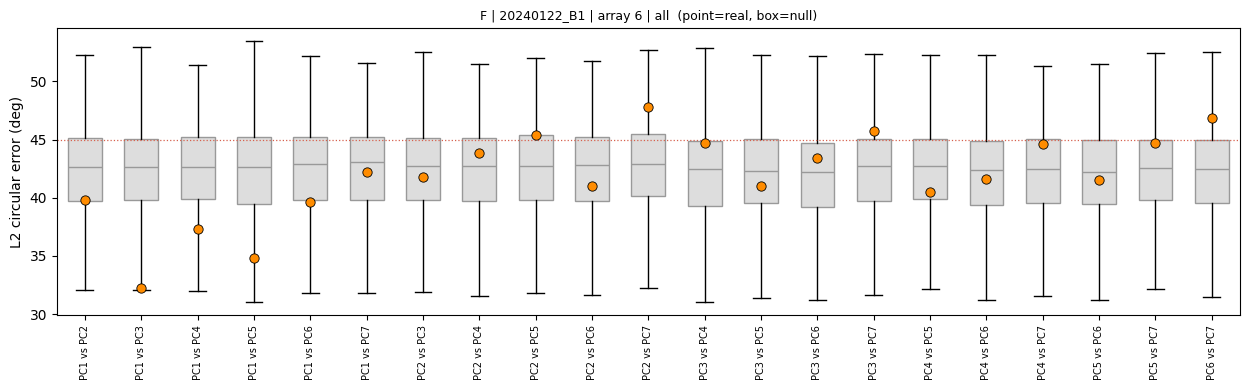

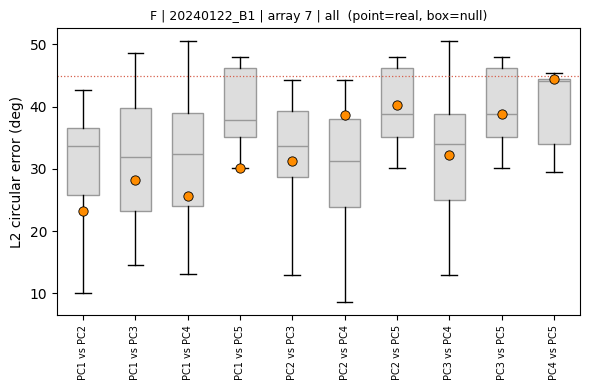

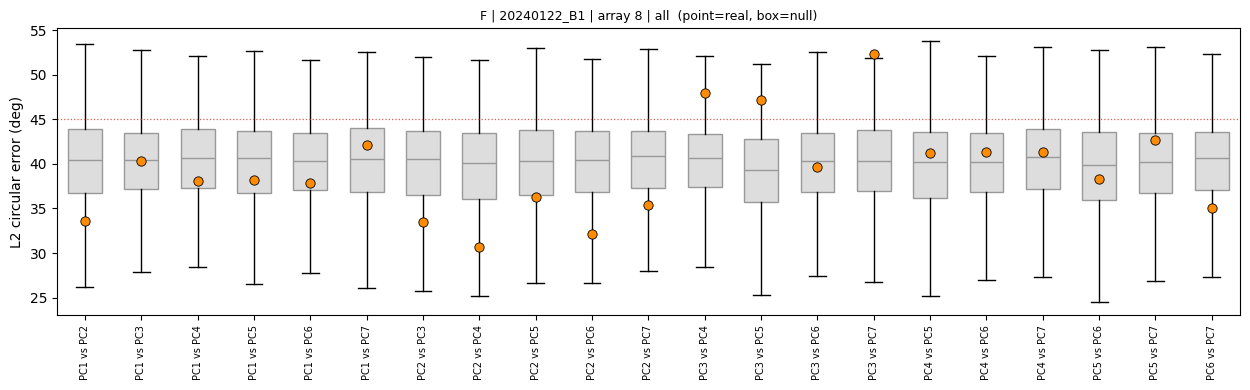

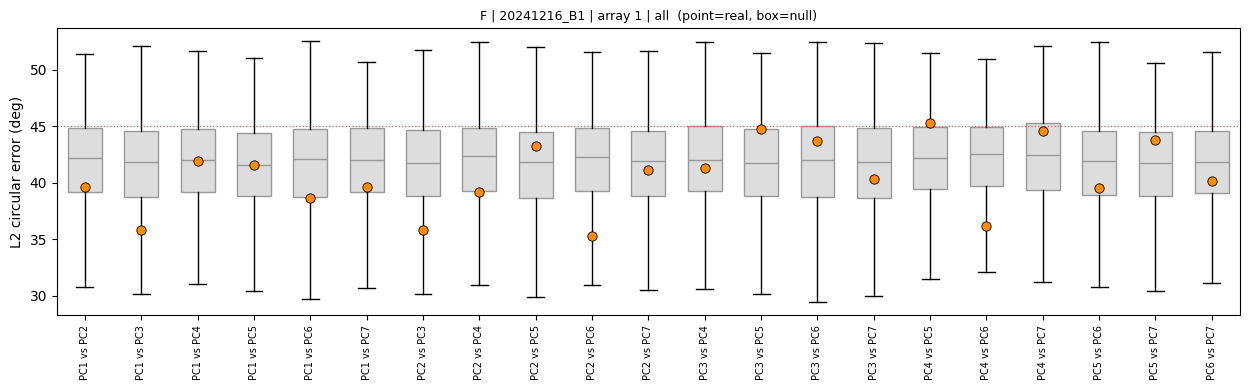

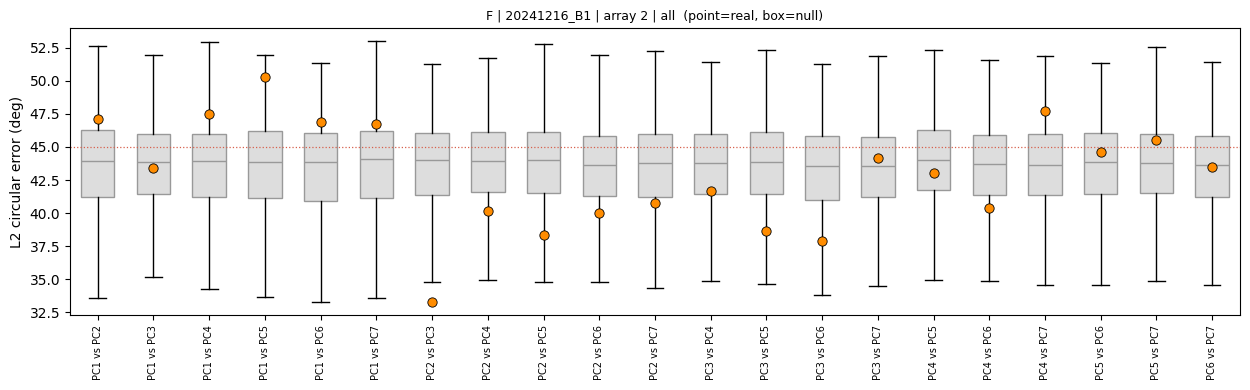

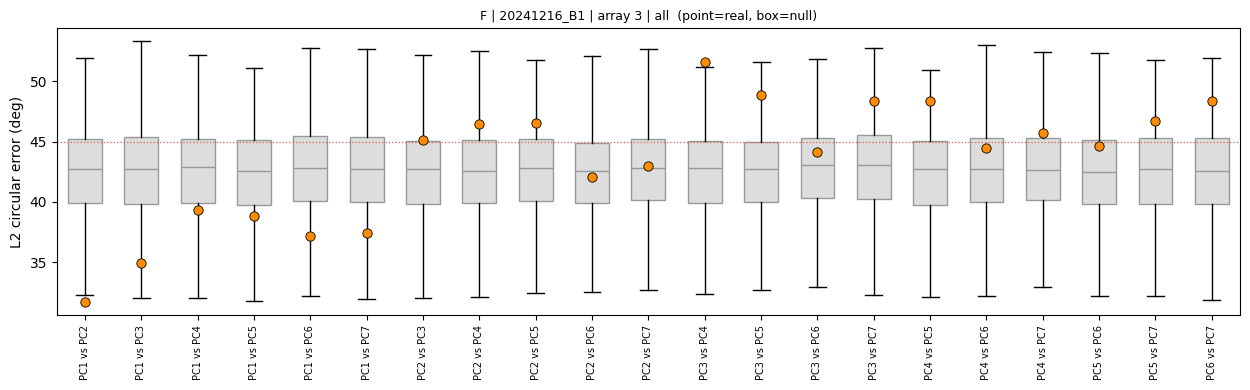

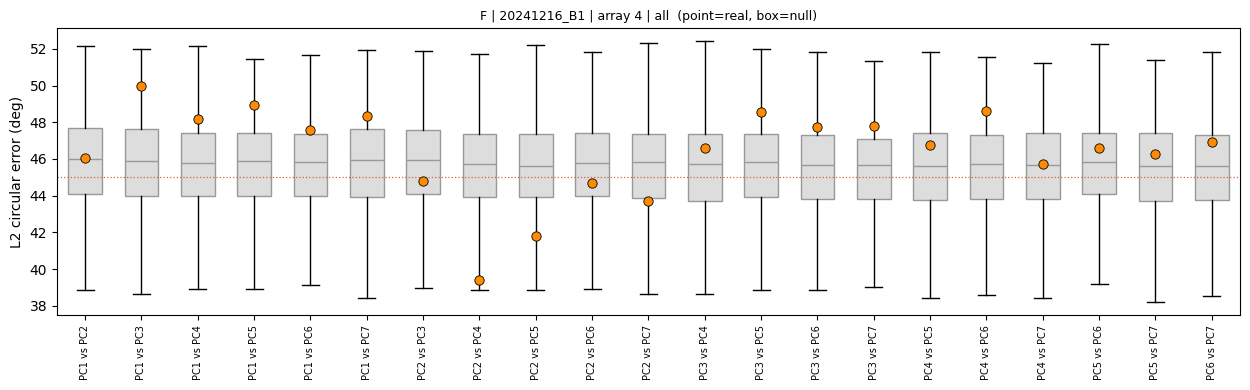

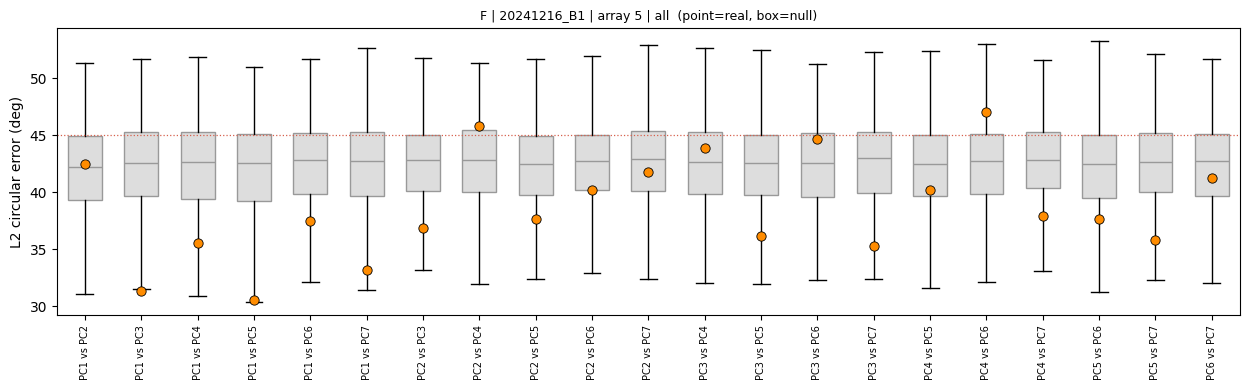

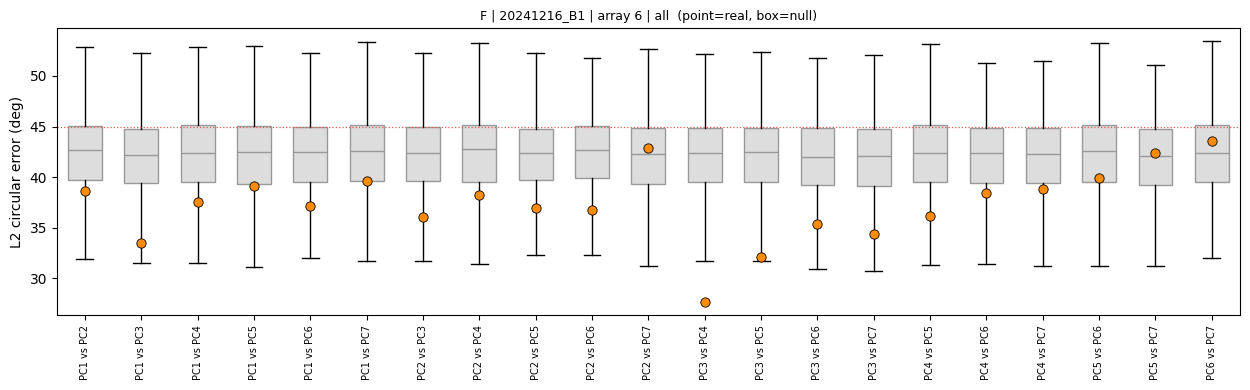

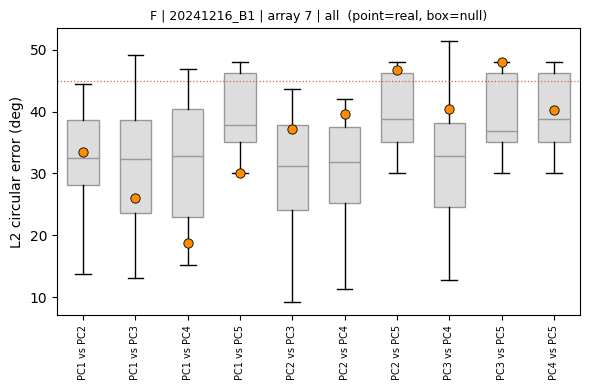

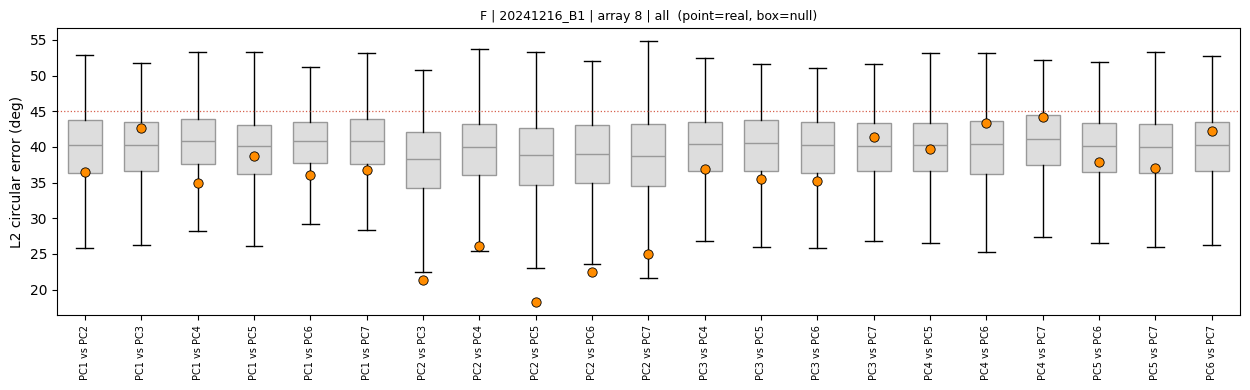

In [13]:
# example — adjust to an array that exists in your data
for m in ['L','N','F']:
    for d in DATES[m]['RS']:
        for a in V1_ARRAYS[m]:
            plot_pair_errors(m, d, a, "all", norm="L2")
            plt.tight_layout()
            plt.show()

## Cumulative grid — real-error percentile vs control, per monkey

For every (array, day, condition) we take the best PC pair (lowest real error)
and compute the empirical percentile of that real error within its own
permutation-null distribution: pct = 100 * #{null <= real} / N_perm.

A low percentile means the real reconstruction beats almost all random
relabellings (good); ~50 means chance. Percentiles are averaged across a
monkey's recording days, giving one grid per monkey (rows = arrays,
cols = all/EC/EO). One grid for L1, one for L2.

In [16]:
def best_pair_percentile(sub_pair_df):
    """Given rows for ONE array/day/condition/norm, return the percentile
    of the best pair's real error within its null distribution."""
    real = sub_pair_df[sub_pair_df.source == "real"]
    if real.empty:
        return np.nan
    best = real.loc[real["error"].idxmin()]
    pair = best["pc_pair"]
    real_err = best["error"]
    null = sub_pair_df[(sub_pair_df.pc_pair == pair) &
                       (sub_pair_df.source == "perm")]["error"].values
    if len(null) == 0:
        return np.nan
    return 100.0 * np.mean(null <= real_err)


def percentile_grid(monkey, norm):
    """Return (arrays, conditions, grid[arrays, conditions]) of mean
    best-pair percentiles, averaged over the monkey's recording days."""
    conds = [c for c in ["all", "EC", "EO"] if c in df["condition"].unique()]
    arrays = sorted(df[(df.monkey == monkey)]["array"].unique())
    days = DATES[monkey]["RS"]

    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            pcts = []
            for day in days:
                sub = df[(df.monkey == monkey) & (df.array == arr) &
                         (df.date == str(day)) & (df.condition == cond) &
                         (df.norm == norm)]
                if sub.empty:
                    continue
                p = best_pair_percentile(sub)
                if not np.isnan(p):
                    pcts.append(p)
            if pcts:
                grid[i, j] = np.mean(pcts)
    return arrays, conds, grid

In [17]:
def plot_percentile_grid(monkey, norm, ax=None):
    arrays, conds, grid = percentile_grid(monkey, norm)
    if ax is None:
        fig, ax = plt.subplots(figsize=(1.6 + 0.8*len(conds), 0.4*len(arrays) + 1.5))
    # low percentile = good -> reversed colormap so good is green
    im = ax.imshow(grid, cmap="RdYlGn_r", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"Monkey {monkey} — {norm} real-error percentile", fontsize=10)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                        fontsize=7,
                        color="white" if (v < 20 or v > 80) else "black")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("percentile in null (%)  —  low = beats control", fontsize=8)
    return ax

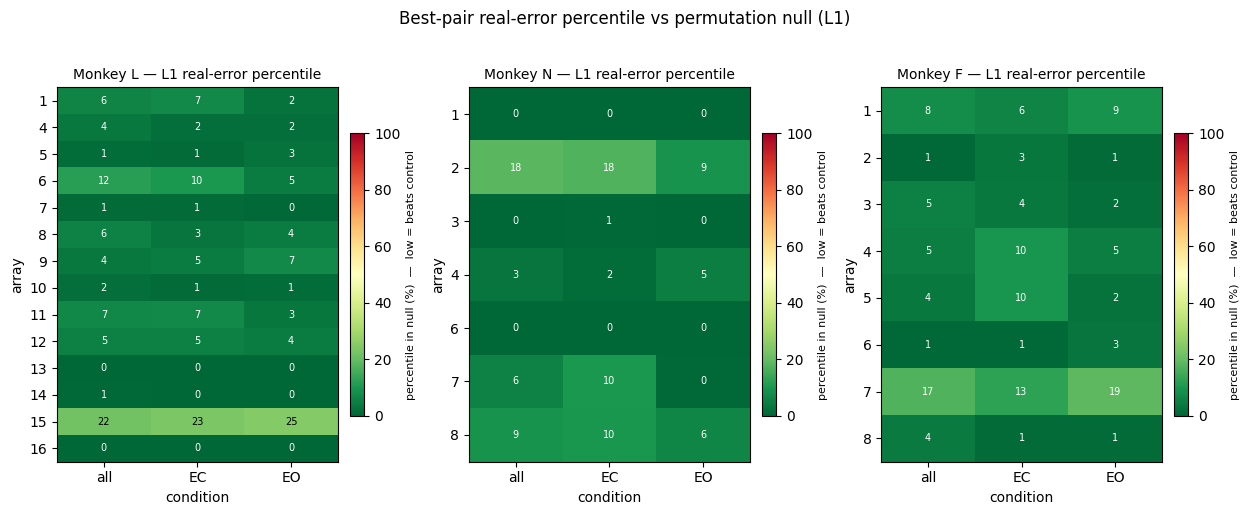

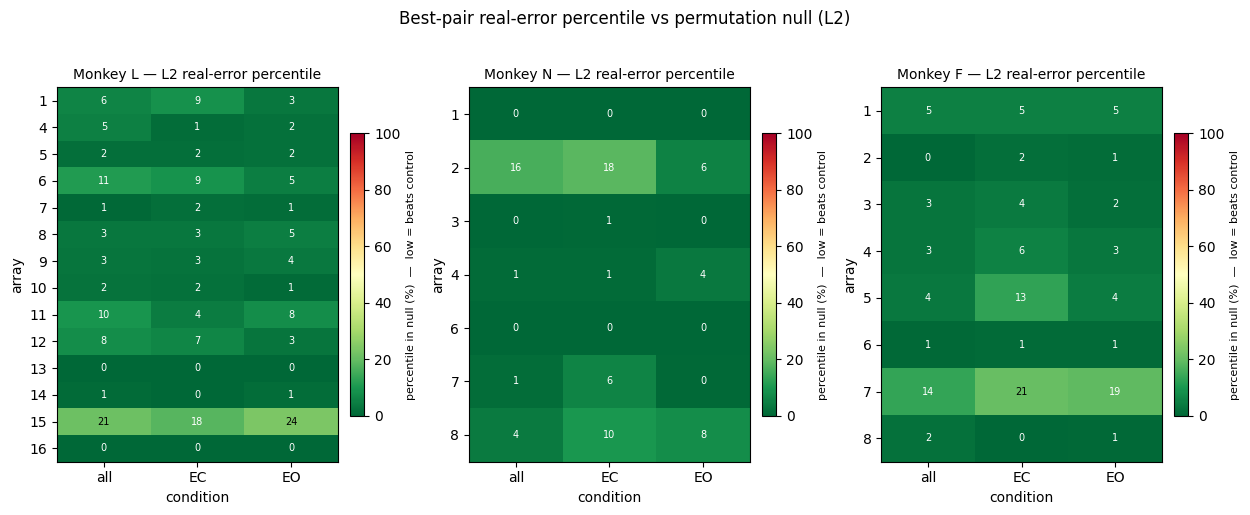

In [18]:
for norm in ["L1", "L2"]:
    fig, axes = plt.subplots(1, len(MONKEYS), figsize=(4.2*len(MONKEYS), 5))
    if len(MONKEYS) == 1:
        axes = [axes]
    for ax, monkey in zip(axes, MONKEYS):
        plot_percentile_grid(monkey, norm, ax=ax)
    fig.suptitle(f"Best-pair real-error percentile vs permutation null ({norm})",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

## Precompute percentile DataFrame

For every (monkey, date, array, condition, pc_pair, norm) we compute the
percentile of the real error within the permutation-null distribution built
on the SAME array, date, condition and pair:

    pct = 100 * mean(null <= real)

This tidy table is the basis for all downstream plots (grids, best-pair
summaries, EC/EO comparisons, ...).

In [21]:
def build_percentile_df(df):
    """One row per (monkey, date, array, condition, pc_pair, norm) with the
    real error, its percentile in the same-array/date/condition/pair null,
    null mean/median, and n_perm. Percentile uses the null on the SAME
    array, date, condition and pair."""
    keys = ["monkey", "date", "array", "condition", "pc_pair", "norm"]

    real = (df[df.source == "real"]
            .rename(columns={"error": "real_error"})
            [keys + ["pc_x", "pc_y", "real_error"]]
            .copy())

    null = df[df.source == "perm"]
    null_arrays = (null.groupby(keys)["error"]
                   .apply(lambda s: s.to_numpy())
                   .rename("null_vals").reset_index())

    merged = real.merge(null_arrays, on=keys, how="left")

    def _pct(row):
        nv = row["null_vals"]
        re = row["real_error"]
        if isinstance(nv, np.ndarray) and len(nv) and not np.isnan(re):
            return pd.Series({
                "percentile": 100.0 * np.mean(nv <= re),
                "null_mean": float(np.mean(nv)),
                "null_median": float(np.median(nv)),
                "n_perm": len(nv)})
        return pd.Series({"percentile": np.nan, "null_mean": np.nan,
                          "null_median": np.nan, "n_perm": 0})

    stats = merged.apply(_pct, axis=1)
    out = pd.concat([merged.drop(columns=["null_vals"]), stats], axis=1)
    out["array"] = out["array"].astype(int)
    out["pc_x"] = out["pc_x"].astype(int)
    out["pc_y"] = out["pc_y"].astype(int)
    out["n_perm"] = out["n_perm"].astype(int)
    return out


pct_df = build_percentile_df(df)
print("percentile rows:", len(pct_df))
pct_df.head()

percentile rows: 8868


,monkey,date,array,condition,pc_pair,norm,pc_x,pc_y,real_error,percentile,null_mean,null_median,n_perm
0,F,20240122_B1,1,all,PC1 vs PC2,L1,1,2,34.065623,52.2,33.503755,33.848132,1000
1,F,20240122_B1,1,all,PC1 vs PC2,L2,1,2,44.376595,71.5,41.715227,42.218851,1000
2,F,20240122_B1,1,all,PC1 vs PC3,L1,1,3,34.869675,55.0,33.768896,34.367188,1000
3,F,20240122_B1,1,all,PC1 vs PC3,L2,1,3,45.572914,78.1,42.088291,42.491416,1000
4,F,20240122_B1,1,all,PC1 vs PC4,L1,1,4,33.899908,50.2,33.484816,33.892072,1000


In [22]:
pct_path = os.path.join(DF_FOLDER, "percentiles.pkl")
pct_df.to_pickle(pct_path)
print("saved", pct_path)

saved /CSNG/studekat/maps_paper/dataframes/percentiles.pkl


In [23]:
def best_pair_pct_table(pct_df, norm):
    """For each (monkey, date, array, condition): the row of the best pair
    (lowest real error) and its percentile. Then average percentile across
    a monkey's recording days -> one value per (monkey, array, condition)."""
    sub = pct_df[pct_df.norm == norm]
    # best pair per array/date/condition
    idx = sub.groupby(["monkey", "date", "array", "condition"])["real_error"].idxmin()
    best = sub.loc[idx]
    # average over days
    agg = (best.groupby(["monkey", "array", "condition"])["percentile"]
           .mean().reset_index())
    return best, agg

best_L1, agg_L1 = best_pair_pct_table(pct_df, "L1")
agg_L1.head()

,monkey,array,condition,percentile
0,F,1,EC,6.00
1,F,1,EO,9.15
2,F,1,all,8.20
3,F,2,EC,3.45
4,F,2,EO,1.10


In [31]:
from matplotlib.colors import TwoSlopeNorm

def plot_percentile_grid(monkey, norm, agg, ax=None):
    conds = [c for c in ["all", "EC", "EO"] if c in agg["condition"].unique()]
    arrays = sorted(agg[agg.monkey == monkey]["array"].unique())
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = agg[(agg.monkey == monkey) & (agg.array == arr) &
                    (agg.condition == cond)]["percentile"].values
            if len(v):
                grid[i, j] = v[0]
    if ax is None:
        fig, ax = plt.subplots(figsize=(1.6 + 0.8*len(conds), 0.4*len(arrays) + 1.5))

    # diverging colormap centered on 5%: below 5 = green side, above 5 = red side
    cnorm = TwoSlopeNorm(vmin=0, vcenter=5, vmax=100)
    im = ax.imshow(grid, cmap="bwr", norm=cnorm, aspect="auto")

    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"Monkey {monkey} — {norm} percentile", fontsize=10)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 5 or v > 80) else "black")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04,
                        ticks=[0, 5, 25, 50, 100])
    cbar.set_label("percentile in null (%) — green < 5% beats control", fontsize=8)
    return ax

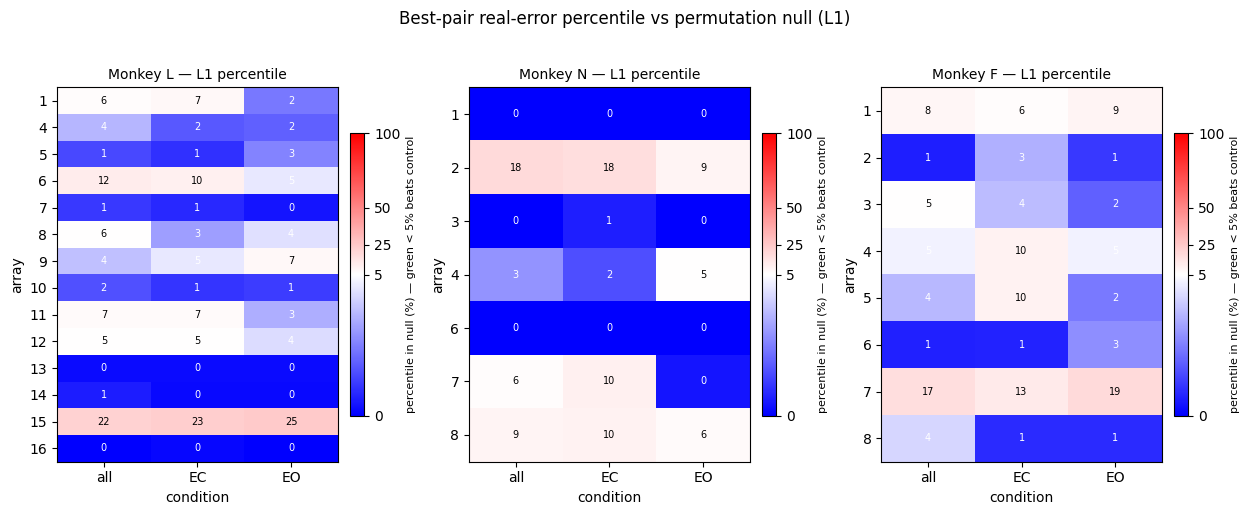

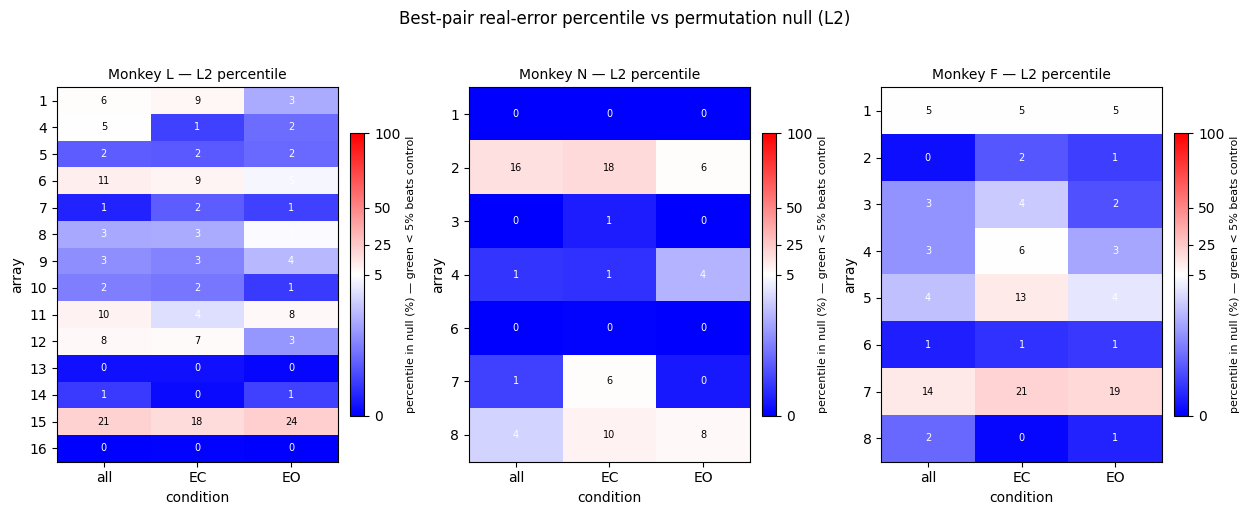

In [32]:
"""
def plot_percentile_grid(monkey, norm, agg, ax=None):
    conds = [c for c in ["all", "EC", "EO"] if c in agg["condition"].unique()]
    arrays = sorted(agg[agg.monkey == monkey]["array"].unique())
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = agg[(agg.monkey == monkey) & (agg.array == arr) &
                    (agg.condition == cond)]["percentile"].values
            if len(v):
                grid[i, j] = v[0]
    if ax is None:
        fig, ax = plt.subplots(figsize=(1.6 + 0.8*len(conds), 0.4*len(arrays) + 1.5))
    im = ax.imshow(grid, cmap="RdYlGn_r", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"Monkey {monkey} — {norm} percentile", fontsize=10)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 20 or v > 80) else "black")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("percentile in null (%) — low = beats control", fontsize=8)
    return ax
    """


for norm in ["L1", "L2"]:
    _, agg = best_pair_pct_table(pct_df, norm)
    fig, axes = plt.subplots(1, len(MONKEYS), figsize=(4.2*len(MONKEYS), 5))
    if len(MONKEYS) == 1:
        axes = [axes]
    for ax, monkey in zip(axes, MONKEYS):
        plot_percentile_grid(monkey, norm, agg, ax=ax)
    fig.suptitle(f"Best-pair real-error percentile vs permutation null ({norm})",
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

## Date comparison

In [33]:
from matplotlib.colors import TwoSlopeNorm

def best_pair_pct_by_date(pct_df, norm):
    """Best pair (lowest real error) per (monkey, date, array, condition),
    keeping the date dimension (no averaging across days)."""
    sub = pct_df[pct_df.norm == norm]
    idx = sub.groupby(["monkey", "date", "array", "condition"])["real_error"].idxmin()
    return sub.loc[idx]


def plot_percentile_grid_date(monkey, date, norm, best, ax):
    """Grid for ONE monkey and ONE date: rows = arrays, cols = conditions."""
    d = best[(best.monkey == monkey) & (best.date == str(date))]
    conds = [c for c in ["all", "EC", "EO"] if c in d["condition"].unique()]
    arrays = sorted(d["array"].unique())
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = d[(d.array == arr) & (d.condition == cond)]["percentile"].values
            if len(v):
                grid[i, j] = v[0]

    cnorm = TwoSlopeNorm(vmin=0, vcenter=5, vmax=100)
    im = ax.imshow(grid, cmap="bwr", norm=cnorm, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"{monkey} — {date}", fontsize=9)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 2 or v > 70) else "black")
    return im

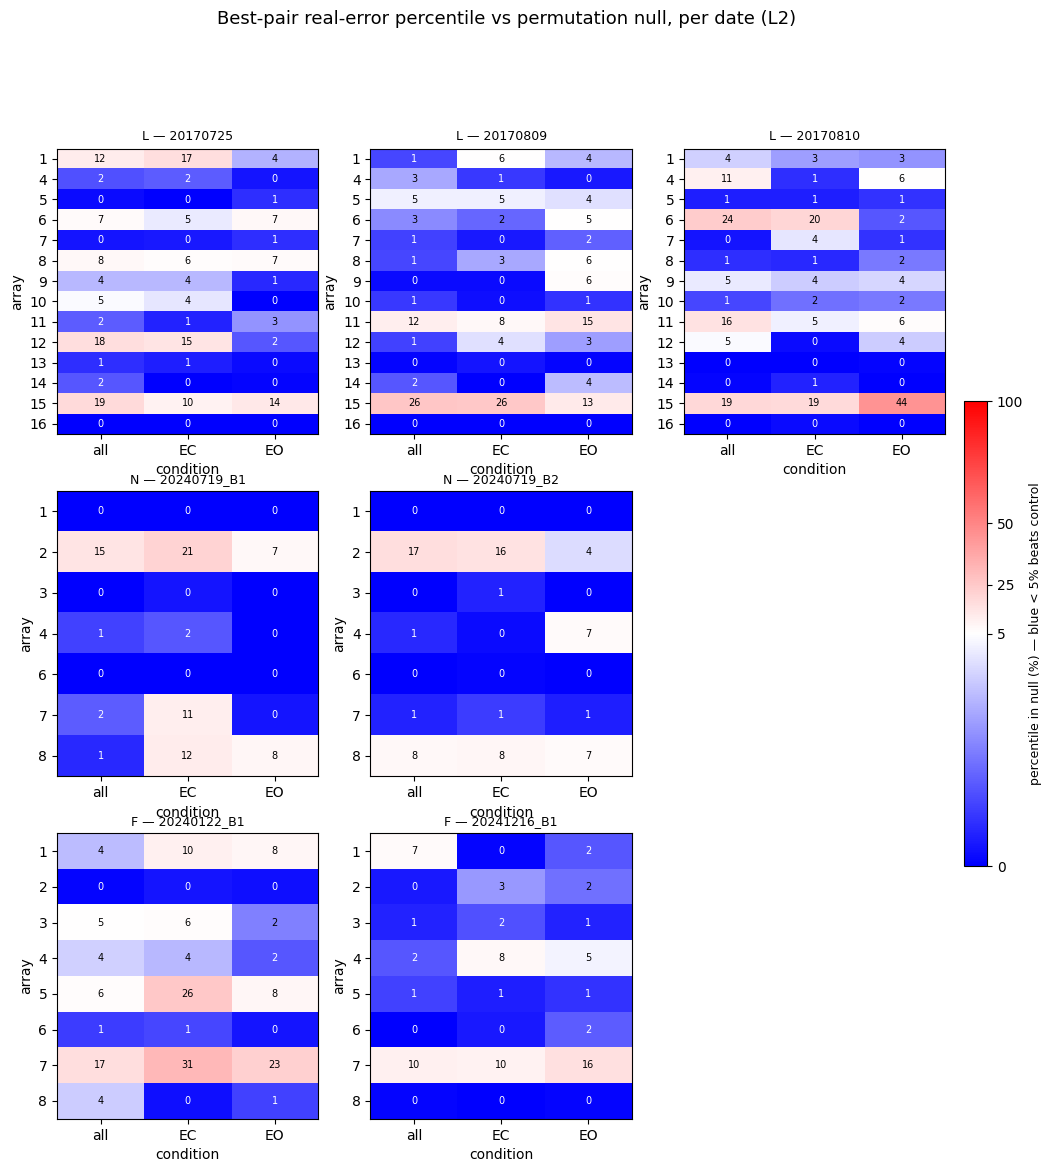

In [34]:
norm = "L2"
best = best_pair_pct_by_date(pct_df, norm)

# dates per monkey, in the order L, N, F
monkey_dates = {m: DATES[m]["RS"] for m in MONKEYS}
max_cols = max(len(v) for v in monkey_dates.values())   # 3 (L has the most)

fig, axes = plt.subplots(len(MONKEYS), max_cols,
                         figsize=(4.0*max_cols, 4.2*len(MONKEYS)),
                         squeeze=False)

im_last = None
for r, monkey in enumerate(MONKEYS):
    dates = monkey_dates[monkey]
    for c in range(max_cols):
        ax = axes[r][c]
        if c < len(dates):
            im_last = plot_percentile_grid_date(monkey, dates[c], norm, best, ax)
        else:
            ax.axis("off")    # blank slot (e.g. N and F have only 2 dates)

# one shared colorbar for the whole figure
cbar = fig.colorbar(im_last, ax=axes, fraction=0.025, pad=0.02,
                    ticks=[0, 5, 25, 50, 100])
cbar.set_label("percentile in null (%) — blue < 5% beats control", fontsize=9)

fig.suptitle(f"Best-pair real-error percentile vs permutation null, per date ({norm})",
             fontsize=13, y=0.99)
plt.show()

## Lowest null distribution choice 

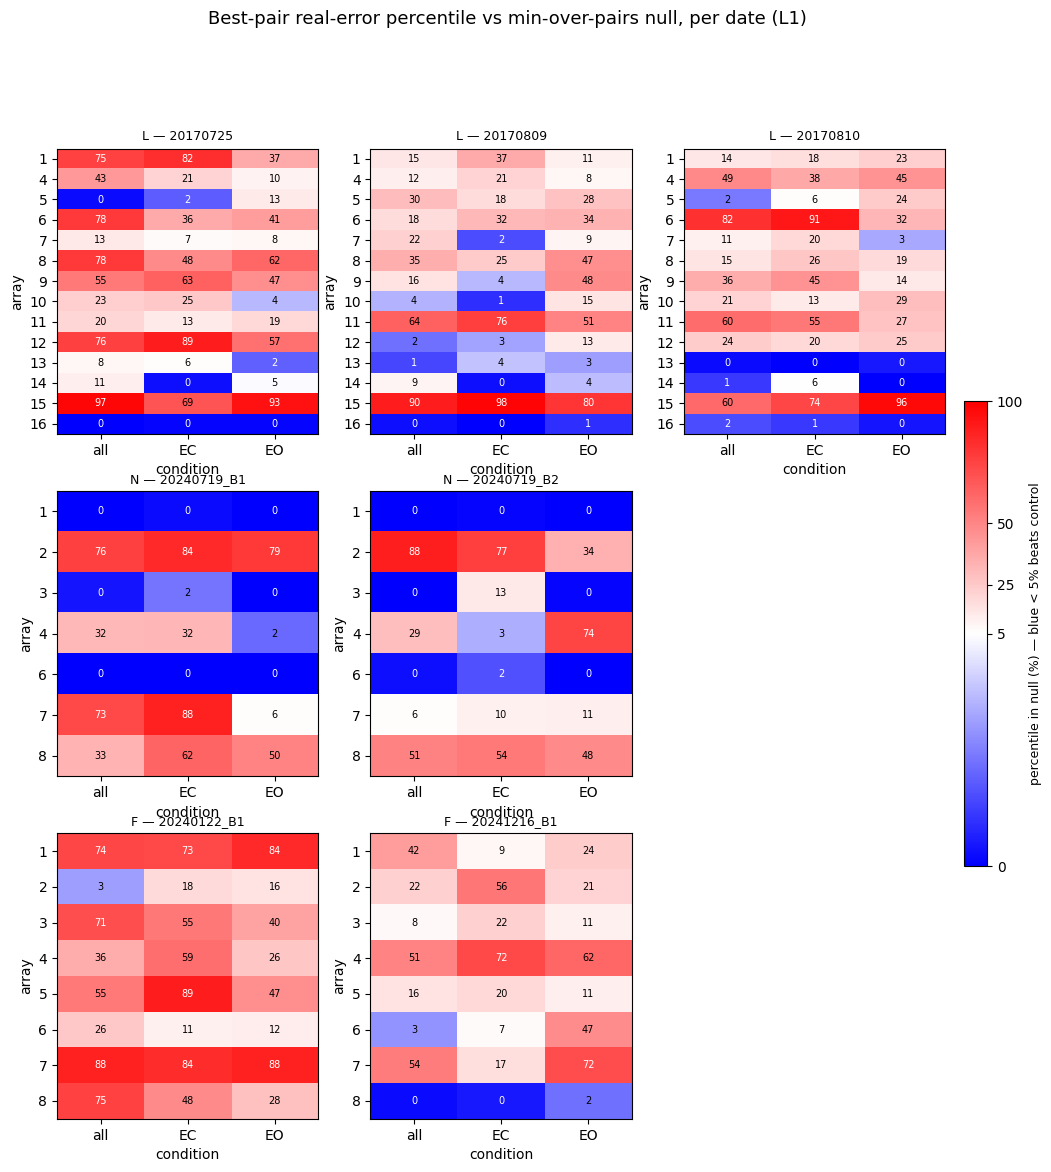

In [36]:
from matplotlib.colors import TwoSlopeNorm

def minpair_percentile_df(df):
    """One row per (monkey, date, array, condition, norm).

    Statistic = min over PC pairs of the REAL error (best reconstruction).
    Null      = for each permutation, min over PC pairs of its error.
    Percentile = 100 * mean(null_min <= real_min), within the SAME
                 array/date/condition (corrects best-of-pairs selection bias).
    """
    keys = ["monkey", "date", "array", "condition", "norm"]

    real = df[df.source == "real"]
    real_min = (real.groupby(keys)["error"].min()
                .rename("real_error").reset_index())
    real_best_idx = real.groupby(keys)["error"].idxmin()
    real_pair = (real.loc[real_best_idx, keys + ["pc_pair", "pc_x", "pc_y"]]
                 .reset_index(drop=True))
    real_min = real_min.merge(real_pair, on=keys, how="left")

    perm = df[df.source == "perm"]
    perm_min = (perm.groupby(keys + ["perm_idx"])["error"].min()
                .rename("perm_min").reset_index())
    null_arrays = (perm_min.groupby(keys)["perm_min"]
                   .apply(lambda s: s.to_numpy())
                   .rename("null_vals").reset_index())

    merged = real_min.merge(null_arrays, on=keys, how="left")

    def _stats(row):
        nv = row["null_vals"]
        re = row["real_error"]
        if isinstance(nv, np.ndarray) and len(nv) and not np.isnan(re):
            return pd.Series({
                "percentile": 100.0 * np.mean(nv <= re),
                "null_mean": float(np.mean(nv)),
                "null_median": float(np.median(nv)),
                "n_perm": len(nv)})
        return pd.Series({"percentile": np.nan, "null_mean": np.nan,
                          "null_median": np.nan, "n_perm": 0})

    stats = merged.apply(_stats, axis=1)
    out = pd.concat([merged.drop(columns=["null_vals"]), stats], axis=1)
    out["array"] = out["array"].astype(int)
    out["pc_x"] = out["pc_x"].astype(int)
    out["pc_y"] = out["pc_y"].astype(int)
    out["n_perm"] = out["n_perm"].astype(int)
    return out


def minpair_plot_grid(monkey, date, norm, mp_df, ax):
    """Grid for ONE monkey and ONE date: rows = arrays, cols = conditions.
    Reads the collapsed min-over-pairs percentile table `mp_df`."""
    d = mp_df[(mp_df.norm == norm) & (mp_df.monkey == monkey) &
              (mp_df.date == str(date))]
    conds = [c for c in ["all", "EC", "EO"] if c in d["condition"].unique()]
    arrays = sorted(d["array"].unique())
    grid = np.full((len(arrays), len(conds)), np.nan)
    for i, arr in enumerate(arrays):
        for j, cond in enumerate(conds):
            v = d[(d.array == arr) & (d.condition == cond)]["percentile"].values
            if len(v):
                grid[i, j] = v[0]

    cnorm = TwoSlopeNorm(vmin=0, vcenter=5, vmax=100)
    im = ax.imshow(grid, cmap="bwr", norm=cnorm, aspect="auto")
    ax.set_xticks(range(len(conds))); ax.set_xticklabels(conds)
    ax.set_yticks(range(len(arrays))); ax.set_yticklabels(arrays)
    ax.set_xlabel("condition"); ax.set_ylabel("array")
    ax.set_title(f"{monkey} — {date}", fontsize=9)
    for i in range(len(arrays)):
        for j in range(len(conds)):
            v = grid[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=7,
                        color="white" if (v < 2 or v > 70) else "black")
    return im


# ── build the table and draw the per-date multi-row figure (L2) ──────
norm = "L1"
mp_df = minpair_percentile_df(df)

monkey_dates = {m: DATES[m]["RS"] for m in MONKEYS}
max_cols = max(len(v) for v in monkey_dates.values())

fig, axes = plt.subplots(len(MONKEYS), max_cols,
                         figsize=(4.0*max_cols, 4.2*len(MONKEYS)),
                         squeeze=False)

im_last = None
for r, monkey in enumerate(MONKEYS):
    dates = monkey_dates[monkey]
    for c in range(max_cols):
        ax = axes[r][c]
        if c < len(dates):
            im_last = minpair_plot_grid(monkey, dates[c], norm, mp_df, ax)
        else:
            ax.axis("off")

cbar = fig.colorbar(im_last, ax=axes, fraction=0.025, pad=0.02,
                    ticks=[0, 5, 25, 50, 100])
cbar.set_label("percentile in null (%) — blue < 5% beats control", fontsize=9)

fig.suptitle(f"Best-pair real-error percentile vs min-over-pairs null, per date ({norm})",
             fontsize=13, y=0.99)
plt.show()

## Helper: best PC pair & empirical p-value

For a given selection, the "best" pair is the one with the lowest real error.
The permutation p-value = fraction of null errors <= the real error for that pair.

In [5]:
def best_pair_and_pvalue(monkey, date, array, condition, norm="L1"):
    sub = df[(df.monkey==monkey) & (df.date==str(date)) &
             (df.array==int(array)) & (df.condition==condition) &
             (df.norm==norm)]
    if sub.empty:
        return None
    real = sub[sub.source=="real"]
    best = real.loc[real["error"].idxmin()]
    pair = best["pc_pair"]; real_err = best["error"]
    null = sub[(sub.pc_pair==pair) & (sub.source=="perm")]["error"].values
    pval = (np.sum(null <= real_err) + 1) / (len(null) + 1) if len(null) else np.nan
    return dict(pc_pair=pair, real_error=float(real_err),
                p_value=float(pval), n_perm=len(null))

best_pair_and_pvalue(m, d, a, "all", "L1")

{'pc_pair': 'PC3 vs PC7',
 'real_error': 33.03938421488974,
 'p_value': 0.14885114885114886,
 'n_perm': 1000}

## Helper: draw an OP map on the 8×8 grid

In [6]:
def get_layout(monkey, array):
    key = f"{monkey}_even" if int(array) % 2 == 0 else f"{monkey}_odd"
    return np.array(LAYOUTS[key])

def draw_op_grid(op_vals, layout, ax=None, title=""):
    hsv = plt.get_cmap("hsv")
    UNORI = np.array([0.5, 0.5, 0.5, 1.0])
    gr = layout.shape
    img = np.ones((*gr, 4))
    for r in range(gr[0]):
        for c in range(gr[1]):
            ch = layout[r, c]
            a = op_vals[ch] if (0 <= ch < len(op_vals)) else -1
            img[r, c] = UNORI if a < 0 else hsv((a % 180) / 180.0)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.2, 3.2))
    ax.imshow(img, origin="upper", interpolation="nearest")
    for i in range(gr[1]+1): ax.axvline(i-0.5, color="white", lw=0.4)
    for i in range(gr[0]+1): ax.axhline(i-0.5, color="white", lw=0.4)
    for r in range(gr[0]):
        for c in range(gr[1]):
            ch = layout[r, c]
            if ch >= 0:
                ax.text(c, r, str(ch), ha="center", va="center",
                        fontsize=4, color="white", fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_title(title, fontsize=8)
    return ax

## Real OP map vs PCA-derived map (chosen pair)

Rebuilds the derived map from the stored PCA scores for a chosen PC pair
(default: the best pair by L1) and shows it next to the real map.

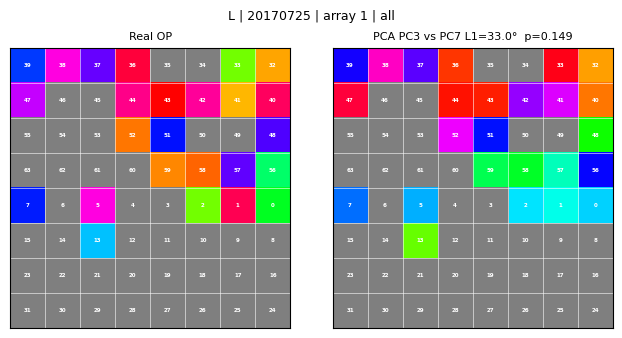

In [8]:
def derived_map_for_pair(monkey, date, array, condition, pc_pair, op_array):
    key = (monkey, str(date), int(array), condition)
    if key not in pca_store:
        print("no pca scores for", key); return None
    st = pca_store[key]
    scores, oriented_idx = st["scores"], st["oriented_idx"]
    pc_x, pc_y = [int(s)-1 for s in pc_pair.replace("PC","").split(" vs ")]
    op_or = op_array[oriented_idx]
    x, y = scores[:, pc_x], scores[:, pc_y]
    phi = polar_angles_from_centroid(x, y)
    rot, flip = best_rotation_to_op(phi, op_or)
    geo = apply_geometric_map(phi, rot, flip)
    derived = np.full(N_CH, -1.0); derived[oriented_idx] = geo
    return derived

# load a real OP map straight from disk via functions_maps
from functions_maps import load_op_map
OP_MAP_FOLDER = P["op_map_folder"]
SEL_MIN = P["channel_selection"]["selectivity_min"]
JUMP_MAX = P["channel_selection"]["num_jump_max"]

def compare_maps(monkey, date, array, condition, norm="L1"):
    op_array = load_op_map(monkey, array, OP_MAP_FOLDER,
                           selectivity_min=SEL_MIN, num_jump_max=JUMP_MAX,
                           n_channels=N_CH)
    bp = best_pair_and_pvalue(monkey, date, array, condition, norm)
    if bp is None:
        print("no data"); return
    pair = bp["pc_pair"]
    derived = derived_map_for_pair(monkey, date, array, condition, pair, op_array)
    layout = get_layout(monkey, array)
    fig, axes = plt.subplots(1, 2, figsize=(6.6, 3.4))
    draw_op_grid(op_array, layout, axes[0], "Real OP")
    draw_op_grid(derived, layout, axes[1],
                 f"PCA {pair} {norm}={bp['real_error']:.1f}°  p={bp['p_value']:.3f}")
    fig.suptitle(f"{monkey} | {date} | array {array} | {condition}", fontsize=9)
    plt.tight_layout(); plt.show()

compare_maps(m, d, a, "all", "L1")

## Pooled summary — best real error per array, by condition

Distribution of the best-pair real error across all arrays, split by
condition (all / EC / EO) and coloured by monkey.

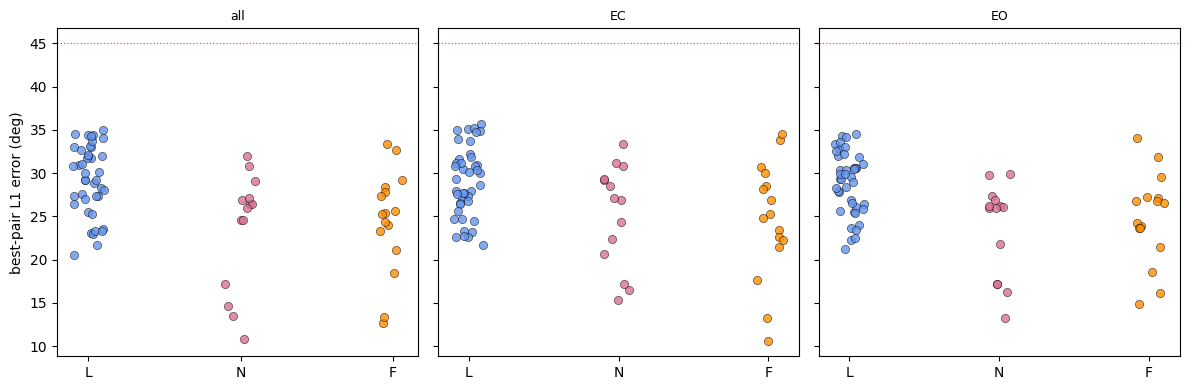

,monkey,date,array,condition,pc_pair,best_error
0,F,20240122_B1,1,EC,PC2 vs PC3,28.450860
1,F,20240122_B1,1,EO,PC4 vs PC5,29.559039
2,F,20240122_B1,1,all,PC2 vs PC4,28.370810
3,F,20240122_B1,2,EC,PC1 vs PC3,26.900780
4,F,20240122_B1,2,EO,PC1 vs PC5,26.588739


In [10]:
def best_errors_table(norm="L1"):
    recs = []
    real = df[(df.source=="real") & (df.norm==norm)]
    for (monkey, date, array, cond), g in real.groupby(
            ["monkey","date","array","condition"]):
        best = g.loc[g["error"].idxmin()]
        recs.append(dict(monkey=monkey, date=date, array=array,
                         condition=cond, pc_pair=best["pc_pair"],
                         best_error=best["error"]))
    return pd.DataFrame(recs)

bt = best_errors_table("L1")
conds = [c for c in ["all","EC","EO"] if c in bt["condition"].unique()]
fig, axes = plt.subplots(1, len(conds), figsize=(4*len(conds), 4), sharey=True)
if len(conds) == 1: axes = [axes]
for ax, cond in zip(axes, conds):
    sub = bt[bt.condition==cond]
    for i, monkey in enumerate(MONKEYS):
        vals = sub[sub.monkey==monkey]["best_error"].values
        ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.1,0.1,len(vals)),
                   vals, color=COLORS_M.get(monkey,"gray"),
                   alpha=0.8, s=35, edgecolor="k", linewidth=0.4)
    ax.set_xticks(range(len(MONKEYS))); ax.set_xticklabels(MONKEYS)
    ax.set_title(cond, fontsize=9); ax.axhline(45, color="#d6604d", ls=":", lw=0.9)
axes[0].set_ylabel("best-pair L1 error (deg)")
plt.tight_layout(); plt.show()
bt.head()

## EC vs EO comparison

Per array, the best L1 error in EC vs EO (paired). Points below the diagonal
mean EC reconstructs the OP map better than EO.

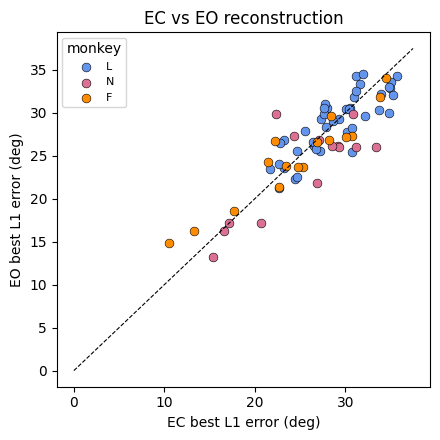

In [11]:
piv = (best_errors_table("L1")
       .pivot_table(index=["monkey","date","array"],
                    columns="condition", values="best_error").reset_index())
if {"EC","EO"}.issubset(piv.columns):
    fig, ax = plt.subplots(figsize=(4.5,4.5))
    for monkey in MONKEYS:
        s = piv[piv.monkey==monkey]
        ax.scatter(s["EC"], s["EO"], color=COLORS_M.get(monkey,"gray"),
                   label=monkey, s=40, edgecolor="k", linewidth=0.4)
    lim = np.nanmax([piv.get("EC"), piv.get("EO")]) * 1.05
    ax.plot([0,lim],[0,lim], "k--", lw=0.8)
    ax.set_xlabel("EC best L1 error (deg)"); ax.set_ylabel("EO best L1 error (deg)")
    ax.legend(title="monkey", fontsize=8); ax.set_title("EC vs EO reconstruction")
    plt.tight_layout(); plt.show()
else:
    print("EC/EO columns not both present")